# 6.29 - Final Benchmark Clean Load

Minimal notebook to load the final non-FACE benchmark together with the final combined FACE benchmark.

In [1]:
from __future__ import annotations

from pathlib import Path
import re
import sys

import numpy as np
import pandas as pd
from IPython.display import display

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
RESULTS_DIR = ROOT / 'results'

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)

DATASET_ORDER = [
    'adult',
    'compas',
    'german_credit',
    'give_me_some_credit',
    'heloc',
    'lending_club',
    'wisconsin_breast_cancer',
]

CERTCF_SWEEP_ALPHAS = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
CERTCF_SWEEP_LAMBDAS = [0.10, 0.20, 0.50, 1.00]
CERTCF_SWEEP_METHOD_ORDER = [
    f'CertCF a={alpha:.2f} lam={lam:g}'
    for alpha in CERTCF_SWEEP_ALPHAS
    for lam in CERTCF_SWEEP_LAMBDAS
]

PAPER_CERTCF_ALPHA = 0.20
PAPER_CERTCF_LAMBDA = 1.0
PAPER_CERTCF_LABEL = f'CertCF a={PAPER_CERTCF_ALPHA:.2f} lam={PAPER_CERTCF_LAMBDA:g}'

BASELINE_METHOD_ORDER = [
    'NN10000',
    'Growing Spheres',
    'DiCE',
    'FACE',
]
METHOD_ORDER = [PAPER_CERTCF_LABEL, *BASELINE_METHOD_ORDER]
ANALYSIS_METHOD_ORDER = [*CERTCF_SWEEP_METHOD_ORDER, *BASELINE_METHOD_ORDER]

PALETTE = {
    PAPER_CERTCF_LABEL: '#087F5B',
    'NN10000': '#1864AB',
    'Growing Spheres': '#F08C00',
    'DiCE': '#C92A2A',
    'FACE': '#7048E8',
}

# Extra colors for optional CertCF sweep plots/tables.
for label in CERTCF_SWEEP_METHOD_ORDER:
    PALETTE.setdefault(label, '#087F5B')


In [2]:
RESULT_FILE_SPECS = [
    {
        'result_key': 'final_benchmark_noface',
        'path': RESULTS_DIR / 'final_benchmark_noface.parquet',
        # CertCF is now taken only from the sparse-shrink sweep below.
        'excluded_methods': {'face', 'certcf'},
        'included_run_names_by_method': {
            'growing_spheres': {'gs_max_radius=50.0'},
        },
    },
    {
        'result_key': 'final_benchmark_noface_certcf_shrink_sparsity',
        'path': RESULTS_DIR / 'final_benchmark_noface_certcf_shrink_sparsity.parquet',
        'included_methods': {'certcf'},
    },
    {
        'result_key': 'final_benchmark_face',
        'path': RESULTS_DIR / 'final_benchmark_face.parquet',
        'included_methods': {'face'},
    },
]

file_status = pd.DataFrame([
    {
        'result_key': spec['result_key'],
        'path': str(spec['path']),
        'available': spec['path'].exists(),
        'size_mb': spec['path'].stat().st_size / (1024 ** 2) if spec['path'].exists() else np.nan,
    }
    for spec in RESULT_FILE_SPECS
])
display(file_status)

missing = file_status.loc[~file_status['available'], 'path'].tolist()
if missing:
    raise FileNotFoundError('Missing result files:\n' + '\n'.join(missing))


,result_key,path,available,size_mb
0,final_benchmark_noface,/home/gabrielepintus/Documents/github/Preimage...,True,4.375778
1,final_benchmark_noface_certcf_shrink_sparsity,/home/gabrielepintus/Documents/github/Preimage...,True,33.904958
2,final_benchmark_face,/home/gabrielepintus/Documents/github/Preimage...,True,0.917765


In [3]:
CERTCF_SWEEP_RE = re.compile(r'eps_alpha=([0-9.]+)-sparsity_lambda=([0-9.]+)')
CERTCF_OLD_RE = re.compile(r'eps_alpha=([0-9.]+)')


def parse_certcf_hparams(run_name: str) -> tuple[float, float]:
    run_name = str(run_name)
    match = CERTCF_SWEEP_RE.search(run_name)
    if match:
        return float(match.group(1)), float(match.group(2))
    match = CERTCF_OLD_RE.search(run_name)
    if match:
        return float(match.group(1)), np.nan
    return np.nan, np.nan


def method_label(row: pd.Series) -> str:
    method = str(row['method'])
    run_name = str(row.get('run_name', method))
    if method == 'certcf':
        alpha, lam = parse_certcf_hparams(run_name)
        if np.isfinite(alpha) and np.isfinite(lam):
            return f'CertCF a={alpha:.2f} lam={lam:g}'
        if np.isfinite(alpha):
            return f'CertCF old a={alpha:.2f}'
        return run_name
    if method == 'nearest_neighbor':
        return 'NN10000'
    if method == 'growing_spheres':
        return 'Growing Spheres'
    if method == 'dice':
        return 'DiCE'
    if method == 'face':
        return 'FACE'
    return run_name


frames = []
for spec in RESULT_FILE_SPECS:
    frame = pd.read_parquet(spec['path']).copy()
    included_methods = spec.get('included_methods')
    if included_methods is not None:
        frame = frame[frame['method'].astype(str).isin(included_methods)].copy()
    excluded_methods = spec.get('excluded_methods', set())
    if excluded_methods:
        frame = frame[~frame['method'].astype(str).isin(excluded_methods)].copy()
    for method_name, run_names in spec.get('included_run_names_by_method', {}).items():
        method_mask = frame['method'].astype(str).eq(str(method_name))
        frame = frame[~method_mask | frame['run_name'].astype(str).isin(run_names)].copy()
    if 'run_name' not in frame.columns:
        frame['run_name'] = frame['method'].astype(str)
    frame['result_key'] = spec['result_key']
    frame['result_file'] = spec['path'].name
    frames.append(frame)

ANALYSIS_DF = pd.concat(frames, ignore_index=True)
ANALYSIS_DF['method_label'] = ANALYSIS_DF.apply(method_label, axis=1)
parsed_hparams = ANALYSIS_DF['run_name'].map(parse_certcf_hparams)
ANALYSIS_DF['certcf_alpha'] = [x[0] for x in parsed_hparams]
ANALYSIS_DF['certcf_sparsity_lambda'] = [x[1] for x in parsed_hparams]
ANALYSIS_DF = ANALYSIS_DF[ANALYSIS_DF['method_label'].isin(ANALYSIS_METHOD_ORDER)].copy()
ANALYSIS_DF['dataset'] = pd.Categorical(ANALYSIS_DF['dataset'], DATASET_ORDER, ordered=True)
ANALYSIS_DF['method_label'] = pd.Categorical(ANALYSIS_DF['method_label'], ANALYSIS_METHOD_ORDER, ordered=True)
ANALYSIS_DF = ANALYSIS_DF.sort_values(['dataset', 'method_label', 'query_idx'], ignore_index=True)

CERTCF_SWEEP_DF = ANALYSIS_DF[ANALYSIS_DF['method'].astype(str).eq('certcf')].copy()
PAPER_DF = ANALYSIS_DF[ANALYSIS_DF['method_label'].astype(str).isin(METHOD_ORDER)].copy()
PAPER_DF['method_label'] = pd.Categorical(PAPER_DF['method_label'].astype(str), METHOD_ORDER, ordered=True)
PAPER_DF = PAPER_DF.sort_values(['dataset', 'method_label', 'query_idx'], ignore_index=True)

# Backward-compatible name used by the rest of this notebook: one selected CertCF plus baselines.
BENCHMARK_DF = PAPER_DF.copy()

if PAPER_CERTCF_LABEL not in set(CERTCF_SWEEP_DF['method_label'].astype(str)):
    available = sorted(CERTCF_SWEEP_DF['method_label'].astype(str).unique())
    raise ValueError(f'Missing selected paper CertCF run {PAPER_CERTCF_LABEL}. Available: {available}')

print({
    'analysis_rows': int(len(ANALYSIS_DF)),
    'paper_rows': int(len(BENCHMARK_DF)),
    'certcf_sweep_rows': int(len(CERTCF_SWEEP_DF)),
    'datasets': int(ANALYSIS_DF['dataset'].nunique()),
    'paper_methods': BENCHMARK_DF['method_label'].dropna().astype(str).unique().tolist(),
    'n_certcf_sweep_runs': int(CERTCF_SWEEP_DF['method_label'].nunique()),
})

display(
    CERTCF_SWEEP_DF[['dataset', 'method_label', 'certcf_alpha', 'certcf_sparsity_lambda']]
    .drop_duplicates()
    .sort_values(['dataset', 'certcf_alpha', 'certcf_sparsity_lambda'])
    .head(20)
)


/tmp/ipykernel_43430/3544911113.py:56: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ANALYSIS_DF['method_label'] = ANALYSIS_DF.apply(method_label, axis=1)
/tmp/ipykernel_43430/3544911113.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ANALYSIS_DF['certcf_alpha'] = [x[0] for x in parsed_hparams]
/tmp/ipykernel_43430/3544911113.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.c

{'analysis_rows': 190920, 'paper_rows': 23865, 'certcf_sweep_rows': 171828, 'datasets': 7, 'paper_methods': ['CertCF a=0.20 lam=1', 'NN10000', 'Growing Spheres', 'DiCE', 'FACE'], 'n_certcf_sweep_runs': 36}


,dataset,method_label,certcf_alpha,certcf_sparsity_lambda
0,adult,CertCF a=0.10 lam=0.1,0.10,0.1
1000,adult,CertCF a=0.10 lam=0.2,0.10,0.2
2000,adult,CertCF a=0.10 lam=0.5,0.10,0.5
3000,adult,CertCF a=0.10 lam=1,0.10,1.0
4000,adult,CertCF a=0.15 lam=0.1,0.15,0.1
5000,adult,CertCF a=0.15 lam=0.2,0.15,0.2
6000,adult,CertCF a=0.15 lam=0.5,0.15,0.5
7000,adult,CertCF a=0.15 lam=1,0.15,1.0
8000,adult,CertCF a=0.20 lam=0.1,0.20,0.1
9000,adult,CertCF a=0.20 lam=0.2,0.20,0.2


## Validity

,method_label,n_datasets,total_success,total_queries,dataset_avg_validity_pct,dataset_std_validity_pct
0,CertCF a=0.20 lam=1,7,4773,4773,100.0000,0.0000
1,NN10000,7,4773,4773,100.0000,0.0000
2,Growing Spheres,7,4763,4773,99.6163,0.7034
3,DiCE,7,4463,4773,93.1684,6.1848
4,FACE,7,4683,4773,98.0612,2.0001


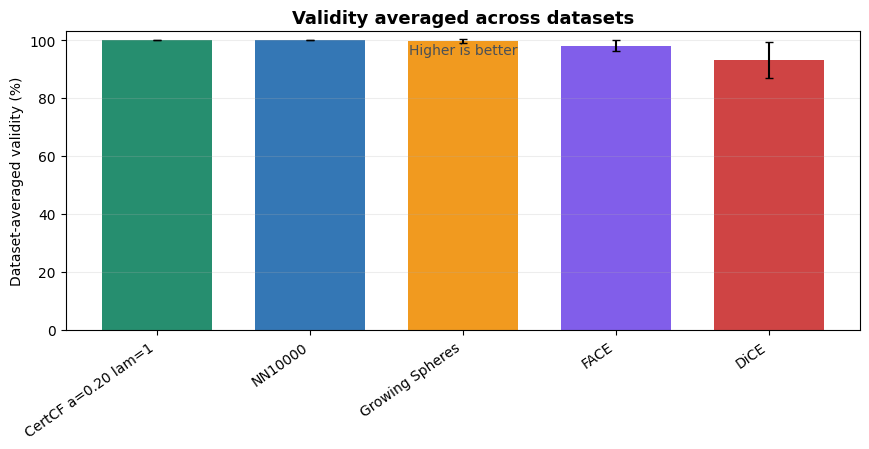

In [4]:
import matplotlib.pyplot as plt


def compute_validity_summary(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    for dataset_name in DATASET_ORDER:
        ds = df[df['dataset'].astype(str).eq(dataset_name)]
        for method_label in METHOD_ORDER:
            method_df = ds[ds['method_label'].astype(str).eq(method_label)]
            if method_df.empty:
                continue
            success = method_df['success'].astype(bool)
            rows.append({
                'dataset': dataset_name,
                'method_label': method_label,
                'n_total': int(len(method_df)),
                'n_success': int(success.sum()),
                'validity_pct': 100.0 * float(success.mean()),
            })

    by_dataset = pd.DataFrame(rows)
    averaged = (
        by_dataset
        .groupby('method_label', observed=True)
        .agg(
            n_datasets=('dataset', 'nunique'),
            total_success=('n_success', 'sum'),
            total_queries=('n_total', 'sum'),
            dataset_avg_validity_pct=('validity_pct', 'mean'),
            dataset_std_validity_pct=('validity_pct', 'std'),
        )
        .reset_index()
    )
    averaged['method_label'] = pd.Categorical(averaged['method_label'], METHOD_ORDER, ordered=True)
    averaged = averaged.sort_values('method_label', ignore_index=True)
    return by_dataset, averaged


def plot_validity_barplot(summary_df: pd.DataFrame):
    plot_df = summary_df.sort_values('dataset_avg_validity_pct', ascending=False, ignore_index=True)
    labels = plot_df['method_label'].astype(str).tolist()
    x = np.arange(len(labels))
    colors = [PALETTE.get(label, '#868E96') for label in labels]
    y = plot_df['dataset_avg_validity_pct'].to_numpy(dtype=float)
    yerr = plot_df['dataset_std_validity_pct'].fillna(0.0).to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(8.8, 4.6))
    ax.bar(x, y, yerr=yerr, color=colors, alpha=0.88, capsize=3, width=0.72)
    ax.set_title('Validity averaged across datasets', fontsize=13, fontweight='bold')
    ax.text(0.5, 0.96, 'Higher is better', transform=ax.transAxes, ha='center', va='top', fontsize=10, color='#495057')
    ax.set_ylabel('Dataset-averaged validity (%)')
    ax.set_ylim(0.0, 103.0)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha='right')
    ax.grid(True, axis='y', alpha=0.22)
    fig.tight_layout()
    return fig, ax


VALIDITY_BY_DATASET_DF, VALIDITY_AVERAGED_DF = compute_validity_summary(BENCHMARK_DF)
display(VALIDITY_AVERAGED_DF.round(4))
plot_validity_barplot(VALIDITY_AVERAGED_DF);

## L1 Proximity

All CertCF sweep runs sorted by raw dataset-averaged L1 proximity:


,method_label,n_datasets,total_success,dataset_avg_l1,dataset_std_l1
0,CertCF a=0.30 lam=0.1,7,4773,7.4044,5.4382
1,CertCF a=0.50 lam=0.1,7,4773,7.4090,5.4542
2,CertCF a=0.25 lam=0.1,7,4773,7.4161,5.4455
3,CertCF a=0.45 lam=0.1,7,4773,7.4167,5.4582
4,CertCF a=0.40 lam=0.1,7,4773,7.4285,5.4862
5,CertCF a=0.30 lam=0.2,7,4773,7.4316,5.4677
6,CertCF a=0.50 lam=0.2,7,4773,7.4421,5.4927
7,CertCF a=0.20 lam=0.1,7,4773,7.4428,5.4788
8,CertCF a=0.35 lam=0.1,7,4773,7.4450,5.5247
9,CertCF a=0.45 lam=0.2,7,4773,7.4478,5.4926


CertCF run selected for the proximity plot: CertCF a=0.30 lam=0.1


,method_label,n_datasets,total_success,dataset_avg_l1,dataset_std_l1
0,CertCF a=0.30 lam=0.1,7,4773,7.4044,5.4382
1,NN10000,7,4773,6.9179,6.1686
2,Growing Spheres,7,4763,2.5654,2.4637
3,DiCE,7,4463,4.3685,2.7193
4,FACE,7,4683,9.3336,8.0491


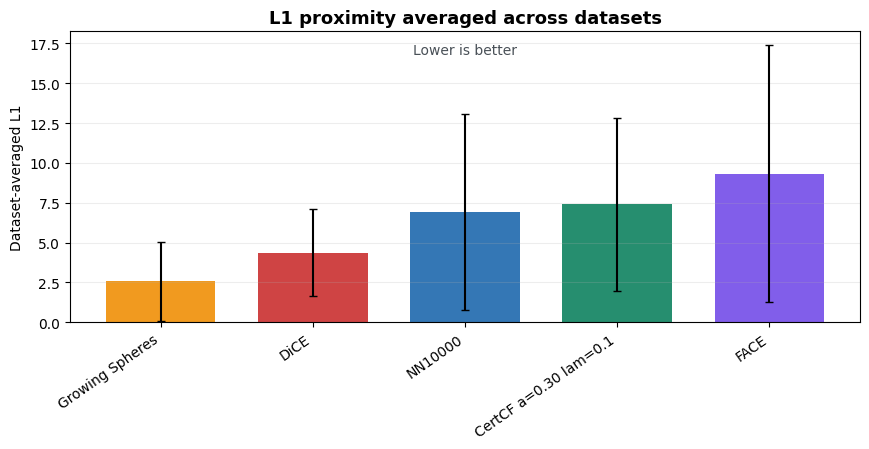

In [5]:
import matplotlib.pyplot as plt


def compute_l1_proximity_summary(
    df: pd.DataFrame,
    method_order: list[str],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    for dataset_name in DATASET_ORDER:
        ds = df[df['dataset'].astype(str).eq(dataset_name)]
        for method_label in method_order:
            method_df = ds[
                ds['method_label'].astype(str).eq(method_label)
                & ds['success'].astype(bool)
                & ds['l1_distance'].notna()
            ]
            if method_df.empty:
                continue
            l1 = method_df['l1_distance'].to_numpy(dtype=float)
            rows.append({
                'dataset': dataset_name,
                'method_label': method_label,
                'n_success': int(len(method_df)),
                'l1_mean': float(np.mean(l1)),
            })

    by_dataset = pd.DataFrame(rows)
    averaged = (
        by_dataset
        .groupby('method_label', observed=True)
        .agg(
            n_datasets=('dataset', 'nunique'),
            total_success=('n_success', 'sum'),
            dataset_avg_l1=('l1_mean', 'mean'),
            dataset_std_l1=('l1_mean', 'std'),
        )
        .reset_index()
    )
    averaged['method_label'] = pd.Categorical(averaged['method_label'].astype(str), method_order, ordered=True)
    averaged = averaged.sort_values('method_label', ignore_index=True)
    return by_dataset, averaged


def plot_l1_proximity_barplot(summary_df: pd.DataFrame):
    plot_df = summary_df.sort_values('dataset_avg_l1', ascending=True, ignore_index=True)
    labels = plot_df['method_label'].astype(str).tolist()
    x = np.arange(len(labels))
    colors = [PALETTE.get(label, '#868E96') for label in labels]
    y = plot_df['dataset_avg_l1'].to_numpy(dtype=float)
    yerr = plot_df['dataset_std_l1'].fillna(0.0).to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(8.8, 4.6))
    ax.bar(x, y, yerr=yerr, color=colors, alpha=0.88, capsize=3, width=0.72)
    ax.set_title('L1 proximity averaged across datasets', fontsize=13, fontweight='bold')
    ax.text(0.5, 0.96, 'Lower is better', transform=ax.transAxes, ha='center', va='top', fontsize=10, color='#495057')
    ax.set_ylabel('Dataset-averaged L1')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha='right')
    ax.grid(True, axis='y', alpha=0.22)
    fig.tight_layout()
    return fig, ax


CERTCF_L1_BY_DATASET_DF, CERTCF_L1_SWEEP_AVERAGED_DF = compute_l1_proximity_summary(
    CERTCF_SWEEP_DF,
    CERTCF_SWEEP_METHOD_ORDER,
)
CERTCF_L1_SWEEP_AVERAGED_DF = CERTCF_L1_SWEEP_AVERAGED_DF.sort_values('dataset_avg_l1', ascending=True, ignore_index=True)

print('All CertCF sweep runs sorted by raw dataset-averaged L1 proximity:')
display(CERTCF_L1_SWEEP_AVERAGED_DF.round(4))

PROXIMITY_CERTCF_LABEL = str(CERTCF_L1_SWEEP_AVERAGED_DF.iloc[0]['method_label'])
PROXIMITY_METHOD_ORDER = [PROXIMITY_CERTCF_LABEL, *BASELINE_METHOD_ORDER]
PROXIMITY_DF = ANALYSIS_DF[ANALYSIS_DF['method_label'].astype(str).isin(PROXIMITY_METHOD_ORDER)].copy()
PROXIMITY_DF['method_label'] = pd.Categorical(PROXIMITY_DF['method_label'].astype(str), PROXIMITY_METHOD_ORDER, ordered=True)

print(f'CertCF run selected for the proximity plot: {PROXIMITY_CERTCF_LABEL}')
L1_PROXIMITY_BY_DATASET_DF, L1_PROXIMITY_AVERAGED_DF = compute_l1_proximity_summary(
    PROXIMITY_DF,
    PROXIMITY_METHOD_ORDER,
)
display(L1_PROXIMITY_AVERAGED_DF.round(4))
plot_l1_proximity_barplot(L1_PROXIMITY_AVERAGED_DF);


### L1 Proximity on Shared Successful Queries

Shared successful query counts per dataset:


,dataset,n_shared_success_queries,n_total_CertCF a=0.30 lam=0.1,n_total_NN10000,n_total_Growing Spheres,n_total_DiCE,n_total_FACE
0,adult,891,1000,1000,1000,1000,1000
1,compas,517,617,617,617,617,617
2,german_credit,85,100,100,100,100,100
3,give_me_some_credit,989,1000,1000,1000,1000,1000
4,heloc,885,1000,1000,1000,1000,1000
5,lending_club,977,1000,1000,1000,1000,1000
6,wisconsin_breast_cancer,54,56,56,56,56,56


L1 proximity computed only on queries where every plotted method succeeded:


,method_label,n_datasets,total_shared_success_queries,dataset_avg_l1,dataset_std_l1
0,CertCF a=0.30 lam=0.1,7,4398,6.8128,5.0091
1,NN10000,7,4398,6.3337,5.7626
2,Growing Spheres,7,4398,2.3403,2.4461
3,DiCE,7,4398,4.1610,2.6027
4,FACE,7,4398,9.1504,7.7939


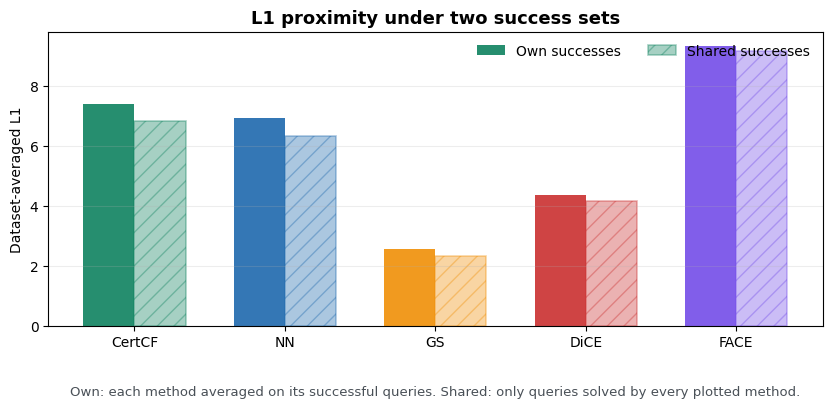

In [6]:
def compute_shared_success_l1_proximity_summary(
    df: pd.DataFrame,
    method_order: list[str],
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    rows = []
    shared_rows = []

    for dataset_name in DATASET_ORDER:
        ds = df[df['dataset'].astype(str).eq(dataset_name)]
        success_queries_by_method = {}
        total_queries_by_method = {}

        for method_label in method_order:
            method_df = ds[ds['method_label'].astype(str).eq(method_label)]
            if method_df.empty:
                success_queries_by_method[method_label] = set()
                total_queries_by_method[method_label] = 0
                continue
            total_queries_by_method[method_label] = int(method_df['query_idx'].nunique())
            successful = method_df[
                method_df['success'].astype(bool)
                & method_df['l1_distance'].notna()
            ]
            success_queries_by_method[method_label] = set(successful['query_idx'].tolist())

        if not success_queries_by_method or any(len(v) == 0 for v in success_queries_by_method.values()):
            continue

        shared_query_idx = sorted(set.intersection(*success_queries_by_method.values()))
        if not shared_query_idx:
            continue

        shared_rows.append({
            'dataset': dataset_name,
            'n_shared_success_queries': int(len(shared_query_idx)),
            **{f'n_total_{method_label}': total_queries_by_method.get(method_label, 0) for method_label in method_order},
        })

        for method_label in method_order:
            method_df = ds[
                ds['method_label'].astype(str).eq(method_label)
                & ds['query_idx'].isin(shared_query_idx)
                & ds['success'].astype(bool)
                & ds['l1_distance'].notna()
            ].copy()
            # There should be one row per method/query. Keep this explicit so the
            # shared set is not biased if a future result file contains duplicates.
            method_df = method_df.sort_values('query_idx').drop_duplicates('query_idx', keep='first')
            l1 = method_df['l1_distance'].to_numpy(dtype=float)
            rows.append({
                'dataset': dataset_name,
                'method_label': method_label,
                'n_shared_success_queries': int(len(method_df)),
                'l1_mean': float(np.mean(l1)),
            })

    by_dataset = pd.DataFrame(rows)
    shared_counts = pd.DataFrame(shared_rows)
    averaged = (
        by_dataset
        .groupby('method_label', observed=True)
        .agg(
            n_datasets=('dataset', 'nunique'),
            total_shared_success_queries=('n_shared_success_queries', 'sum'),
            dataset_avg_l1=('l1_mean', 'mean'),
            dataset_std_l1=('l1_mean', 'std'),
        )
        .reset_index()
    )
    averaged['method_label'] = pd.Categorical(averaged['method_label'].astype(str), method_order, ordered=True)
    averaged = averaged.sort_values('method_label', ignore_index=True)
    return by_dataset, averaged, shared_counts


def plot_shared_success_l1_proximity_barplot(summary_df: pd.DataFrame):
    plot_df = summary_df.sort_values('dataset_avg_l1', ascending=True, ignore_index=True)
    labels = plot_df['method_label'].astype(str).tolist()
    x = np.arange(len(labels))
    colors = [PALETTE.get(label, '#868E96') for label in labels]
    y = plot_df['dataset_avg_l1'].to_numpy(dtype=float)
    yerr = plot_df['dataset_std_l1'].fillna(0.0).to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(8.8, 4.6))
    ax.bar(x, y, yerr=yerr, color=colors, alpha=0.88, capsize=3, width=0.72)
    ax.set_title('L1 proximity on shared successful queries', fontsize=13, fontweight='bold')
    ax.text(
        0.5, 0.96,
        'Lower is better; same successful query set for every method within each dataset',
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=9.5,
        color='#495057',
    )
    ax.set_ylabel('Dataset-averaged L1')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha='right')
    ax.grid(True, axis='y', alpha=0.22)
    fig.tight_layout()
    return fig, ax


(
    SHARED_L1_PROXIMITY_BY_DATASET_DF,
    SHARED_L1_PROXIMITY_AVERAGED_DF,
    SHARED_L1_PROXIMITY_COUNTS_DF,
) = compute_shared_success_l1_proximity_summary(
    PROXIMITY_DF,
    PROXIMITY_METHOD_ORDER,
)

print('Shared successful query counts per dataset:')
display(SHARED_L1_PROXIMITY_COUNTS_DF)
print('L1 proximity computed only on queries where every plotted method succeeded:')
display(SHARED_L1_PROXIMITY_AVERAGED_DF.round(4))


def plot_l1_own_vs_shared_success(
    own_summary_df: pd.DataFrame,
    shared_summary_df: pd.DataFrame,
    method_order: list[str],
):
    own = (
        own_summary_df.assign(method_label=lambda x: x['method_label'].astype(str))
        .set_index('method_label')
        .reindex(method_order)
    )
    shared = (
        shared_summary_df.assign(method_label=lambda x: x['method_label'].astype(str))
        .set_index('method_label')
        .reindex(method_order)
    )

    display_labels = {
        method_order[0]: 'CertCF',
        'NN10000': 'NN',
        'Growing Spheres': 'GS',
        'DiCE': 'DiCE',
        'FACE': 'FACE',
    }
    labels = [display_labels.get(label, label) for label in method_order]
    x = np.arange(len(labels), dtype=float)
    width = 0.34
    own_y = own['dataset_avg_l1'].to_numpy(dtype=float)
    shared_y = shared['dataset_avg_l1'].to_numpy(dtype=float)
    base_colors = [PALETTE.get(label, '#868E96') for label in method_order]

    fig, ax = plt.subplots(figsize=(8.8, 4.6))
    ax.bar(
        x - width / 2,
        own_y,
        width=width,
        color=base_colors,
        alpha=0.88,
        label='Own successes',
    )
    ax.bar(
        x + width / 2,
        shared_y,
        width=width,
        color=base_colors,
        alpha=0.36,
        edgecolor=base_colors,
        linewidth=1.2,
        hatch='//',
        label='Shared successes',
    )

    ax.set_title('L1 proximity under two success sets', fontsize=13, fontweight='bold')
    ax.set_ylabel('Dataset-averaged L1')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.grid(True, axis='y', alpha=0.22)
    ax.legend(frameon=False, loc='upper right', ncol=2)
    ax.text(
        0.5,
        -0.20,
        'Own: each method averaged on its successful queries. Shared: only queries solved by every plotted method.',
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=9.5,
        color='#495057',
    )
    fig.subplots_adjust(bottom=0.24, top=0.88, left=0.10, right=0.98)
    return fig, ax
plot_l1_own_vs_shared_success(L1_PROXIMITY_AVERAGED_DF, SHARED_L1_PROXIMITY_AVERAGED_DF, PROXIMITY_METHOD_ORDER);


## Validity-Proximity 

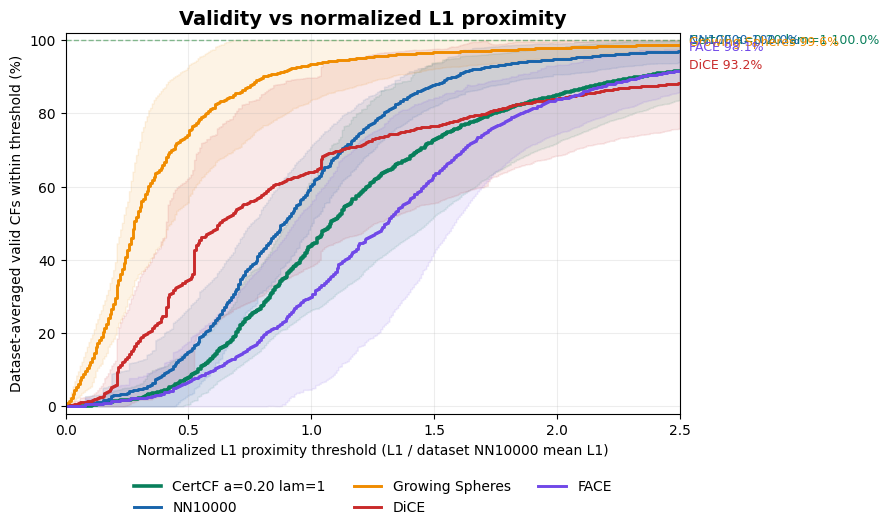

In [7]:
import matplotlib.pyplot as plt

NORMALIZED_L1_X_MAX = 2.5
NORMALIZED_L1_N_THRESHOLDS = 350


def nn10000_l1_scale_by_dataset(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for dataset in DATASET_ORDER:
        ds = df[df['dataset'].astype(str).eq(dataset)]
        nn = ds[
            ds['method_label'].astype(str).eq('NN10000')
            & ds['success'].astype(bool)
            & ds['l1_distance'].notna()
        ]
        fallback = ds[ds['success'].astype(bool) & ds['l1_distance'].notna()]
        if not nn.empty:
            scale = float(nn['l1_distance'].mean())
            source = 'NN10000 mean successful L1'
        elif not fallback.empty:
            scale = float(fallback['l1_distance'].median())
            source = 'all-method median successful L1 fallback'
        else:
            scale = np.nan
            source = 'missing'
        rows.append({'dataset': dataset, 'l1_scale': scale, 'scale_source': source})
    return pd.DataFrame(rows)


def build_aggregate_validity_vs_proximity(df: pd.DataFrame, scale_df: pd.DataFrame) -> pd.DataFrame:
    thresholds = np.linspace(0.0, NORMALIZED_L1_X_MAX, NORMALIZED_L1_N_THRESHOLDS)
    scale_by_dataset = scale_df.set_index('dataset')['l1_scale'].to_dict()
    rows = []

    for dataset in DATASET_ORDER:
        scale = scale_by_dataset.get(dataset, np.nan)
        if not np.isfinite(scale) or scale <= 0:
            continue
        ds = df[df['dataset'].astype(str).eq(dataset)]
        for method_label in METHOD_ORDER:
            method_df = ds[ds['method_label'].astype(str).eq(method_label)]
            if method_df.empty:
                continue
            distances = method_df['l1_distance'].to_numpy(dtype=float) / scale
            distances = np.where(method_df['success'].to_numpy(dtype=bool), distances, np.inf)
            finite_distances = np.sort(distances[np.isfinite(distances)])
            validity = np.searchsorted(finite_distances, thresholds, side='right') / len(method_df)
            final_validity_pct = 100.0 * float(method_df['success'].astype(bool).mean())
            for threshold, value in zip(thresholds, validity):
                rows.append({
                    'dataset': dataset,
                    'method_label': method_label,
                    'method': str(method_df['method'].iloc[0]),
                    'normalized_l1_threshold': float(threshold),
                    'validity_pct': 100.0 * float(value),
                    'final_validity_pct': final_validity_pct,
                })

    dataset_curve_df = pd.DataFrame(rows)
    aggregate_curve_df = (
        dataset_curve_df
        .groupby(['method_label', 'method', 'normalized_l1_threshold'], observed=True, sort=False)
        .agg(
            mean_validity_pct=('validity_pct', 'mean'),
            std_validity_pct=('validity_pct', 'std'),
            mean_final_validity_pct=('final_validity_pct', 'mean'),
            n_datasets=('dataset', 'nunique'),
        )
        .reset_index()
    )
    aggregate_curve_df['std_validity_pct'] = aggregate_curve_df['std_validity_pct'].fillna(0.0)
    return aggregate_curve_df


def plot_aggregate_validity_vs_proximity(curve_df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(10.5, 6.0))
    for method_label in METHOD_ORDER:
        curve = curve_df[curve_df['method_label'].astype(str).eq(method_label)].sort_values('normalized_l1_threshold')
        if curve.empty:
            continue
        x = curve['normalized_l1_threshold'].to_numpy(dtype=float)
        y = curve['mean_validity_pct'].to_numpy(dtype=float)
        y_std = curve['std_validity_pct'].to_numpy(dtype=float)
        color = PALETTE.get(method_label, '#868E96')
        ax.step(x, y, where='post', color=color, linewidth=2.6 if method_label.startswith('CertCF') else 2.1, label=method_label)
        ax.fill_between(x, np.clip(y - y_std, 0, 100), np.clip(y + y_std, 0, 100), step='post', color=color, alpha=0.10)
        ax.text(
            NORMALIZED_L1_X_MAX + 0.04,
            float(curve['mean_final_validity_pct'].iloc[-1]),
            f"{method_label} {curve['mean_final_validity_pct'].iloc[-1]:.1f}%",
            color=color,
            va='center',
            fontsize=9,
        )

    ax.axhline(100.0, color='#2B8A3E', linewidth=1.0, linestyle='--', alpha=0.55)
    ax.set_xlim(0.0, NORMALIZED_L1_X_MAX)
    ax.set_ylim(-2.0, 102.0)
    ax.set_xlabel('Normalized L1 proximity threshold (L1 / dataset NN10000 mean L1)')
    ax.set_ylabel('Dataset-averaged valid CFs within threshold (%)')
    ax.set_title('Validity vs normalized L1 proximity', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.22)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=3, frameon=False)
    fig.tight_layout(rect=(0, 0.08, 0.86, 1))
    return fig, ax


L1_SCALE_DF = nn10000_l1_scale_by_dataset(BENCHMARK_DF)
AGGREGATE_VALIDITY_PROXIMITY_DF = build_aggregate_validity_vs_proximity(BENCHMARK_DF, L1_SCALE_DF)
plot_aggregate_validity_vs_proximity(AGGREGATE_VALIDITY_PROXIMITY_DF);

## Robustness

,method_label,n_datasets,total_success,total_perturbed,dataset_avg_target_robustness_pct,dataset_std_target_robustness_pct
0,CertCF a=0.20 lam=1,7,4773,143190,92.3355,5.5603
1,NN10000,7,4773,143190,86.6856,6.7853
2,Growing Spheres,7,4763,142890,71.0206,8.1551
3,DiCE,7,4463,133890,91.2759,8.1325
4,FACE,7,4683,140490,87.8425,7.5677


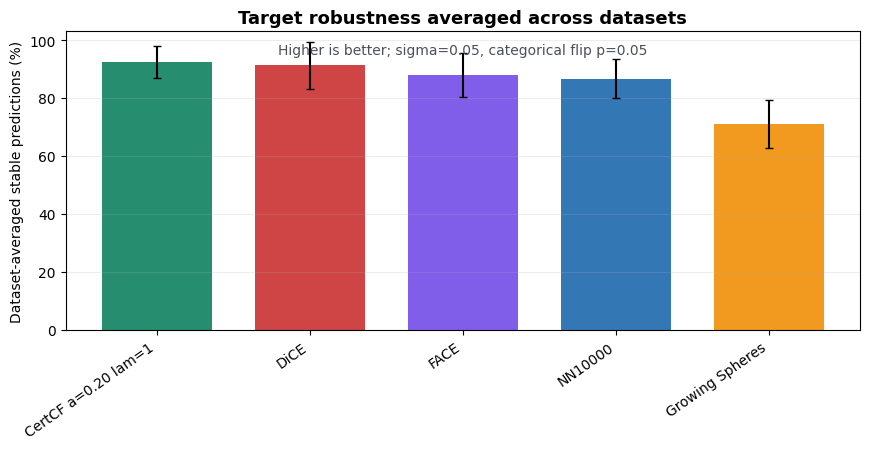

In [8]:
import yaml
from dataset_specs import get_tabular_dataset_spec
from scripts.benchmark import _build_torch_model_from_checkpoint

ROBUSTNESS_SIGMA_GRID = [0.00, 0.01, 0.03, 0.05, 0.10]
ROBUSTNESS_CAT_FLIP_GRID = [0.00, 0.01, 0.03, 0.05, 0.10]
ROBUSTNESS_GRID_N_PERTURBATIONS = 10
ROBUSTNESS_MAX_CFS_PER_DATASET_METHOD = None
ROBUSTNESS_BATCH_SIZE = 8192
ROBUSTNESS_RANDOM_STATE = 0
FINAL_BENCHMARK_CONFIG = ROOT / 'configs' / 'benchmarks' / 'final_benchmark_noface.yaml'

# Backward-compatible aliases used by the heatmap/LaTeX cells below.
ROBUSTNESS_HEATMAP_N_PERTURBATIONS = ROBUSTNESS_GRID_N_PERTURBATIONS
ROBUSTNESS_HEATMAP_MAX_CFS_PER_DATASET_METHOD = ROBUSTNESS_MAX_CFS_PER_DATASET_METHOD


def load_robustness_models(config_path: Path = FINAL_BENCHMARK_CONFIG) -> dict[str, object]:
    with open(config_path, 'r') as f:
        cfg = yaml.safe_load(f)

    models = {}
    for ds_cfg in cfg['datasets']:
        dataset_name = ds_cfg['name']
        model_params = dict(ds_cfg['model']['params'])
        checkpoint = ROOT / model_params['checkpoint']
        models[dataset_name] = _build_torch_model_from_checkpoint(
            checkpoint=str(checkpoint),
            device='cpu',
            dataset_module=model_params.get('dataset_module', dataset_name),
            hidden_dims=list(model_params.get('hidden_dims', [64, 32])),
            dropout=float(model_params.get('dropout', 0.2)),
        )
    return models


def predict_in_batches(model, x: np.ndarray, batch_size: int = ROBUSTNESS_BATCH_SIZE) -> np.ndarray:
    preds = []
    for start in range(0, len(x), batch_size):
        preds.append(model.predict(x[start:start + batch_size].astype(np.float32, copy=False)))
    return np.concatenate(preds)


def snap_ohe_blocks(x: np.ndarray, categorical_slices: tuple[tuple[int, int], ...]) -> np.ndarray:
    out = x.copy()
    for start, end in categorical_slices:
        if end <= start:
            continue
        chosen = np.argmax(out[:, start:end], axis=1)
        out[:, start:end] = 0.0
        out[np.arange(len(out)), start + chosen] = 1.0
    return out


def perturb_counterfactuals(
    x_cf: np.ndarray,
    spec,
    n_perturbations: int,
    numerical_sigma: float,
    categorical_flip_p: float,
    rng: np.random.Generator,
) -> np.ndarray:
    feature_slices = tuple(spec.feature_slices)
    input_types = tuple(spec.input_types)
    numerical_dims = [start for feature_type, (start, end) in zip(input_types, feature_slices) if feature_type == 'numerical']
    categorical_slices = tuple(spec.categorical_slices)

    base = snap_ohe_blocks(x_cf, categorical_slices)
    perturbed = np.repeat(base, n_perturbations, axis=0)

    if numerical_dims and numerical_sigma > 0:
        noise = rng.normal(0.0, numerical_sigma, size=(len(perturbed), len(numerical_dims)))
        perturbed[:, numerical_dims] += noise

    if categorical_flip_p > 0:
        for start, end in categorical_slices:
            width = end - start
            if width <= 1:
                continue
            current = np.argmax(perturbed[:, start:end], axis=1)
            flip = rng.random(len(perturbed)) < categorical_flip_p
            if not flip.any():
                continue
            replacement = rng.integers(0, width - 1, size=int(flip.sum()))
            replacement = replacement + (replacement >= current[flip])
            perturbed[flip, start:end] = 0.0
            perturbed[np.flatnonzero(flip), start + replacement] = 1.0

    return perturbed.astype(np.float32, copy=False)


def compute_robustness_grid(
    df: pd.DataFrame,
    sigma_grid: list[float] = ROBUSTNESS_SIGMA_GRID,
    categorical_flip_grid: list[float] = ROBUSTNESS_CAT_FLIP_GRID,
    n_perturbations: int = ROBUSTNESS_GRID_N_PERTURBATIONS,
    max_cfs_per_dataset_method: int | None = ROBUSTNESS_MAX_CFS_PER_DATASET_METHOD,
    random_state: int = ROBUSTNESS_RANDOM_STATE,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    models = load_robustness_models()
    rows = []

    for sigma_idx, sigma in enumerate(sigma_grid):
        for flip_idx, categorical_flip_p in enumerate(categorical_flip_grid):
            for dataset_idx, dataset_name in enumerate(DATASET_ORDER):
                spec = get_tabular_dataset_spec(dataset_name)
                model = models[dataset_name]
                cf_cols = [f'x_cf_{idx}' for idx in range(spec.n_features)]
                ds = df[df['dataset'].astype(str).eq(dataset_name)]
                if ds.empty or not set(cf_cols).issubset(ds.columns):
                    continue

                for method_idx, method_label in enumerate(METHOD_ORDER):
                    method_df = ds[
                        ds['method_label'].astype(str).eq(method_label)
                        & ds['success'].astype(bool)
                    ].copy()
                    if method_df.empty:
                        continue

                    seed = (
                        random_state
                        + 100000 * sigma_idx
                        + 10000 * flip_idx
                        + 1000 * dataset_idx
                        + 100 * method_idx
                    )
                    rng = np.random.default_rng(seed)
                    if max_cfs_per_dataset_method is not None and len(method_df) > max_cfs_per_dataset_method:
                        method_df = method_df.sample(n=max_cfs_per_dataset_method, random_state=seed)

                    x_cf = method_df[cf_cols].to_numpy(dtype=np.float32)
                    finite = np.isfinite(x_cf).all(axis=1)
                    if not finite.any():
                        continue
                    method_df = method_df.loc[finite]
                    x_cf = x_cf[finite]

                    targets = method_df['y_cf'].fillna(method_df['target_class']).to_numpy(dtype=int)
                    x_perturbed = perturb_counterfactuals(
                        x_cf=x_cf,
                        spec=spec,
                        n_perturbations=n_perturbations,
                        numerical_sigma=sigma,
                        categorical_flip_p=categorical_flip_p,
                        rng=rng,
                    )
                    pred = predict_in_batches(model, x_perturbed)
                    stable = pred == np.repeat(targets, n_perturbations)

                    rows.append({
                        'dataset': dataset_name,
                        'method_label': method_label,
                        'numerical_sigma': float(sigma),
                        'categorical_flip_p': float(categorical_flip_p),
                        'n_success': int(len(x_cf)),
                        'n_perturbed': int(len(x_perturbed)),
                        'target_robustness_pct': 100.0 * float(np.mean(stable)),
                    })

    by_dataset = pd.DataFrame(rows)
    averaged = (
        by_dataset
        .groupby(['method_label', 'numerical_sigma', 'categorical_flip_p'], observed=True)
        .agg(
            n_datasets=('dataset', 'nunique'),
            total_success=('n_success', 'sum'),
            total_perturbed=('n_perturbed', 'sum'),
            dataset_avg_target_robustness_pct=('target_robustness_pct', 'mean'),
            dataset_std_target_robustness_pct=('target_robustness_pct', 'std'),
        )
        .reset_index()
    )
    averaged['method_label'] = pd.Categorical(averaged['method_label'], METHOD_ORDER, ordered=True)
    return by_dataset, averaged.sort_values(['method_label', 'numerical_sigma', 'categorical_flip_p'], ignore_index=True)


def summarize_robustness_grid(grid_by_dataset_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Collapse the robustness surface into one score by averaging all grid cells."""
    by_dataset = (
        grid_by_dataset_df
        .groupby(['dataset', 'method_label'], observed=True)
        .agg(
            n_grid_cells=('target_robustness_pct', 'size'),
            n_success=('n_success', 'max'),
            total_perturbed=('n_perturbed', 'sum'),
            target_robustness_pct=('target_robustness_pct', 'mean'),
        )
        .reset_index()
    )
    averaged = (
        by_dataset
        .groupby('method_label', observed=True)
        .agg(
            n_datasets=('dataset', 'nunique'),
            total_success=('n_success', 'sum'),
            total_perturbed=('total_perturbed', 'sum'),
            dataset_avg_target_robustness_pct=('target_robustness_pct', 'mean'),
            dataset_std_target_robustness_pct=('target_robustness_pct', 'std'),
        )
        .reset_index()
    )
    averaged['method_label'] = pd.Categorical(averaged['method_label'], METHOD_ORDER, ordered=True)
    averaged = averaged.sort_values('method_label', ignore_index=True)
    return by_dataset, averaged


def compute_robustness_summary(
    df: pd.DataFrame,
    sigma_grid: list[float] = ROBUSTNESS_SIGMA_GRID,
    categorical_flip_grid: list[float] = ROBUSTNESS_CAT_FLIP_GRID,
    n_perturbations: int = ROBUSTNESS_GRID_N_PERTURBATIONS,
    max_cfs_per_dataset_method: int | None = ROBUSTNESS_MAX_CFS_PER_DATASET_METHOD,
    random_state: int = ROBUSTNESS_RANDOM_STATE,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    grid_by_dataset, _ = compute_robustness_grid(
        df,
        sigma_grid=sigma_grid,
        categorical_flip_grid=categorical_flip_grid,
        n_perturbations=n_perturbations,
        max_cfs_per_dataset_method=max_cfs_per_dataset_method,
        random_state=random_state,
    )
    return summarize_robustness_grid(grid_by_dataset)


def plot_robustness_barplot(summary_df: pd.DataFrame):
    plot_df = summary_df.sort_values('dataset_avg_target_robustness_pct', ascending=False, ignore_index=True)
    labels = plot_df['method_label'].astype(str).tolist()
    x = np.arange(len(labels))
    colors = [PALETTE.get(label, '#868E96') for label in labels]
    y = plot_df['dataset_avg_target_robustness_pct'].to_numpy(dtype=float)
    yerr = plot_df['dataset_std_target_robustness_pct'].fillna(0.0).to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(8.8, 4.6))
    ax.bar(x, y, yerr=yerr, color=colors, alpha=0.88, capsize=3, width=0.72)
    ax.set_title('Target robustness averaged over perturbation grid', fontsize=13, fontweight='bold')
    ax.text(
        0.5,
        0.96,
        f'Higher is better; averaged over {len(ROBUSTNESS_SIGMA_GRID) * len(ROBUSTNESS_CAT_FLIP_GRID)} sigma/flip cells',
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=10,
        color='#495057',
    )
    ax.set_ylabel('Dataset-averaged stable predictions (%)')
    ax.set_ylim(0.0, 103.0)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha='right')
    ax.grid(True, axis='y', alpha=0.22)
    fig.tight_layout()
    return fig, ax


ROBUSTNESS_GRID_BY_DATASET_DF, ROBUSTNESS_GRID_AVERAGED_DF = compute_robustness_grid(BENCHMARK_DF)
ROBUSTNESS_BY_DATASET_DF, ROBUSTNESS_AVERAGED_DF = summarize_robustness_grid(ROBUSTNESS_GRID_BY_DATASET_DF)
display(ROBUSTNESS_AVERAGED_DF.round(4))
plot_robustness_barplot(ROBUSTNESS_AVERAGED_DF);


### Robustness on Shared Successful Queries

Shared successful query counts per dataset:


,dataset,n_shared_success_queries,n_total_CertCF a=0.20 lam=1,n_total_NN10000,n_total_Growing Spheres,n_total_DiCE,n_total_FACE
0,adult,891,1000,1000,1000,1000,1000
1,compas,517,617,617,617,617,617
2,german_credit,85,100,100,100,100,100
3,give_me_some_credit,989,1000,1000,1000,1000,1000
4,heloc,885,1000,1000,1000,1000,1000
5,lending_club,977,1000,1000,1000,1000,1000
6,wisconsin_breast_cancer,54,56,56,56,56,56


Robustness computed only on queries where every plotted method succeeded:


,method_label,n_datasets,total_success,total_perturbed,dataset_avg_target_robustness_pct,dataset_std_target_robustness_pct
0,CertCF a=0.20 lam=1,7,4398,131940,92.0325,5.7526
1,NN10000,7,4398,131940,86.7331,7.1782
2,Growing Spheres,7,4398,131940,69.8906,7.6286
3,DiCE,7,4398,131940,91.3979,7.9993
4,FACE,7,4398,131940,87.9736,7.4986


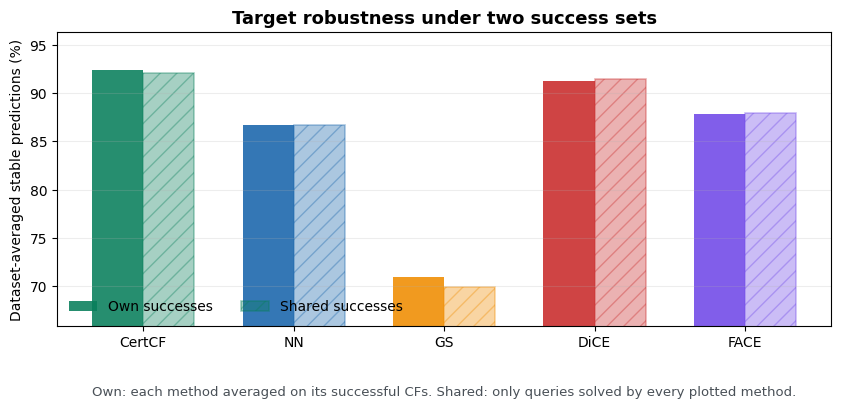

In [9]:
def filter_to_shared_success_queries(
    df: pd.DataFrame,
    method_order: list[str],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    shared_parts = []
    count_rows = []

    for dataset_name in DATASET_ORDER:
        ds = df[df['dataset'].astype(str).eq(dataset_name)]
        success_queries_by_method = {}
        total_queries_by_method = {}

        for method_label in method_order:
            method_df = ds[ds['method_label'].astype(str).eq(method_label)]
            total_queries_by_method[method_label] = int(method_df['query_idx'].nunique())
            success_queries_by_method[method_label] = set(
                method_df.loc[method_df['success'].astype(bool), 'query_idx'].tolist()
            )

        if not success_queries_by_method or any(len(v) == 0 for v in success_queries_by_method.values()):
            continue
        shared_query_idx = sorted(set.intersection(*success_queries_by_method.values()))
        if not shared_query_idx:
            continue

        count_rows.append({
            'dataset': dataset_name,
            'n_shared_success_queries': int(len(shared_query_idx)),
            **{f'n_total_{method_label}': total_queries_by_method.get(method_label, 0) for method_label in method_order},
        })
        shared_parts.append(
            ds[
                ds['method_label'].astype(str).isin(method_order)
                & ds['query_idx'].isin(shared_query_idx)
            ].copy()
        )

    if not shared_parts:
        return df.iloc[0:0].copy(), pd.DataFrame(count_rows)
    return pd.concat(shared_parts, ignore_index=True), pd.DataFrame(count_rows)


def plot_robustness_own_vs_shared_success(
    own_summary_df: pd.DataFrame,
    shared_summary_df: pd.DataFrame,
    method_order: list[str],
):
    own = (
        own_summary_df.assign(method_label=lambda x: x['method_label'].astype(str))
        .set_index('method_label')
        .reindex(method_order)
    )
    shared = (
        shared_summary_df.assign(method_label=lambda x: x['method_label'].astype(str))
        .set_index('method_label')
        .reindex(method_order)
    )

    display_labels = {
        method_order[0]: 'CertCF',
        'NN10000': 'NN',
        'Growing Spheres': 'GS',
        'DiCE': 'DiCE',
        'FACE': 'FACE',
    }
    labels = [display_labels.get(label, label) for label in method_order]
    x = np.arange(len(labels), dtype=float)
    width = 0.34
    own_y = own['dataset_avg_target_robustness_pct'].to_numpy(dtype=float)
    shared_y = shared['dataset_avg_target_robustness_pct'].to_numpy(dtype=float)
    base_colors = [PALETTE.get(label, '#868E96') for label in method_order]

    fig, ax = plt.subplots(figsize=(8.8, 4.6))
    ax.bar(
        x - width / 2,
        own_y,
        width=width,
        color=base_colors,
        alpha=0.88,
        label='Own successes',
    )
    ax.bar(
        x + width / 2,
        shared_y,
        width=width,
        color=base_colors,
        alpha=0.36,
        edgecolor=base_colors,
        linewidth=1.2,
        hatch='//',
        label='Shared successes',
    )

    ax.set_title('Target robustness under two success sets', fontsize=13, fontweight='bold')
    ax.set_ylabel('Dataset-averaged stable predictions (%)')
    finite_y = np.concatenate([own_y[np.isfinite(own_y)], shared_y[np.isfinite(shared_y)]])
    if finite_y.size:
        y_min = max(60.0, float(finite_y.min()) - 4.0)
        y_max = min(100.0, float(finite_y.max()) + 4.0)
        ax.set_ylim(y_min, y_max)
    else:
        ax.set_ylim(0.0, 103.0)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.grid(True, axis='y', alpha=0.22)
    ax.legend(frameon=False, loc='lower left', ncol=2)
    ax.text(
        0.5,
        -0.20,
        'Own: each method averaged on its successful CFs. Shared: only queries solved by every plotted method.',
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=9.5,
        color='#495057',
    )
    fig.subplots_adjust(bottom=0.24, top=0.88, left=0.10, right=0.98)
    return fig, ax


SHARED_ROBUSTNESS_DF, SHARED_ROBUSTNESS_COUNTS_DF = filter_to_shared_success_queries(
    BENCHMARK_DF,
    METHOD_ORDER,
)
SHARED_ROBUSTNESS_BY_DATASET_DF, SHARED_ROBUSTNESS_AVERAGED_DF = compute_robustness_summary(
    SHARED_ROBUSTNESS_DF,
)

print('Shared successful query counts per dataset:')
display(SHARED_ROBUSTNESS_COUNTS_DF)
print('Robustness computed only on queries where every plotted method succeeded:')
display(SHARED_ROBUSTNESS_AVERAGED_DF.round(4))
plot_robustness_own_vs_shared_success(ROBUSTNESS_AVERAGED_DF, SHARED_ROBUSTNESS_AVERAGED_DF, METHOD_ORDER);


## Confidence

,method_label,n_datasets,total_success,dataset_avg_target_probability,dataset_std_target_probability
0,CertCF a=0.20 lam=1,7,4773,0.6942,0.1322
1,NN10000,7,4773,0.6389,0.1082
2,Growing Spheres,7,4763,0.5462,0.0383
3,DiCE,7,4463,0.7190,0.1153
4,FACE,7,4683,0.6698,0.1467


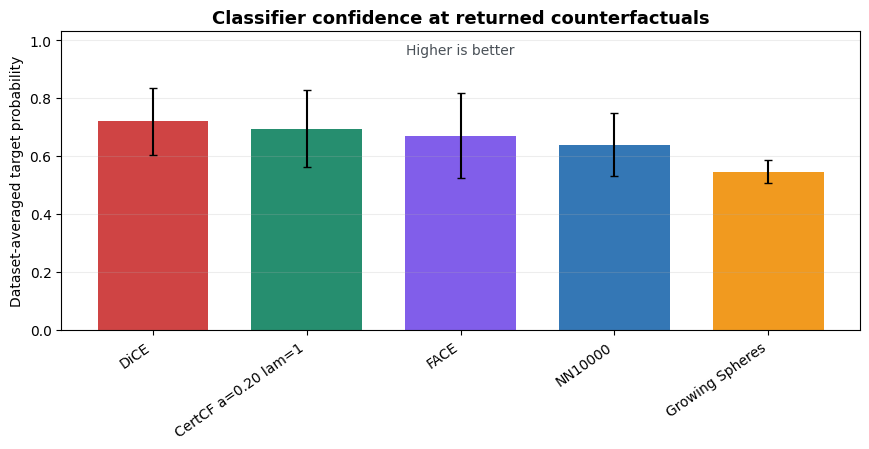

In [10]:
import torch

CONFIDENCE_BATCH_SIZE = 8192


def proba_in_batches(model, x: np.ndarray, batch_size: int = CONFIDENCE_BATCH_SIZE) -> np.ndarray:
    proba_batches = []
    torch_model = model.model
    device = model.device
    with torch.no_grad():
        for start in range(0, len(x), batch_size):
            xb = torch.from_numpy(x[start:start + batch_size].astype(np.float32, copy=False)).to(device)
            logits = torch_model(xb)
            proba = torch.softmax(logits, dim=1)
            proba_batches.append(proba.detach().cpu().numpy())
    return np.vstack(proba_batches)


def compute_confidence_summary(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    models = load_robustness_models()
    rows = []

    for dataset_name in DATASET_ORDER:
        spec = get_tabular_dataset_spec(dataset_name)
        model = models[dataset_name]
        cf_cols = [f'x_cf_{idx}' for idx in range(spec.n_features)]
        ds = df[df['dataset'].astype(str).eq(dataset_name)]
        if ds.empty or not set(cf_cols).issubset(ds.columns):
            continue

        for method_label in METHOD_ORDER:
            method_df = ds[
                ds['method_label'].astype(str).eq(method_label)
                & ds['success'].astype(bool)
            ].copy()
            if method_df.empty:
                continue

            x_cf = method_df[cf_cols].to_numpy(dtype=np.float32)
            finite = np.isfinite(x_cf).all(axis=1)
            if not finite.any():
                continue
            method_df = method_df.loc[finite]
            x_cf = x_cf[finite]
            targets = method_df['y_cf'].fillna(method_df['target_class']).to_numpy(dtype=int)

            proba = proba_in_batches(model, x_cf)
            target_proba = proba[np.arange(len(x_cf)), targets]

            rows.append({
                'dataset': dataset_name,
                'method_label': method_label,
                'n_success': int(len(x_cf)),
                'mean_target_probability': float(np.mean(target_proba)),
            })

    by_dataset = pd.DataFrame(rows)
    averaged = (
        by_dataset
        .groupby('method_label', observed=True)
        .agg(
            n_datasets=('dataset', 'nunique'),
            total_success=('n_success', 'sum'),
            dataset_avg_target_probability=('mean_target_probability', 'mean'),
            dataset_std_target_probability=('mean_target_probability', 'std'),
        )
        .reset_index()
    )
    averaged['method_label'] = pd.Categorical(averaged['method_label'], METHOD_ORDER, ordered=True)
    averaged = averaged.sort_values('method_label', ignore_index=True)
    return by_dataset, averaged


def plot_confidence_barplot(summary_df: pd.DataFrame):
    plot_df = summary_df.sort_values('dataset_avg_target_probability', ascending=False, ignore_index=True)
    labels = plot_df['method_label'].astype(str).tolist()
    x = np.arange(len(labels))
    colors = [PALETTE.get(label, '#868E96') for label in labels]
    y = plot_df['dataset_avg_target_probability'].to_numpy(dtype=float)
    yerr = plot_df['dataset_std_target_probability'].fillna(0.0).to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(8.8, 4.6))
    ax.bar(x, y, yerr=yerr, color=colors, alpha=0.88, capsize=3, width=0.72)
    ax.set_title('Classifier confidence at returned counterfactuals', fontsize=13, fontweight='bold')
    ax.text(0.5, 0.96, 'Higher is better', transform=ax.transAxes, ha='center', va='top', fontsize=10, color='#495057')
    ax.set_ylabel('Dataset-averaged target probability')
    ax.set_ylim(0.0, 1.03)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha='right')
    ax.grid(True, axis='y', alpha=0.22)
    fig.tight_layout()
    return fig, ax


CONFIDENCE_BY_DATASET_DF, CONFIDENCE_AVERAGED_DF = compute_confidence_summary(BENCHMARK_DF)
display(CONFIDENCE_AVERAGED_DF.round(4))
plot_confidence_barplot(CONFIDENCE_AVERAGED_DF);

## Efficiency and Resource Usage

,method_label,n_datasets,total_queries,total_success,dataset_avg_query_batch_size,dataset_avg_build_time_s,dataset_std_build_time_s,dataset_avg_query_time_s,dataset_std_query_time_s,dataset_avg_median_query_time_s,dataset_avg_success_query_time_s,dataset_avg_ram_rss_mb_peak,dataset_std_ram_rss_mb_peak,dataset_avg_ram_rss_mb_peak_delta,dataset_std_ram_rss_mb_peak_delta,dataset_avg_ram_rss_mb_mean
0,CertCF a=0.20 lam=1,7,4773,4773,1.0,22.2594,8.6719,0.4296,0.5892,0.1989,0.4296,NaN,NaN,NaN,NaN,NaN
1,NN10000,7,4773,4773,1.0,0.0013,0.0021,0.0003,0.0004,0.0003,0.0003,NaN,NaN,NaN,NaN,NaN
2,Growing Spheres,7,4773,4763,1.0,0.0006,0.0006,0.0280,0.0306,0.0246,0.0276,NaN,NaN,NaN,NaN,NaN
3,DiCE,7,4773,4463,250.0,0.0040,0.0026,0.2475,0.3301,0.2489,0.2475,NaN,NaN,NaN,NaN,NaN
4,FACE,7,4773,4683,1.0,3080.3492,5110.2204,2.4032,2.7177,2.5368,2.3967,6056.9252,2342.4537,1904.4023,3403.6015,4932.6306


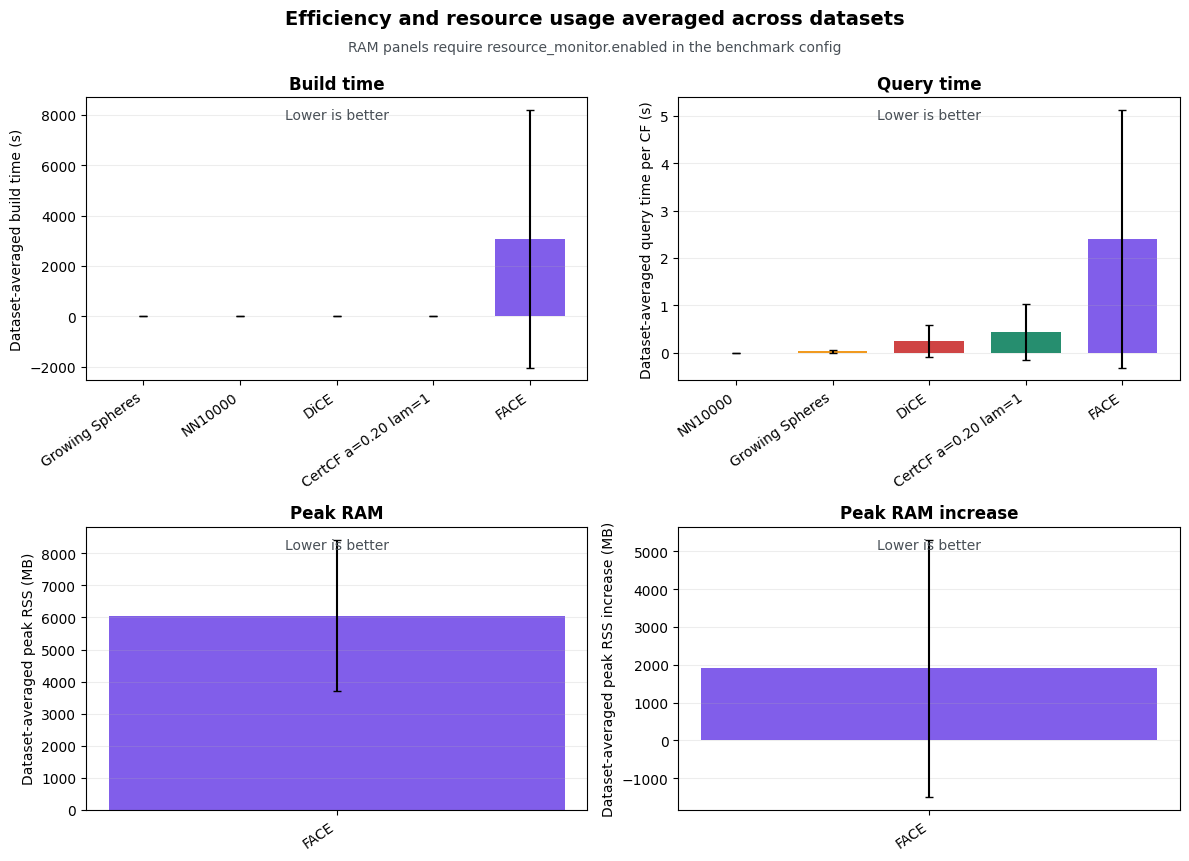

In [11]:
def first_numeric(method_df: pd.DataFrame, column: str) -> float:
    if column not in method_df.columns:
        return np.nan
    values = pd.to_numeric(method_df[column], errors='coerce').dropna().to_numpy(dtype=float)
    return float(values[0]) if len(values) else np.nan


def compute_efficiency_summary(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    for dataset_name in DATASET_ORDER:
        ds = df[df['dataset'].astype(str).eq(dataset_name)]
        for method_label in METHOD_ORDER:
            method_df = ds[ds['method_label'].astype(str).eq(method_label)]
            if method_df.empty:
                continue

            build_values = method_df['build_time_s'].dropna().to_numpy(dtype=float)
            runtime_values = method_df['runtime_s'].dropna().to_numpy(dtype=float)
            success_runtime_values = method_df.loc[method_df['success'].astype(bool), 'runtime_s'].dropna().to_numpy(dtype=float)
            ram_start = first_numeric(method_df, 'method_meta__ram_rss_mb_start')
            ram_peak = first_numeric(method_df, 'method_meta__ram_rss_mb_peak')
            ram_mean = first_numeric(method_df, 'method_meta__ram_rss_mb_mean')
            ram_end = first_numeric(method_df, 'method_meta__ram_rss_mb_end')
            query_batch_size = first_numeric(method_df, 'method_meta__query_batch_size')

            rows.append({
                'dataset': dataset_name,
                'method_label': method_label,
                'n_queries': int(len(method_df)),
                'n_success': int(method_df['success'].astype(bool).sum()),
                'query_batch_size': query_batch_size,
                'build_time_s': float(build_values[0]) if len(build_values) else np.nan,
                'mean_query_time_s': float(np.mean(runtime_values)) if len(runtime_values) else np.nan,
                'median_query_time_s': float(np.median(runtime_values)) if len(runtime_values) else np.nan,
                'mean_success_query_time_s': float(np.mean(success_runtime_values)) if len(success_runtime_values) else np.nan,
                'ram_rss_mb_start': ram_start,
                'ram_rss_mb_peak': ram_peak,
                'ram_rss_mb_mean': ram_mean,
                'ram_rss_mb_end': ram_end,
                'ram_rss_mb_peak_delta': ram_peak - ram_start if np.isfinite(ram_peak) and np.isfinite(ram_start) else np.nan,
            })

    by_dataset = pd.DataFrame(rows)
    averaged = (
        by_dataset
        .groupby('method_label', observed=True)
        .agg(
            n_datasets=('dataset', 'nunique'),
            total_queries=('n_queries', 'sum'),
            total_success=('n_success', 'sum'),
            dataset_avg_query_batch_size=('query_batch_size', 'mean'),
            dataset_avg_build_time_s=('build_time_s', 'mean'),
            dataset_std_build_time_s=('build_time_s', 'std'),
            dataset_avg_query_time_s=('mean_query_time_s', 'mean'),
            dataset_std_query_time_s=('mean_query_time_s', 'std'),
            dataset_avg_median_query_time_s=('median_query_time_s', 'mean'),
            dataset_avg_success_query_time_s=('mean_success_query_time_s', 'mean'),
            dataset_avg_ram_rss_mb_peak=('ram_rss_mb_peak', 'mean'),
            dataset_std_ram_rss_mb_peak=('ram_rss_mb_peak', 'std'),
            dataset_avg_ram_rss_mb_peak_delta=('ram_rss_mb_peak_delta', 'mean'),
            dataset_std_ram_rss_mb_peak_delta=('ram_rss_mb_peak_delta', 'std'),
            dataset_avg_ram_rss_mb_mean=('ram_rss_mb_mean', 'mean'),
        )
        .reset_index()
    )
    averaged['method_label'] = pd.Categorical(averaged['method_label'], METHOD_ORDER, ordered=True)
    averaged = averaged.sort_values('method_label', ignore_index=True)
    return by_dataset, averaged


def plot_metric_bar(ax, summary_df: pd.DataFrame, value_col: str, err_col: str, title: str, ylabel: str):
    plot_df = summary_df[np.isfinite(pd.to_numeric(summary_df[value_col], errors='coerce'))].copy()
    if plot_df.empty:
        ax.axis('off')
        ax.text(0.5, 0.5, 'No RAM monitor data', ha='center', va='center', transform=ax.transAxes, color='#495057')
        ax.set_title(title, fontsize=12, fontweight='bold')
        return

    plot_df = plot_df.sort_values(value_col, ascending=True, ignore_index=True)
    labels = plot_df['method_label'].astype(str).tolist()
    x = np.arange(len(labels))
    colors = [PALETTE.get(label, '#868E96') for label in labels]
    y = plot_df[value_col].to_numpy(dtype=float)
    yerr = plot_df[err_col].fillna(0.0).to_numpy(dtype=float) if err_col in plot_df.columns else np.zeros_like(y)

    ax.bar(x, y, yerr=yerr, color=colors, alpha=0.88, capsize=3, width=0.72)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.text(0.5, 0.96, 'Lower is better', transform=ax.transAxes, ha='center', va='top', fontsize=10, color='#495057')
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha='right')
    ax.grid(True, axis='y', alpha=0.22)


def plot_efficiency_barplots(summary_df: pd.DataFrame):
    fig, axes = plt.subplots(2, 2, figsize=(12.0, 8.4), sharex=False)
    specs = [
        ('dataset_avg_build_time_s', 'dataset_std_build_time_s', 'Build time', 'Dataset-averaged build time (s)', axes[0, 0]),
        ('dataset_avg_query_time_s', 'dataset_std_query_time_s', 'Query time', 'Dataset-averaged query time per CF (s)', axes[0, 1]),
        ('dataset_avg_ram_rss_mb_peak', 'dataset_std_ram_rss_mb_peak', 'Peak RAM', 'Dataset-averaged peak RSS (MB)', axes[1, 0]),
        ('dataset_avg_ram_rss_mb_peak_delta', 'dataset_std_ram_rss_mb_peak_delta', 'Peak RAM increase', 'Dataset-averaged peak RSS increase (MB)', axes[1, 1]),
    ]
    for value_col, err_col, title, ylabel, ax in specs:
        plot_metric_bar(ax, summary_df, value_col, err_col, title, ylabel)

    fig.suptitle('Efficiency and resource usage averaged across datasets', fontsize=14, fontweight='bold', y=1.02)
    fig.text(0.5, 0.975, 'RAM panels require resource_monitor.enabled in the benchmark config', ha='center', va='center', fontsize=10, color='#495057')
    fig.tight_layout()
    return fig, axes


EFFICIENCY_BY_DATASET_DF, EFFICIENCY_AVERAGED_DF = compute_efficiency_summary(BENCHMARK_DF)
display(EFFICIENCY_AVERAGED_DF.round(4))
plot_efficiency_barplots(EFFICIENCY_AVERAGED_DF);

## Robustness Heatmaps

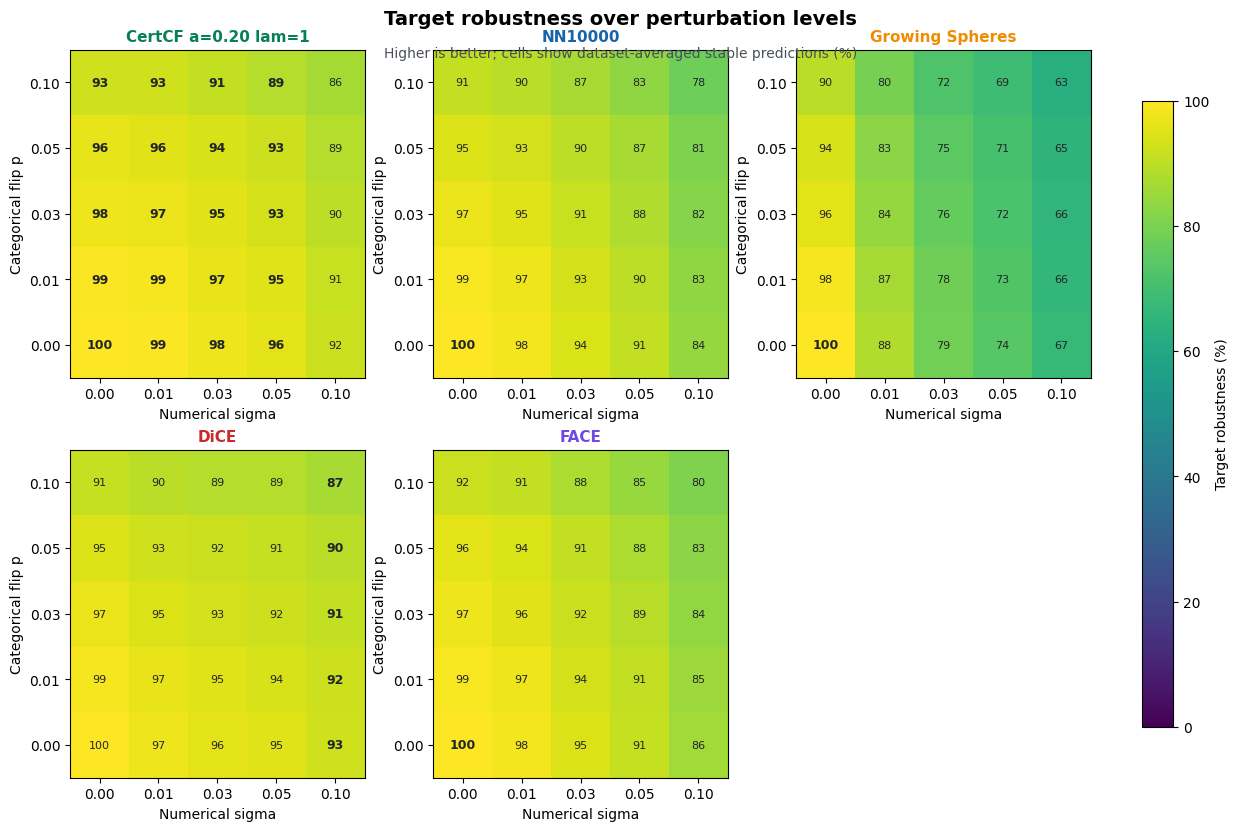

In [12]:
import math


def plot_robustness_heatmaps(
    grid_df: pd.DataFrame,
    sigma_grid: list[float] = ROBUSTNESS_SIGMA_GRID,
    categorical_flip_grid: list[float] = ROBUSTNESS_CAT_FLIP_GRID,
):
    methods = [method for method in METHOD_ORDER if method in set(grid_df['method_label'].astype(str))]
    ncols = 3
    nrows = math.ceil(len(methods) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.1 * ncols, 3.5 * nrows + 1), squeeze=False, constrained_layout=True)

    best_by_cell = (
        grid_df
        .groupby(['numerical_sigma', 'categorical_flip_p'], observed=True)['dataset_avg_target_robustness_pct']
        .max()
        .to_dict()
    )

    image = None
    for ax, method_label in zip(axes.ravel(), methods):
        method_df = grid_df[grid_df['method_label'].astype(str).eq(method_label)]
        heat = (
            method_df
            .pivot(index='categorical_flip_p', columns='numerical_sigma', values='dataset_avg_target_robustness_pct')
            .reindex(index=categorical_flip_grid, columns=sigma_grid)
        )
        values = heat.to_numpy(dtype=float)
        image = ax.imshow(values, origin='lower', vmin=0.0, vmax=100.0, cmap='viridis', aspect='auto')
        ax.set_title(method_label, color=PALETTE.get(method_label, '#212529'), fontsize=11, fontweight='bold')
        ax.set_xticks(np.arange(len(sigma_grid)))
        ax.set_xticklabels([f'{v:.2f}' for v in sigma_grid])
        ax.set_yticks(np.arange(len(categorical_flip_grid)))
        ax.set_yticklabels([f'{v:.2f}' for v in categorical_flip_grid])
        ax.set_xlabel('Numerical sigma')
        ax.set_ylabel('Categorical flip p')

        for row_idx in range(values.shape[0]):
            for col_idx in range(values.shape[1]):
                value = values[row_idx, col_idx]
                if np.isfinite(value):
                    sigma = sigma_grid[col_idx]
                    categorical_flip_p = categorical_flip_grid[row_idx]
                    best_value = best_by_cell.get((sigma, categorical_flip_p), np.nan)
                    is_best = np.isfinite(best_value) and np.isclose(value, best_value)
                    ax.text(
                        col_idx,
                        row_idx,
                        f'{value:.0f}',
                        ha='center',
                        va='center',
                        fontsize=9 if is_best else 8,
                        fontweight='bold' if is_best else 'normal',
                        color='white' if value < 62 else '#212529',
                    )

    for ax in axes.ravel()[len(methods):]:
        ax.axis('off')

    fig.suptitle('Target robustness over perturbation levels', fontsize=14, fontweight='bold', y=1.02)
    fig.text(0.5, 0.965, 'Higher is better; cells show dataset-averaged stable predictions (%)', ha='center', va='center', fontsize=10, color='#495057')
    if image is not None:
        fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.86, label='Target robustness (%)')
    return fig, axes


plot_robustness_heatmaps(ROBUSTNESS_GRID_AVERAGED_DF);


## Privacy

,method_label,n_datasets,total_success,total_training_hits,dataset_avg_train_hit_rate_pct,dataset_std_train_hit_rate_pct,dataset_avg_nearest_train_l1
0,CertCF a=0.20 lam=1,7,4773,0,0.0,0.0,0.6324
1,NN10000,7,4773,4773,100.0,0.0,0.0000
2,Growing Spheres,7,4763,0,0.0,0.0,5.0899
3,DiCE,7,4463,0,0.0,0.0,5.8641
4,FACE,7,4683,4683,100.0,0.0,0.0000


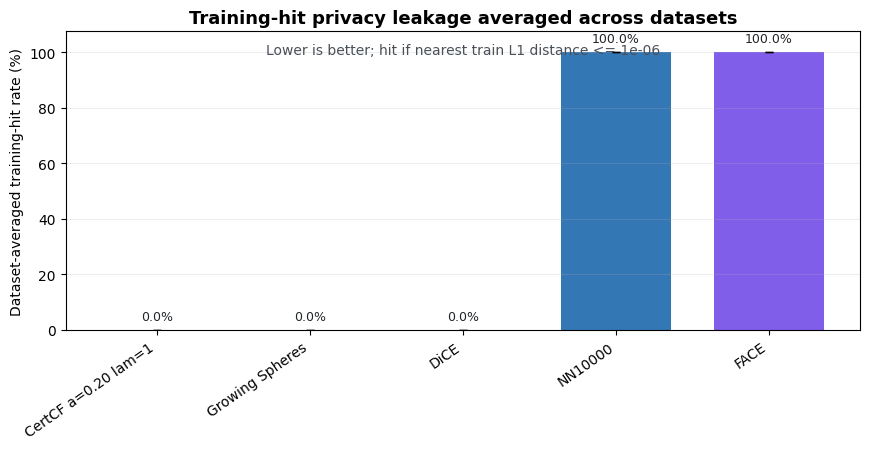

In [13]:
from sklearn.neighbors import NearestNeighbors
from counterfactuals.benchmarks import create_default_registries

PRIVACY_HIT_L1_TOL = 1e-6


def load_privacy_train_by_dataset(dataset_order: list[str]) -> dict[str, np.ndarray]:
    registries = create_default_registries()
    train_by_dataset = {}
    for dataset_name in dataset_order:
        dataset = registries['dataset'].create(dataset_name, data_dir=str(ROOT / 'data'))
        dataset.load()
        x_train, _ = dataset.get_train()
        train_by_dataset[dataset_name] = np.asarray(x_train, dtype=np.float32)
    return train_by_dataset


def compute_training_hit_rate(df: pd.DataFrame, tol: float = PRIVACY_HIT_L1_TOL) -> tuple[pd.DataFrame, pd.DataFrame]:
    train_by_dataset = load_privacy_train_by_dataset(DATASET_ORDER)
    rows = []

    for dataset_name in DATASET_ORDER:
        x_train = train_by_dataset[dataset_name]
        cf_cols = [f'x_cf_{idx}' for idx in range(x_train.shape[1])]
        ds = df[df['dataset'].astype(str).eq(dataset_name)]
        if ds.empty or not set(cf_cols).issubset(ds.columns):
            continue

        nn = NearestNeighbors(n_neighbors=1, metric='manhattan', n_jobs=-1)
        nn.fit(x_train)

        for method_label in METHOD_ORDER:
            method_df = ds[
                ds['method_label'].astype(str).eq(method_label)
                & ds['success'].astype(bool)
            ]
            if method_df.empty:
                continue

            x_cf = method_df[cf_cols].to_numpy(dtype=np.float32)
            finite = np.isfinite(x_cf).all(axis=1)
            if not finite.any():
                continue
            x_cf = x_cf[finite]

            distances, _ = nn.kneighbors(x_cf, return_distance=True)
            min_l1 = distances[:, 0]
            hits = min_l1 <= tol

            rows.append({
                'dataset': dataset_name,
                'method_label': method_label,
                'n_success': int(len(x_cf)),
                'n_training_hits': int(hits.sum()),
                'train_hit_rate_pct': 100.0 * float(hits.mean()),
                'mean_nearest_train_l1': float(np.mean(min_l1)),
            })

    by_dataset = pd.DataFrame(rows)
    averaged = (
        by_dataset
        .groupby('method_label', observed=True)
        .agg(
            n_datasets=('dataset', 'nunique'),
            total_success=('n_success', 'sum'),
            total_training_hits=('n_training_hits', 'sum'),
            dataset_avg_train_hit_rate_pct=('train_hit_rate_pct', 'mean'),
            dataset_std_train_hit_rate_pct=('train_hit_rate_pct', 'std'),
            dataset_avg_nearest_train_l1=('mean_nearest_train_l1', 'mean'),
        )
        .reset_index()
    )
    averaged['method_label'] = pd.Categorical(averaged['method_label'], METHOD_ORDER, ordered=True)
    averaged = averaged.sort_values('method_label', ignore_index=True)
    return by_dataset, averaged


def plot_training_hit_rate_barplot(summary_df: pd.DataFrame):
    plot_df = summary_df.sort_values('dataset_avg_train_hit_rate_pct', ascending=True, ignore_index=True)
    labels = plot_df['method_label'].astype(str).tolist()
    x = np.arange(len(labels))
    colors = [PALETTE.get(label, '#868E96') for label in labels]
    y = plot_df['dataset_avg_train_hit_rate_pct'].to_numpy(dtype=float)
    yerr = plot_df['dataset_std_train_hit_rate_pct'].fillna(0.0).to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(8.8, 4.6))
    ax.bar(x, y, yerr=yerr, color=colors, alpha=0.88, capsize=3, width=0.72)
    label_offset = max(1.0, 0.025 * max(1.0, float(np.nanmax(y + yerr))))
    for x_pos, value, err in zip(x, y, yerr):
        ax.text(
            x_pos,
            value + err + label_offset,
            f'{value:.1f}%',
            ha='center',
            va='bottom',
            fontsize=9,
            color='#212529',
        )
    ax.set_title('Training-hit privacy leakage averaged across datasets', fontsize=13, fontweight='bold')
    ax.text(
        0.5,
        0.96,
        f'Lower is better; hit if nearest train L1 distance <= {PRIVACY_HIT_L1_TOL:g}',
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=10,
        color='#495057',
    )
    ax.set_ylabel('Dataset-averaged training-hit rate (%)')
    ax.set_ylim(0.0, max(5.0, float(np.nanmax(y + yerr)) + 3.0 * label_offset))
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha='right')
    ax.grid(True, axis='y', alpha=0.22)
    fig.tight_layout()
    return fig, ax


PRIVACY_BY_DATASET_DF, PRIVACY_AVERAGED_DF = compute_training_hit_rate(BENCHMARK_DF)
display(PRIVACY_AVERAGED_DF.round(4))
plot_training_hit_rate_barplot(PRIVACY_AVERAGED_DF);

## Privacy: k-Neighborhood Entropy

,method_label,n_datasets,total_success,dataset_avg_k_neighbor_entropy,dataset_std_k_neighbor_entropy,dataset_avg_normalized_k_neighbor_entropy,dataset_std_normalized_k_neighbor_entropy
0,CertCF a=0.20 lam=1,7,4773,0.5157,0.1276,0.7440,0.1841
1,NN10000,7,4773,0.5135,0.1542,0.7408,0.2225
2,Growing Spheres,7,4763,0.4255,0.1874,0.6139,0.2704
3,DiCE,7,4463,0.4672,0.1311,0.6741,0.1891
4,FACE,7,4683,0.5017,0.1622,0.7238,0.2340


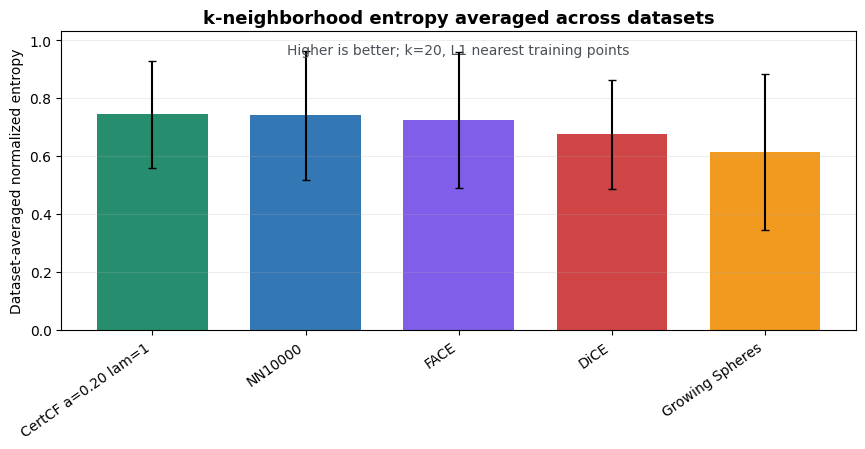

In [14]:
PRIVACY_ENTROPY_K = 20


def load_privacy_train_xy_by_dataset(dataset_order: list[str]) -> dict[str, tuple[np.ndarray, np.ndarray]]:
    registries = create_default_registries()
    train_by_dataset = {}
    for dataset_name in dataset_order:
        dataset = registries['dataset'].create(dataset_name, data_dir=str(ROOT / 'data'))
        dataset.load()
        x_train, y_train = dataset.get_train()
        train_by_dataset[dataset_name] = (
            np.asarray(x_train, dtype=np.float32),
            np.asarray(y_train),
        )
    return train_by_dataset


def entropy_from_encoded_labels(labels: np.ndarray, n_classes: int) -> float:
    counts = np.bincount(labels, minlength=n_classes).astype(float)
    probs = counts[counts > 0.0] / counts.sum()
    return float(-np.sum(probs * np.log(probs)))


def compute_k_neighborhood_entropy(
    df: pd.DataFrame,
    k: int = PRIVACY_ENTROPY_K,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    train_by_dataset = load_privacy_train_xy_by_dataset(DATASET_ORDER)
    rows = []

    for dataset_name in DATASET_ORDER:
        x_train, y_train = train_by_dataset[dataset_name]
        classes, y_train_encoded = np.unique(y_train, return_inverse=True)
        n_classes = len(classes)
        k_eff = min(int(k), len(x_train))
        cf_cols = [f'x_cf_{idx}' for idx in range(x_train.shape[1])]
        ds = df[df['dataset'].astype(str).eq(dataset_name)]
        if ds.empty or not set(cf_cols).issubset(ds.columns) or k_eff <= 0:
            continue

        nn = NearestNeighbors(n_neighbors=k_eff, metric='manhattan', n_jobs=-1)
        nn.fit(x_train)

        for method_label in METHOD_ORDER:
            method_df = ds[
                ds['method_label'].astype(str).eq(method_label)
                & ds['success'].astype(bool)
            ]
            if method_df.empty:
                continue

            x_cf = method_df[cf_cols].to_numpy(dtype=np.float32)
            finite = np.isfinite(x_cf).all(axis=1)
            if not finite.any():
                continue
            x_cf = x_cf[finite]

            neighbor_idx = nn.kneighbors(x_cf, return_distance=False)
            neighbor_labels = y_train_encoded[neighbor_idx]
            entropy = np.array([
                entropy_from_encoded_labels(labels, n_classes)
                for labels in neighbor_labels
            ])
            normalized_entropy = entropy / np.log(n_classes) if n_classes > 1 else np.zeros_like(entropy)

            rows.append({
                'dataset': dataset_name,
                'method_label': method_label,
                'k': int(k_eff),
                'n_success': int(len(x_cf)),
                'mean_k_neighbor_entropy': float(np.mean(entropy)),
                'mean_normalized_k_neighbor_entropy': float(np.mean(normalized_entropy)),
            })

    by_dataset = pd.DataFrame(rows)
    averaged = (
        by_dataset
        .groupby('method_label', observed=True)
        .agg(
            n_datasets=('dataset', 'nunique'),
            total_success=('n_success', 'sum'),
            dataset_avg_k_neighbor_entropy=('mean_k_neighbor_entropy', 'mean'),
            dataset_std_k_neighbor_entropy=('mean_k_neighbor_entropy', 'std'),
            dataset_avg_normalized_k_neighbor_entropy=('mean_normalized_k_neighbor_entropy', 'mean'),
            dataset_std_normalized_k_neighbor_entropy=('mean_normalized_k_neighbor_entropy', 'std'),
        )
        .reset_index()
    )
    averaged['method_label'] = pd.Categorical(averaged['method_label'], METHOD_ORDER, ordered=True)
    averaged = averaged.sort_values('method_label', ignore_index=True)
    return by_dataset, averaged


def plot_k_neighborhood_entropy_barplot(summary_df: pd.DataFrame):
    plot_df = summary_df.sort_values('dataset_avg_normalized_k_neighbor_entropy', ascending=False, ignore_index=True)
    labels = plot_df['method_label'].astype(str).tolist()
    x = np.arange(len(labels))
    colors = [PALETTE.get(label, '#868E96') for label in labels]
    y = plot_df['dataset_avg_normalized_k_neighbor_entropy'].to_numpy(dtype=float)
    yerr = plot_df['dataset_std_normalized_k_neighbor_entropy'].fillna(0.0).to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(8.8, 4.6))
    ax.bar(x, y, yerr=yerr, color=colors, alpha=0.88, capsize=3, width=0.72)
    ax.set_title('k-neighborhood entropy averaged across datasets', fontsize=13, fontweight='bold')
    ax.text(
        0.5,
        0.96,
        f'Higher is better; k={PRIVACY_ENTROPY_K}, L1 nearest training points',
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=10,
        color='#495057',
    )
    ax.set_ylabel('Dataset-averaged normalized entropy')
    ax.set_ylim(0.0, 1.03)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha='right')
    ax.grid(True, axis='y', alpha=0.22)
    fig.tight_layout()
    return fig, ax


PRIVACY_ENTROPY_BY_DATASET_DF, PRIVACY_ENTROPY_AVERAGED_DF = compute_k_neighborhood_entropy(BENCHMARK_DF)
display(PRIVACY_ENTROPY_AVERAGED_DF.round(4))
plot_k_neighborhood_entropy_barplot(PRIVACY_ENTROPY_AVERAGED_DF);

## Privacy/Plausibility: Same-Class Closest-NN Distance Calibration

For each dataset and class, use the leave-one-out training same-class closest-neighbor L1 distances as the reference distribution. Each counterfactual is scored by its closest same-class training distance and by the percentile of that distance inside the real-data distribution.


In [15]:
SAME_CLASS_NN_LOW_Q = 0.05
SAME_CLASS_NN_LOWER_90_Q = 0.90
SAME_CLASS_NN_HIGH_Q = 0.95


def training_same_class_closest_nn_distance_distributions(
    x_train: np.ndarray,
    y_train: np.ndarray,
) -> dict[int, np.ndarray]:
    y_train = np.asarray(y_train, dtype=int).reshape(-1)
    distributions = {}
    for label in np.unique(y_train):
        class_x = x_train[y_train == int(label)]
        if len(class_x) <= 1:
            continue
        nn = NearestNeighbors(n_neighbors=2, metric='manhattan', n_jobs=-1)
        nn.fit(class_x)
        distances, _ = nn.kneighbors(class_x, return_distance=True)
        distributions[int(label)] = np.sort(distances[:, 1].astype(float))
    return distributions


def same_class_closest_nn_distances_and_percentiles(
    x_cf: np.ndarray,
    labels: np.ndarray,
    x_train: np.ndarray,
    y_train: np.ndarray,
    reference_distributions: dict[int, np.ndarray],
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    labels = np.asarray(labels, dtype=int).reshape(-1)
    y_train = np.asarray(y_train, dtype=int).reshape(-1)
    nn_l1 = np.full(len(x_cf), np.nan, dtype=float)
    percentile = np.full(len(x_cf), np.nan, dtype=float)
    valid = np.zeros(len(x_cf), dtype=bool)

    for label in np.unique(labels):
        train_mask = y_train == int(label)
        cf_mask = labels == int(label)
        reference = reference_distributions.get(int(label))
        if reference is None or train_mask.sum() < 1 or not cf_mask.any():
            continue

        cf_indices = np.flatnonzero(cf_mask)
        nn = NearestNeighbors(n_neighbors=1, metric='manhattan', n_jobs=-1)
        nn.fit(x_train[train_mask])
        distances, _ = nn.kneighbors(x_cf[cf_mask], return_distance=True)
        d = distances[:, 0].astype(float)
        nn_l1[cf_indices] = d
        percentile[cf_indices] = np.searchsorted(reference, d, side='right') / len(reference)
        valid[cf_indices] = True

    return nn_l1, percentile, valid


def compute_same_class_nn_distance_calibration(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_by_dataset = load_privacy_train_xy_by_dataset(DATASET_ORDER)
    train_value_frames = []
    value_frames = []
    rows = []

    for dataset_name in DATASET_ORDER:
        x_train, y_train = train_by_dataset[dataset_name]
        reference_distributions = training_same_class_closest_nn_distance_distributions(x_train, y_train)
        if not reference_distributions:
            continue

        for label, distances in reference_distributions.items():
            train_percentile = np.searchsorted(distances, distances, side='right') / len(distances)
            train_value_frames.append(pd.DataFrame({
                'dataset': dataset_name,
                'method_label': 'Train data',
                'class_label': int(label),
                'same_class_nn_l1': distances,
                'log1p_same_class_nn_l1': np.log1p(distances),
                'same_class_nn_percentile': train_percentile,
            }))

        cf_cols = [f'x_cf_{idx}' for idx in range(x_train.shape[1])]
        ds = df[df['dataset'].astype(str).eq(dataset_name)]
        if ds.empty or not set(cf_cols).issubset(ds.columns):
            continue

        for method_label in METHOD_ORDER:
            method_df = ds[
                ds['method_label'].astype(str).eq(method_label)
                & ds['success'].astype(bool)
            ]
            if method_df.empty:
                continue

            x_cf = method_df[cf_cols].to_numpy(dtype=np.float32)
            labels = method_df['y_cf'].where(method_df['y_cf'].notna(), method_df['target_class']).to_numpy(dtype=int)
            finite = np.isfinite(x_cf).all(axis=1)
            if not finite.any():
                continue

            x_cf = x_cf[finite]
            labels = labels[finite]
            query_idx = method_df['query_idx'].to_numpy()[finite] if 'query_idx' in method_df.columns else np.arange(len(x_cf))
            nn_l1, percentile, valid = same_class_closest_nn_distances_and_percentiles(
                x_cf=x_cf,
                labels=labels,
                x_train=x_train,
                y_train=y_train,
                reference_distributions=reference_distributions,
            )
            if not valid.any():
                continue

            nn_l1 = nn_l1[valid]
            percentile = percentile[valid]
            query_idx = query_idx[valid]
            lower_tail = percentile <= SAME_CLASS_NN_LOW_Q
            lower_90 = percentile <= SAME_CLASS_NN_LOWER_90_Q
            upper_tail = percentile >= SAME_CLASS_NN_HIGH_Q
            central = ~(lower_tail | upper_tail)

            log1p_nn_l1 = np.log1p(nn_l1)
            value_frames.append(pd.DataFrame({
                'dataset': dataset_name,
                'method_label': method_label,
                'query_idx': query_idx,
                'same_class_nn_l1': nn_l1,
                'log1p_same_class_nn_l1': log1p_nn_l1,
                'same_class_nn_percentile': percentile,
                'lower_tail': lower_tail,
                'lower_90': lower_90,
                'upper_tail': upper_tail,
                'central_90': central,
            }))
            rows.append({
                'dataset': dataset_name,
                'method_label': method_label,
                'n_success': int(len(nn_l1)),
                'mean_same_class_nn_l1': float(np.mean(nn_l1)),
                'median_same_class_nn_l1': float(np.median(nn_l1)),
                'mean_log1p_same_class_nn_l1': float(np.mean(log1p_nn_l1)),
                'median_log1p_same_class_nn_l1': float(np.median(log1p_nn_l1)),
                'median_same_class_nn_percentile': float(np.median(percentile)),
                'mean_same_class_nn_percentile': float(np.mean(percentile)),
                'lower_tail_pct': 100.0 * float(lower_tail.mean()),
                'lower_90_pct': 100.0 * float(lower_90.mean()),
                'upper_tail_pct': 100.0 * float(upper_tail.mean()),
                'central_90_pct': 100.0 * float(central.mean()),
            })

    train_values = pd.concat(train_value_frames, ignore_index=True) if train_value_frames else pd.DataFrame()
    values = pd.concat(value_frames, ignore_index=True) if value_frames else pd.DataFrame()
    by_dataset = pd.DataFrame(rows)
    averaged = (
        by_dataset
        .groupby('method_label', observed=True)
        .agg(
            n_datasets=('dataset', 'nunique'),
            total_success=('n_success', 'sum'),
            dataset_avg_same_class_nn_l1=('mean_same_class_nn_l1', 'mean'),
            dataset_std_same_class_nn_l1=('mean_same_class_nn_l1', 'std'),
            dataset_avg_median_same_class_nn_l1=('median_same_class_nn_l1', 'mean'),
            dataset_std_median_same_class_nn_l1=('median_same_class_nn_l1', 'std'),
            dataset_avg_log1p_same_class_nn_l1=('mean_log1p_same_class_nn_l1', 'mean'),
            dataset_std_log1p_same_class_nn_l1=('mean_log1p_same_class_nn_l1', 'std'),
            dataset_avg_median_log1p_same_class_nn_l1=('median_log1p_same_class_nn_l1', 'mean'),
            dataset_std_median_log1p_same_class_nn_l1=('median_log1p_same_class_nn_l1', 'std'),
            dataset_avg_same_class_nn_percentile=('mean_same_class_nn_percentile', 'mean'),
            dataset_std_same_class_nn_percentile=('mean_same_class_nn_percentile', 'std'),
            dataset_avg_lower_tail_pct=('lower_tail_pct', 'mean'),
            dataset_std_lower_tail_pct=('lower_tail_pct', 'std'),
            dataset_avg_lower_90_pct=('lower_90_pct', 'mean'),
            dataset_std_lower_90_pct=('lower_90_pct', 'std'),
            dataset_avg_upper_tail_pct=('upper_tail_pct', 'mean'),
            dataset_std_upper_tail_pct=('upper_tail_pct', 'std'),
            dataset_avg_central_90_pct=('central_90_pct', 'mean'),
            dataset_std_central_90_pct=('central_90_pct', 'std'),
        )
        .reset_index()
    )
    averaged['method_label'] = pd.Categorical(averaged['method_label'], METHOD_ORDER, ordered=True)
    averaged = averaged.sort_values('method_label', ignore_index=True)
    return train_values, values, by_dataset, averaged


(
    SAME_CLASS_NN_TRAIN_DISTANCE_VALUES_DF,
    SAME_CLASS_NN_DISTANCE_VALUES_DF,
    SAME_CLASS_NN_DISTANCE_BY_DATASET_DF,
    SAME_CLASS_NN_DISTANCE_AVERAGED_DF,
) = compute_same_class_nn_distance_calibration(BENCHMARK_DF)
display(SAME_CLASS_NN_DISTANCE_AVERAGED_DF.round(4))


,method_label,n_datasets,total_success,dataset_avg_same_class_nn_l1,dataset_std_same_class_nn_l1,dataset_avg_median_same_class_nn_l1,dataset_std_median_same_class_nn_l1,dataset_avg_log1p_same_class_nn_l1,dataset_std_log1p_same_class_nn_l1,dataset_avg_median_log1p_same_class_nn_l1,dataset_std_median_log1p_same_class_nn_l1,dataset_avg_same_class_nn_percentile,dataset_std_same_class_nn_percentile,dataset_avg_lower_tail_pct,dataset_std_lower_tail_pct,dataset_avg_lower_90_pct,dataset_std_lower_90_pct,dataset_avg_upper_tail_pct,dataset_std_upper_tail_pct,dataset_avg_central_90_pct,dataset_std_central_90_pct
0,CertCF a=0.20 lam=1,7,4773,1.1430,1.0019,0.6795,0.6772,0.5832,0.4150,0.4577,0.3658,0.1954,0.1720,37.7714,39.4581,99.5094,0.5119,0.2000,0.3830,62.0286,39.5659
1,NN10000,7,4773,0.7919,0.7840,0.0000,0.0000,0.3077,0.2387,0.0000,0.0000,0.1827,0.1418,52.7306,38.2116,98.5566,1.0794,0.6601,0.5411,46.6093,37.8860
2,Growing Spheres,7,4763,6.0926,6.1427,5.6279,5.7540,1.5309,0.9660,1.5163,0.9888,0.7139,0.0747,0.6886,0.8434,69.6065,14.1597,18.9908,9.9690,80.3206,10.1832
3,DiCE,7,4463,6.6157,5.3734,6.3055,5.3594,1.7212,0.8117,1.7163,0.8445,0.8241,0.0845,0.3405,0.8530,48.8873,16.8020,34.9592,13.2379,64.7003,12.9386
4,FACE,7,4683,0.5687,0.6246,0.0000,0.0000,0.2414,0.2017,0.0000,0.0000,0.1567,0.1530,55.0816,39.8471,99.2041,1.0611,0.2212,0.4122,44.6972,39.5693


### Same-Class Closest-NN Distance KDEs

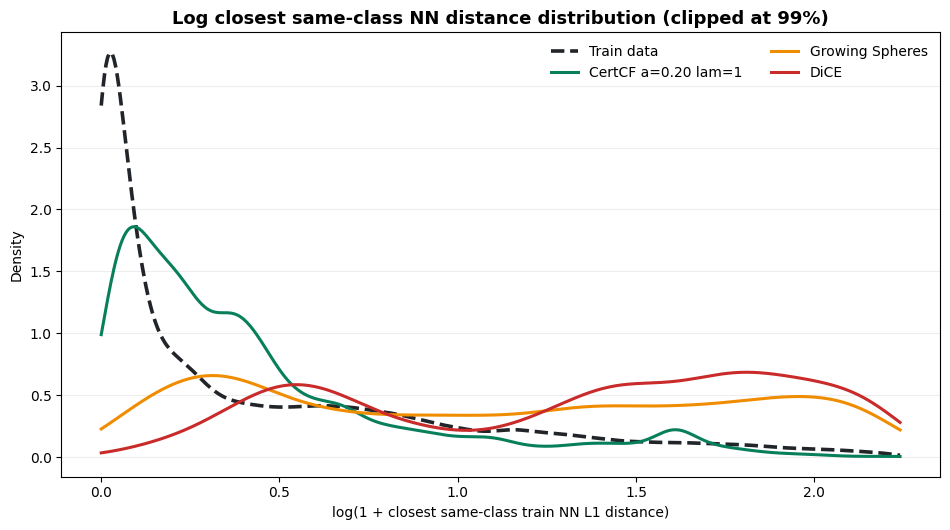

In [24]:
def gaussian_kde_1d(values: np.ndarray, grid: np.ndarray, bandwidth: float | None = None) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) < 2:
        return np.zeros_like(grid, dtype=float)

    if bandwidth is None:
        std = float(np.std(values, ddof=1))
        q25, q75 = np.quantile(values, [0.25, 0.75])
        iqr_scale = float((q75 - q25) / 1.349) if q75 > q25 else std
        scale = min(std, iqr_scale) if iqr_scale > 0 else std
        bandwidth = 0.9 * scale * (len(values) ** (-1 / 5)) if scale > 0 else 0.0
    if not np.isfinite(bandwidth) or bandwidth <= 0:
        span = float(np.ptp(values))
        bandwidth = span / 100 if span > 0 else 1e-6

    z = (grid[:, None] - values[None, :]) / bandwidth
    return np.exp(-0.5 * z ** 2).sum(axis=1) / (len(values) * bandwidth * np.sqrt(2 * np.pi))


def plot_same_class_closest_nn_distance_kde(
    values_df: pd.DataFrame,
    value_col: str = 'log1p_same_class_nn_l1',
    method_order: list[str] | None = None,
    reference_df: pd.DataFrame | None = None,
    max_quantile: float = 0.99,
):
    method_order = method_order or METHOD_ORDER
    plot_df = values_df[
        np.isfinite(values_df[value_col])
        & values_df['method_label'].astype(str).isin(method_order)
    ].copy()
    if plot_df.empty:
        raise ValueError('No closest same-class NN distance rows available to plot.')

    if reference_df is not None and value_col in reference_df.columns:
        reference_plot_df = reference_df[np.isfinite(reference_df[value_col])].copy()
    else:
        reference_plot_df = pd.DataFrame()

    if value_col == 'same_class_nn_percentile':
        x_min, x_max = 0.0, 1.0
        xlabel = 'Closest same-class train NN distance percentile'
        title = 'Closest same-class NN distance calibration'
    elif value_col == 'log1p_same_class_nn_l1':
        x_min = 0.0
        x_max_source = pd.concat([plot_df[[value_col]], reference_plot_df[[value_col]]], ignore_index=True) if not reference_plot_df.empty else plot_df[[value_col]]
        x_max = float(x_max_source[value_col].quantile(max_quantile))
        plot_df = plot_df[plot_df[value_col].le(x_max)].copy()
        reference_plot_df = reference_plot_df[reference_plot_df[value_col].le(x_max)].copy()
        xlabel = 'log(1 + closest same-class train NN L1 distance)'
        title = f'Log closest same-class NN distance distribution (clipped at {max_quantile:.0%})'
    else:
        x_min = 0.0
        x_max_source = pd.concat([plot_df[[value_col]], reference_plot_df[[value_col]]], ignore_index=True) if not reference_plot_df.empty else plot_df[[value_col]]
        x_max = float(x_max_source[value_col].quantile(max_quantile))
        plot_df = plot_df[plot_df[value_col].le(x_max)].copy()
        reference_plot_df = reference_plot_df[reference_plot_df[value_col].le(x_max)].copy()
        xlabel = 'Closest same-class train NN L1 distance'
        title = f'Closest same-class NN distance distribution (clipped at {max_quantile:.0%})'

    grid = np.linspace(x_min, x_max, 500)
    fig, ax = plt.subplots(figsize=(9.6, 5.4))
    if not reference_plot_df.empty:
        reference_values = reference_plot_df[value_col].to_numpy(dtype=float)
        reference_values = reference_values[np.isfinite(reference_values)]
        if len(reference_values) >= 2:
            ax.plot(
                grid,
                gaussian_kde_1d(reference_values, grid),
                color='#212529',
                linewidth=2.6,
                linestyle='--',
                label='Train data',
            )

    for method_label in method_order:
        values = plot_df.loc[plot_df['method_label'].astype(str).eq(method_label), value_col].to_numpy(dtype=float)
        values = values[np.isfinite(values)]
        if len(values) < 2:
            continue
        color = PALETTE.get(method_label, '#868E96')
        ax.plot(grid, gaussian_kde_1d(values, grid), color=color, linewidth=2.2, label=str(method_label))

    if value_col == 'same_class_nn_percentile':
        ax.axvline(SAME_CLASS_NN_LOWER_90_Q, color='#343A40', linestyle='--', linewidth=1.1, alpha=0.65)
        ax.text(SAME_CLASS_NN_LOWER_90_Q, ax.get_ylim()[1] * 0.95, '90%', ha='right', va='top', fontsize=9, color='#343A40')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.grid(True, axis='y', alpha=0.22)
    ax.legend(frameon=False, ncol=2)
    fig.tight_layout()
    return fig, ax


SAME_CLASS_NN_KDE_METHOD_ORDER = [
    PAPER_CERTCF_LABEL,
    'Growing Spheres',
    'DiCE',
]

plot_same_class_closest_nn_distance_kde(
    SAME_CLASS_NN_DISTANCE_VALUES_DF,
    value_col='log1p_same_class_nn_l1',
    method_order=SAME_CLASS_NN_KDE_METHOD_ORDER,
    reference_df=SAME_CLASS_NN_TRAIN_DISTANCE_VALUES_DF,
);


### Earth Mover Distance to Train Same-Class NN Distribution

In [25]:
from scipy.stats import wasserstein_distance


def compute_same_class_nn_emd_table(
    values_df: pd.DataFrame,
    reference_df: pd.DataFrame,
    value_col: str = 'log1p_same_class_nn_l1',
    method_order: list[str] | None = None,
    max_quantile: float = SAME_CLASS_NN_DISTANCE_MAX_QUANTILE if 'SAME_CLASS_NN_DISTANCE_MAX_QUANTILE' in globals() else 0.99,
) -> pd.DataFrame:
    method_order = method_order or SAME_CLASS_NN_KDE_METHOD_ORDER
    ref = reference_df[np.isfinite(reference_df[value_col])].copy()
    vals = values_df[
        np.isfinite(values_df[value_col])
        & values_df['method_label'].astype(str).isin(method_order)
    ].copy()
    if ref.empty or vals.empty:
        raise ValueError('Need non-empty train and method distributions to compute EMD.')

    x_max = float(pd.concat([ref[[value_col]], vals[[value_col]]], ignore_index=True)[value_col].quantile(max_quantile))
    ref_values = ref.loc[ref[value_col].le(x_max), value_col].to_numpy(dtype=float)
    rows = []

    for method_label in method_order:
        method_values = vals.loc[
            vals['method_label'].astype(str).eq(method_label)
            & vals[value_col].le(x_max),
            value_col,
        ].to_numpy(dtype=float)
        if len(method_values) < 2 or len(ref_values) < 2:
            continue
        rows.append({
            'method_label': method_label,
            'n_method': int(len(method_values)),
            'n_train_reference': int(len(ref_values)),
            'earth_movers_distance': float(wasserstein_distance(method_values, ref_values)),
            'value_col': value_col,
            'x_max_used': x_max,
        })

    out = pd.DataFrame(rows)
    out['method_label'] = pd.Categorical(out['method_label'], method_order, ordered=True)
    return out.sort_values('earth_movers_distance', ignore_index=True)


SAME_CLASS_NN_EMD_DF = compute_same_class_nn_emd_table(
    SAME_CLASS_NN_DISTANCE_VALUES_DF,
    SAME_CLASS_NN_TRAIN_DISTANCE_VALUES_DF,
    value_col='log1p_same_class_nn_l1',
    method_order=SAME_CLASS_NN_KDE_METHOD_ORDER,
)
print('Earth Mover distance on log(1 + closest same-class train NN L1); lower is closer to train distribution.')
display(SAME_CLASS_NN_EMD_DF[['method_label', 'earth_movers_distance', 'n_method', 'n_train_reference']].round(4))


Earth Mover distance on log(1 + closest same-class train NN L1); lower is closer to train distribution.


,method_label,earth_movers_distance,n_method,n_train_reference
0,CertCF a=0.20 lam=1,0.0999,4762,200368
1,Growing Spheres,0.6442,4346,200368
2,DiCE,0.8728,3932,200368


### Same-Class Relative Proximity Ratio

Compare the average closest same-class training distance of returned counterfactuals against the natural leave-one-out closest same-class distance among training points. Values near 1 mean the counterfactuals are spaced from training points similarly to real data; values below 1 mean they are unusually close to training samples.

,method_label,n_datasets,total_success,dataset_avg_relative_proximity_ratio,dataset_std_relative_proximity_ratio,dataset_avg_median_relative_proximity_ratio,dataset_std_median_relative_proximity_ratio,dataset_avg_cf_same_class_nn_l1,dataset_avg_train_same_class_nn_l1
0,CertCF a=0.20 lam=1,7,4773,0.4560,0.3054,0.5291,0.5586,1.1430,3.8123
1,NN10000,7,4773,0.3814,0.2601,0.0000,0.0000,0.7919,3.8123
2,Growing Spheres,7,4763,1.9295,0.7383,2.7712,2.0305,6.0926,3.8123
3,DiCE,7,4463,2.9459,1.6138,5.0699,4.6098,6.6157,3.8123
4,FACE,7,4683,0.3289,0.2953,0.0000,0.0000,0.5687,3.8123


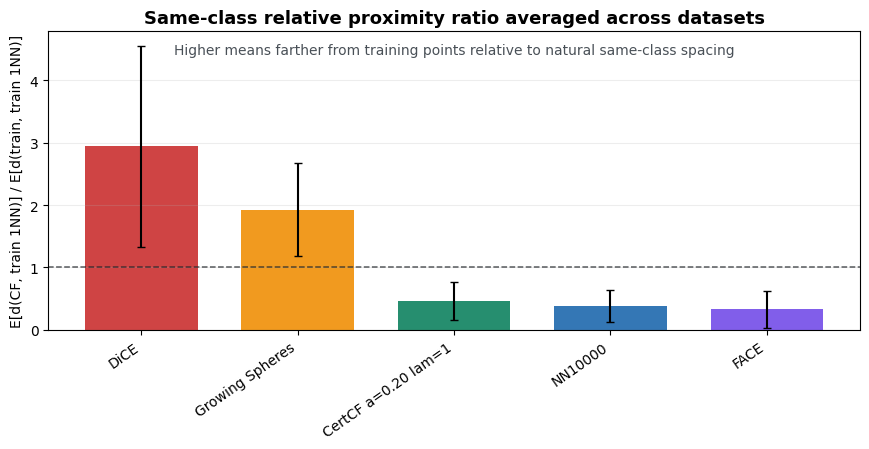

In [17]:
def compute_same_class_relative_proximity_ratio(
    by_dataset_df: pd.DataFrame,
    train_values_df: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    train_reference = (
        train_values_df
        .groupby('dataset', observed=True)
        .agg(
            train_mean_same_class_nn_l1=('same_class_nn_l1', 'mean'),
            train_median_same_class_nn_l1=('same_class_nn_l1', 'median'),
            n_train_reference=('same_class_nn_l1', 'size'),
        )
        .reset_index()
    )

    by_dataset = by_dataset_df.merge(train_reference, on='dataset', how='left')
    by_dataset['relative_proximity_ratio'] = (
        by_dataset['mean_same_class_nn_l1'] / by_dataset['train_mean_same_class_nn_l1']
    )
    by_dataset['median_relative_proximity_ratio'] = (
        by_dataset['median_same_class_nn_l1'] / by_dataset['train_median_same_class_nn_l1']
    )

    averaged = (
        by_dataset
        .groupby('method_label', observed=True)
        .agg(
            n_datasets=('dataset', 'nunique'),
            total_success=('n_success', 'sum'),
            dataset_avg_relative_proximity_ratio=('relative_proximity_ratio', 'mean'),
            dataset_std_relative_proximity_ratio=('relative_proximity_ratio', 'std'),
            dataset_avg_median_relative_proximity_ratio=('median_relative_proximity_ratio', 'mean'),
            dataset_std_median_relative_proximity_ratio=('median_relative_proximity_ratio', 'std'),
            dataset_avg_cf_same_class_nn_l1=('mean_same_class_nn_l1', 'mean'),
            dataset_avg_train_same_class_nn_l1=('train_mean_same_class_nn_l1', 'mean'),
        )
        .reset_index()
    )
    averaged['method_label'] = pd.Categorical(averaged['method_label'], METHOD_ORDER, ordered=True)
    averaged = averaged.sort_values('method_label', ignore_index=True)
    return by_dataset, averaged


def plot_relative_proximity_ratio_barplot(summary_df: pd.DataFrame):
    plot_df = summary_df.sort_values('dataset_avg_relative_proximity_ratio', ascending=False, ignore_index=True)
    labels = plot_df['method_label'].astype(str).tolist()
    x = np.arange(len(labels))
    colors = [PALETTE.get(label, '#868E96') for label in labels]
    y = plot_df['dataset_avg_relative_proximity_ratio'].to_numpy(dtype=float)
    yerr = plot_df['dataset_std_relative_proximity_ratio'].fillna(0.0).to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(8.8, 4.6))
    ax.bar(x, y, yerr=yerr, color=colors, alpha=0.88, capsize=3, width=0.72)
    ax.axhline(1.0, color='#212529', linestyle='--', linewidth=1.1, alpha=0.75)
    ax.text(
        0.5,
        0.96,
        'Higher means farther from training points relative to natural same-class spacing',
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=10,
        color='#495057',
    )
    ax.set_title('Same-class relative proximity ratio averaged across datasets', fontsize=13, fontweight='bold')
    ax.set_ylabel('E[d(CF, train 1NN)] / E[d(train, train 1NN)]')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha='right')
    ax.grid(True, axis='y', alpha=0.22)
    fig.tight_layout()
    return fig, ax


(
    SAME_CLASS_RELATIVE_PROXIMITY_BY_DATASET_DF,
    SAME_CLASS_RELATIVE_PROXIMITY_AVERAGED_DF,
) = compute_same_class_relative_proximity_ratio(
    SAME_CLASS_NN_DISTANCE_BY_DATASET_DF,
    SAME_CLASS_NN_TRAIN_DISTANCE_VALUES_DF,
)
display(SAME_CLASS_RELATIVE_PROXIMITY_AVERAGED_DF.round(4))
plot_relative_proximity_ratio_barplot(SAME_CLASS_RELATIVE_PROXIMITY_AVERAGED_DF);


### Relative Proximity Ratio on Shared Successful Queries

Shared same-class NN distance counts per dataset:


,dataset,n_shared_success_queries,n_values_CertCF a=0.20 lam=1,n_values_NN10000,n_values_Growing Spheres,n_values_DiCE,n_values_FACE
0,adult,891,1000,1000,991,902,990
1,compas,517,617,617,617,520,614
2,german_credit,85,100,100,100,88,97
3,give_me_some_credit,989,1000,1000,1000,996,992
4,heloc,885,1000,1000,1000,919,940
5,lending_club,977,1000,1000,1000,982,995
6,wisconsin_breast_cancer,54,56,56,55,56,55


Relative proximity ratio computed only on queries where every plotted method has a same-class NN distance:


,method_label,n_datasets,total_success,dataset_avg_relative_proximity_ratio,dataset_std_relative_proximity_ratio,dataset_avg_median_relative_proximity_ratio,dataset_std_median_relative_proximity_ratio,dataset_avg_cf_same_class_nn_l1,dataset_avg_train_same_class_nn_l1
0,CertCF a=0.20 lam=1,7,4398,0.4410,0.3113,0.5093,0.5453,1.0657,3.8123
1,NN10000,7,4398,0.3750,0.2631,0.0000,0.0000,0.7539,3.8123
2,Growing Spheres,7,4398,1.8589,0.7395,2.7316,2.0320,5.8742,3.8123
3,DiCE,7,4398,2.8874,1.6073,5.0336,4.5860,6.4039,3.8123
4,FACE,7,4398,0.3279,0.2974,0.0000,0.0000,0.5500,3.8123


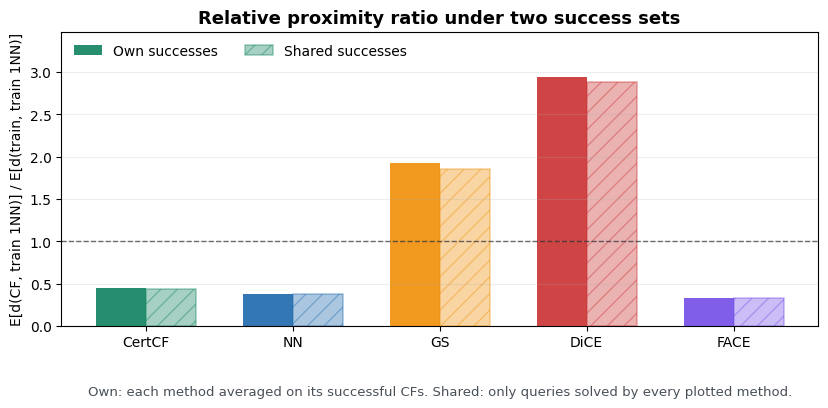

In [26]:
def compute_shared_same_class_nn_distance_by_dataset(
    values_df: pd.DataFrame,
    method_order: list[str],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    count_rows = []

    for dataset_name in DATASET_ORDER:
        ds = values_df[values_df['dataset'].astype(str).eq(dataset_name)]
        query_sets = {}
        for method_label in method_order:
            method_values = ds[ds['method_label'].astype(str).eq(method_label)]
            query_sets[method_label] = set(method_values['query_idx'].tolist())

        if not query_sets or any(len(v) == 0 for v in query_sets.values()):
            continue
        shared_query_idx = sorted(set.intersection(*query_sets.values()))
        if not shared_query_idx:
            continue

        count_rows.append({
            'dataset': dataset_name,
            'n_shared_success_queries': int(len(shared_query_idx)),
            **{f'n_values_{method_label}': len(query_sets.get(method_label, set())) for method_label in method_order},
        })

        for method_label in method_order:
            method_values = ds[
                ds['method_label'].astype(str).eq(method_label)
                & ds['query_idx'].isin(shared_query_idx)
                & ds['same_class_nn_l1'].notna()
            ].copy()
            method_values = method_values.sort_values('query_idx').drop_duplicates('query_idx', keep='first')
            distances = method_values['same_class_nn_l1'].to_numpy(dtype=float)
            distances = distances[np.isfinite(distances)]
            if len(distances) == 0:
                continue
            rows.append({
                'dataset': dataset_name,
                'method_label': method_label,
                'n_success': int(len(distances)),
                'mean_same_class_nn_l1': float(np.mean(distances)),
                'median_same_class_nn_l1': float(np.median(distances)),
            })

    by_dataset = pd.DataFrame(rows)
    counts = pd.DataFrame(count_rows)
    return by_dataset, counts


def plot_relative_proximity_own_vs_shared_success(
    own_summary_df: pd.DataFrame,
    shared_summary_df: pd.DataFrame,
    method_order: list[str],
):
    own = (
        own_summary_df.assign(method_label=lambda x: x['method_label'].astype(str))
        .set_index('method_label')
        .reindex(method_order)
    )
    shared = (
        shared_summary_df.assign(method_label=lambda x: x['method_label'].astype(str))
        .set_index('method_label')
        .reindex(method_order)
    )

    display_labels = {
        method_order[0]: 'CertCF',
        'NN10000': 'NN',
        'Growing Spheres': 'GS',
        'DiCE': 'DiCE',
        'FACE': 'FACE',
    }
    labels = [display_labels.get(label, label) for label in method_order]
    x = np.arange(len(labels), dtype=float)
    width = 0.34
    own_y = own['dataset_avg_relative_proximity_ratio'].to_numpy(dtype=float)
    shared_y = shared['dataset_avg_relative_proximity_ratio'].to_numpy(dtype=float)
    base_colors = [PALETTE.get(label, '#868E96') for label in method_order]

    fig, ax = plt.subplots(figsize=(8.8, 4.6))
    ax.bar(
        x - width / 2,
        own_y,
        width=width,
        color=base_colors,
        alpha=0.88,
        label='Own successes',
    )
    ax.bar(
        x + width / 2,
        shared_y,
        width=width,
        color=base_colors,
        alpha=0.36,
        edgecolor=base_colors,
        linewidth=1.2,
        hatch='//',
        label='Shared successes',
    )
    ax.axhline(1.0, color='#212529', linestyle='--', linewidth=1.0, alpha=0.65)

    ax.set_title('Relative proximity ratio under two success sets', fontsize=13, fontweight='bold')
    ax.set_ylabel('E[d(CF, train 1NN)] / E[d(train, train 1NN)]')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.grid(True, axis='y', alpha=0.22)
    ax.legend(frameon=False, loc='upper left', ncol=2)
    ax.text(
        0.5,
        -0.20,
        'Own: each method averaged on its successful CFs. Shared: only queries solved by every plotted method.',
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=9.5,
        color='#495057',
    )
    finite_y = np.concatenate([own_y[np.isfinite(own_y)], shared_y[np.isfinite(shared_y)]])
    if finite_y.size:
        ax.set_ylim(0.0, float(finite_y.max()) * 1.18)
    fig.subplots_adjust(bottom=0.24, top=0.88, left=0.12, right=0.98)
    return fig, ax


(
    SHARED_SAME_CLASS_NN_DISTANCE_BY_DATASET_DF,
    SHARED_RELATIVE_PROXIMITY_COUNTS_DF,
) = compute_shared_same_class_nn_distance_by_dataset(
    SAME_CLASS_NN_DISTANCE_VALUES_DF,
    METHOD_ORDER,
)
(
    SHARED_RELATIVE_PROXIMITY_BY_DATASET_DF,
    SHARED_RELATIVE_PROXIMITY_AVERAGED_DF,
) = compute_same_class_relative_proximity_ratio(
    SHARED_SAME_CLASS_NN_DISTANCE_BY_DATASET_DF,
    SAME_CLASS_NN_TRAIN_DISTANCE_VALUES_DF,
)

print('Shared same-class NN distance counts per dataset:')
display(SHARED_RELATIVE_PROXIMITY_COUNTS_DF)
print('Relative proximity ratio computed only on queries where every plotted method has a same-class NN distance:')
display(SHARED_RELATIVE_PROXIMITY_AVERAGED_DF.round(4))
plot_relative_proximity_own_vs_shared_success(
    SAME_CLASS_RELATIVE_PROXIMITY_AVERAGED_DF,
    SHARED_RELATIVE_PROXIMITY_AVERAGED_DF,
    METHOD_ORDER,
);


### Neighbor Contrast Ratio

For each counterfactual, compare the closest same-class training neighbor distance with the second-closest same-class training neighbor distance. Smaller values indicate that the counterfactual is disproportionately tied to a single training point.

,method_label,n_datasets,total_success,dataset_avg_neighbor_contrast_ratio,dataset_std_neighbor_contrast_ratio,dataset_avg_median_neighbor_contrast_ratio,dataset_std_median_neighbor_contrast_ratio,dataset_avg_first_same_class_nn_l1,dataset_avg_second_same_class_nn_l1
0,CertCF a=0.20 lam=1,7,4773,0.4871,0.1822,0.4533,0.2753,1.1430,3.6065
1,NN10000,7,4621,0.2474,0.1137,0.0000,0.0000,0.7972,3.9269
2,Growing Spheres,7,4763,0.8716,0.0497,0.9095,0.0294,6.0926,6.6869
3,DiCE,7,4463,0.9063,0.0325,0.9427,0.0168,6.6157,7.1374
4,FACE,7,4502,0.2295,0.1246,0.0000,0.0000,0.5749,3.3382


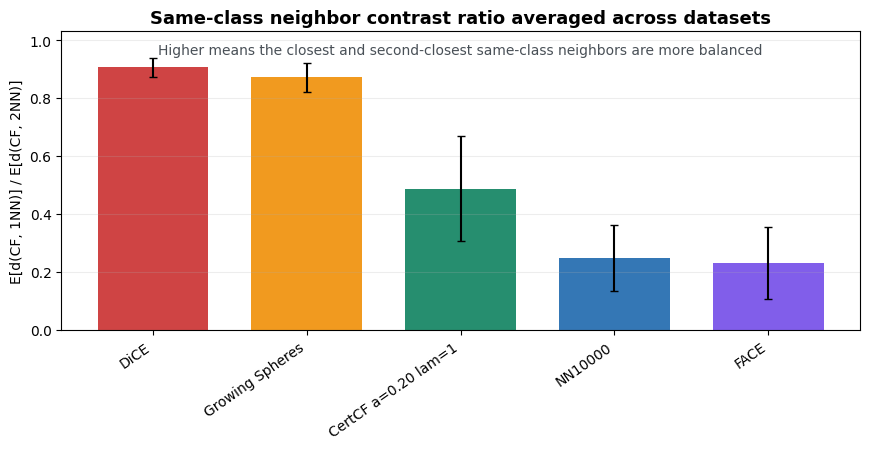

In [27]:
def same_class_first_second_nn_distances(
    x_cf: np.ndarray,
    labels: np.ndarray,
    x_train: np.ndarray,
    y_train: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    labels = np.asarray(labels, dtype=int).reshape(-1)
    y_train = np.asarray(y_train, dtype=int).reshape(-1)
    first_l1 = np.full(len(x_cf), np.nan, dtype=float)
    second_l1 = np.full(len(x_cf), np.nan, dtype=float)
    valid = np.zeros(len(x_cf), dtype=bool)

    for label in np.unique(labels):
        train_mask = y_train == int(label)
        cf_mask = labels == int(label)
        if train_mask.sum() < 2 or not cf_mask.any():
            continue

        cf_indices = np.flatnonzero(cf_mask)
        nn = NearestNeighbors(n_neighbors=2, metric='manhattan', n_jobs=-1)
        nn.fit(x_train[train_mask])
        distances, _ = nn.kneighbors(x_cf[cf_mask], return_distance=True)
        first_l1[cf_indices] = distances[:, 0].astype(float)
        second_l1[cf_indices] = distances[:, 1].astype(float)
        valid[cf_indices] = np.isfinite(first_l1[cf_indices]) & np.isfinite(second_l1[cf_indices]) & (second_l1[cf_indices] > 0)

    return first_l1, second_l1, valid


def compute_neighbor_contrast_ratio(
    df: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_by_dataset = load_privacy_train_xy_by_dataset(DATASET_ORDER)
    value_frames = []
    rows = []

    for dataset_name in DATASET_ORDER:
        x_train, y_train = train_by_dataset[dataset_name]
        cf_cols = [f'x_cf_{idx}' for idx in range(x_train.shape[1])]
        ds = df[df['dataset'].astype(str).eq(dataset_name)]
        if ds.empty or not set(cf_cols).issubset(ds.columns):
            continue

        for method_label in METHOD_ORDER:
            method_df = ds[
                ds['method_label'].astype(str).eq(method_label)
                & ds['success'].astype(bool)
            ]
            if method_df.empty:
                continue

            x_cf = method_df[cf_cols].to_numpy(dtype=np.float32)
            labels = method_df['y_cf'].where(method_df['y_cf'].notna(), method_df['target_class']).to_numpy(dtype=int)
            finite = np.isfinite(x_cf).all(axis=1)
            if not finite.any():
                continue

            x_cf = x_cf[finite]
            labels = labels[finite]
            query_idx = method_df['query_idx'].to_numpy()[finite] if 'query_idx' in method_df.columns else np.arange(len(x_cf))
            first_l1, second_l1, valid = same_class_first_second_nn_distances(
                x_cf=x_cf,
                labels=labels,
                x_train=x_train,
                y_train=y_train,
            )
            if not valid.any():
                continue

            query_idx = query_idx[valid]
            first_l1 = first_l1[valid]
            second_l1 = second_l1[valid]
            contrast_ratio = first_l1 / second_l1

            value_frames.append(pd.DataFrame({
                'dataset': dataset_name,
                'method_label': method_label,
                'query_idx': query_idx,
                'same_class_first_nn_l1': first_l1,
                'same_class_second_nn_l1': second_l1,
                'neighbor_contrast_ratio': contrast_ratio,
            }))
            rows.append({
                'dataset': dataset_name,
                'method_label': method_label,
                'n_success': int(len(contrast_ratio)),
                'mean_first_same_class_nn_l1': float(np.mean(first_l1)),
                'mean_second_same_class_nn_l1': float(np.mean(second_l1)),
                'mean_neighbor_contrast_ratio': float(np.mean(contrast_ratio)),
                'median_neighbor_contrast_ratio': float(np.median(contrast_ratio)),
            })

    values = pd.concat(value_frames, ignore_index=True) if value_frames else pd.DataFrame()
    by_dataset = pd.DataFrame(rows)
    averaged = (
        by_dataset
        .groupby('method_label', observed=True)
        .agg(
            n_datasets=('dataset', 'nunique'),
            total_success=('n_success', 'sum'),
            dataset_avg_neighbor_contrast_ratio=('mean_neighbor_contrast_ratio', 'mean'),
            dataset_std_neighbor_contrast_ratio=('mean_neighbor_contrast_ratio', 'std'),
            dataset_avg_median_neighbor_contrast_ratio=('median_neighbor_contrast_ratio', 'mean'),
            dataset_std_median_neighbor_contrast_ratio=('median_neighbor_contrast_ratio', 'std'),
            dataset_avg_first_same_class_nn_l1=('mean_first_same_class_nn_l1', 'mean'),
            dataset_avg_second_same_class_nn_l1=('mean_second_same_class_nn_l1', 'mean'),
        )
        .reset_index()
    )
    averaged['method_label'] = pd.Categorical(averaged['method_label'], METHOD_ORDER, ordered=True)
    averaged = averaged.sort_values('method_label', ignore_index=True)
    return values, by_dataset, averaged


def plot_neighbor_contrast_ratio_barplot(summary_df: pd.DataFrame):
    plot_df = summary_df.sort_values('dataset_avg_neighbor_contrast_ratio', ascending=False, ignore_index=True)
    labels = plot_df['method_label'].astype(str).tolist()
    x = np.arange(len(labels))
    colors = [PALETTE.get(label, '#868E96') for label in labels]
    y = plot_df['dataset_avg_neighbor_contrast_ratio'].to_numpy(dtype=float)
    yerr = plot_df['dataset_std_neighbor_contrast_ratio'].fillna(0.0).to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(8.8, 4.6))
    ax.bar(x, y, yerr=yerr, color=colors, alpha=0.88, capsize=3, width=0.72)
    ax.text(
        0.5,
        0.96,
        'Higher means the closest and second-closest same-class neighbors are more balanced',
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=10,
        color='#495057',
    )
    ax.set_title('Same-class neighbor contrast ratio averaged across datasets', fontsize=13, fontweight='bold')
    ax.set_ylabel('E[d(CF, 1NN)] / E[d(CF, 2NN)]')
    ax.set_ylim(0.0, min(1.03, max(0.05, float(np.nanmax(y + yerr)) * 1.15)))
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha='right')
    ax.grid(True, axis='y', alpha=0.22)
    fig.tight_layout()
    return fig, ax


(
    NEIGHBOR_CONTRAST_VALUES_DF,
    NEIGHBOR_CONTRAST_BY_DATASET_DF,
    NEIGHBOR_CONTRAST_AVERAGED_DF,
) = compute_neighbor_contrast_ratio(BENCHMARK_DF)
display(NEIGHBOR_CONTRAST_AVERAGED_DF.round(4))
plot_neighbor_contrast_ratio_barplot(NEIGHBOR_CONTRAST_AVERAGED_DF);


### Same-Class Closest-NN Distribution Distance

Compare each method with the train-data reference on the same log-distance distribution used in the KDE plot. Jensen-Shannon distance and Wasserstein distance are lower when the distributions are closer.


In [20]:
SAME_CLASS_NN_DISTANCE_GRID_SIZE = 500
SAME_CLASS_NN_DISTANCE_QUANTILE_GRID_SIZE = 1000
SAME_CLASS_NN_DISTANCE_MAX_QUANTILE = 0.99
SAME_CLASS_NN_DISTANCE_EPS = 1e-12


def normalized_density_on_grid(values: np.ndarray, grid: np.ndarray) -> np.ndarray:
    density = gaussian_kde_1d(values, grid)
    density = np.asarray(density, dtype=float)
    density = np.maximum(density, 0.0) + SAME_CLASS_NN_DISTANCE_EPS
    return density / density.sum()


def discrete_kl(p: np.ndarray, q: np.ndarray) -> float:
    p = np.asarray(p, dtype=float) + SAME_CLASS_NN_DISTANCE_EPS
    q = np.asarray(q, dtype=float) + SAME_CLASS_NN_DISTANCE_EPS
    p = p / p.sum()
    q = q / q.sum()
    return float(np.sum(p * np.log(p / q)))


def jensen_shannon_divergence(p: np.ndarray, q: np.ndarray) -> float:
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    m = 0.5 * (p + q)
    return 0.5 * discrete_kl(p, m) + 0.5 * discrete_kl(q, m)


def quantile_wasserstein_1d(a: np.ndarray, b: np.ndarray, n_grid: int = SAME_CLASS_NN_DISTANCE_QUANTILE_GRID_SIZE) -> float:
    qs = np.linspace(0.0, 1.0, int(n_grid))
    return float(np.mean(np.abs(np.quantile(a, qs) - np.quantile(b, qs))))


def compute_same_class_nn_distribution_distance_table(
    values_df: pd.DataFrame,
    reference_df: pd.DataFrame,
    value_col: str = 'log1p_same_class_nn_l1',
    method_order: list[str] | None = None,
    max_quantile: float = SAME_CLASS_NN_DISTANCE_MAX_QUANTILE,
) -> pd.DataFrame:
    method_order = method_order or SAME_CLASS_NN_KDE_METHOD_ORDER
    reference = reference_df[np.isfinite(reference_df[value_col])].copy()
    values = values_df[
        np.isfinite(values_df[value_col])
        & values_df['method_label'].astype(str).isin(method_order)
    ].copy()
    if reference.empty or values.empty:
        raise ValueError('Need non-empty train and method distance rows to compute distribution distances.')

    x_max_source = pd.concat([reference[[value_col]], values[[value_col]]], ignore_index=True)
    x_max = float(x_max_source[value_col].quantile(max_quantile))
    reference_values = reference.loc[reference[value_col].le(x_max), value_col].to_numpy(dtype=float)
    if len(reference_values) < 2:
        raise ValueError('Not enough train reference values after clipping.')

    grid = np.linspace(0.0, x_max, SAME_CLASS_NN_DISTANCE_GRID_SIZE)
    train_density = normalized_density_on_grid(reference_values, grid)
    rows = []

    for method_label in method_order:
        method_values = values.loc[
            values['method_label'].astype(str).eq(method_label)
            & values[value_col].le(x_max),
            value_col,
        ].to_numpy(dtype=float)
        if len(method_values) < 2:
            continue
        method_density = normalized_density_on_grid(method_values, grid)
        js_div = jensen_shannon_divergence(method_density, train_density)
        rows.append({
            'method_label': method_label,
            'n_method': int(len(method_values)),
            'n_train_reference': int(len(reference_values)),
            'jensen_shannon_divergence': js_div,
            'jensen_shannon_distance': float(np.sqrt(js_div)),
            'wasserstein_log1p_l1': quantile_wasserstein_1d(method_values, reference_values),
            'x_max_used': x_max,
        })

    out = pd.DataFrame(rows)
    return out.sort_values('jensen_shannon_distance', ignore_index=True)


SAME_CLASS_NN_DISTRIBUTION_DISTANCE_DF = compute_same_class_nn_distribution_distance_table(
    SAME_CLASS_NN_DISTANCE_VALUES_DF,
    SAME_CLASS_NN_TRAIN_DISTANCE_VALUES_DF,
    value_col='log1p_same_class_nn_l1',
    method_order=SAME_CLASS_NN_KDE_METHOD_ORDER,
)
display(
    SAME_CLASS_NN_DISTRIBUTION_DISTANCE_DF[
        [
            'method_label',
            'jensen_shannon_distance',
            'wasserstein_log1p_l1',
        ]
    ].round(4)
)


,method_label,jensen_shannon_distance,wasserstein_log1p_l1
0,Growing Spheres,0.3657,0.6447
1,DiCE,0.4764,0.8727


### Same-Class Closest-NN Kolmogorov-Smirnov Test

Compare each method against the train-data reference on the full `log(1 + distance)` distribution. Lower KS statistic means the empirical CDF is closer to the train reference.


In [21]:
from scipy.stats import ks_2samp


def compute_same_class_nn_ks_table(
    values_df: pd.DataFrame,
    reference_df: pd.DataFrame,
    value_col: str = 'log1p_same_class_nn_l1',
    method_order: list[str] | None = None,
) -> pd.DataFrame:
    method_order = method_order or SAME_CLASS_NN_KDE_METHOD_ORDER
    reference_values = reference_df.loc[
        np.isfinite(reference_df[value_col]),
        value_col,
    ].to_numpy(dtype=float)
    if len(reference_values) < 2:
        raise ValueError('Need at least two train reference values for KS testing.')

    rows = []
    for method_label in method_order:
        method_values = values_df.loc[
            values_df['method_label'].astype(str).eq(method_label)
            & np.isfinite(values_df[value_col]),
            value_col,
        ].to_numpy(dtype=float)
        if len(method_values) < 2:
            continue
        result = ks_2samp(method_values, reference_values, alternative='two-sided', method='auto')
        rows.append({
            'method_label': method_label,
            'n_method': int(len(method_values)),
            'n_train_reference': int(len(reference_values)),
            'ks_statistic': float(result.statistic),
            'ks_pvalue': float(result.pvalue),
        })

    return pd.DataFrame(rows).sort_values('ks_statistic', ignore_index=True)


SAME_CLASS_NN_KS_TEST_DF = compute_same_class_nn_ks_table(
    SAME_CLASS_NN_DISTANCE_VALUES_DF,
    SAME_CLASS_NN_TRAIN_DISTANCE_VALUES_DF,
    value_col='log1p_same_class_nn_l1',
    method_order=SAME_CLASS_NN_KDE_METHOD_ORDER,
)
display(SAME_CLASS_NN_KS_TEST_DF.round({'ks_statistic': 4, 'ks_pvalue': 4}))


,method_label,n_method,n_train_reference,ks_statistic,ks_pvalue
0,Growing Spheres,4763,201565,0.4262,0.0
1,DiCE,4463,201565,0.5542,0.0


## Privacy: Same-Label NN Residual Reconstruction

Attack-style privacy proxy: for each counterfactual, find the nearest training point with the same label, then train a shallow tree to predict the residual `x_cf - x_nn` from `x_cf`. Lower reconstruction error or higher residual R2 means the nearby training prototype is easier to infer.

,method_label,attack_model,n_datasets,total_success,dataset_avg_unique_same_label_nn,dataset_avg_same_label_nn_l1,dataset_avg_zero_residual_normalized_l1,dataset_std_zero_residual_normalized_l1,dataset_avg_attack_normalized_reconstruction_l1,dataset_std_attack_normalized_reconstruction_l1,dataset_avg_attack_to_zero_residual_l1_ratio,dataset_std_attack_to_zero_residual_l1_ratio,dataset_avg_residual_r2,dataset_std_residual_r2,dataset_avg_model_depth,dataset_avg_model_leaves
0,Growing Spheres,Decision tree,7,4763,531.4286,6.0926,0.7790,0.2280,0.8545,0.2937,1.0929,0.1473,0.0935,0.1652,3.0000,6.0000
1,Growing Spheres,Random forest,7,4763,531.4286,6.0926,0.7790,0.2280,0.7853,0.2808,0.9990,0.1411,0.2166,0.1744,20.0743,132.0957
2,DiCE,Decision tree,7,4463,508.0000,6.6157,1.0412,0.1659,1.0273,0.2975,0.9977,0.2794,0.2504,0.2808,3.0000,6.4286
3,DiCE,Random forest,7,4463,508.0000,6.6157,1.0412,0.1659,0.9280,0.2884,0.9025,0.2716,0.3476,0.2684,17.1586,124.0914


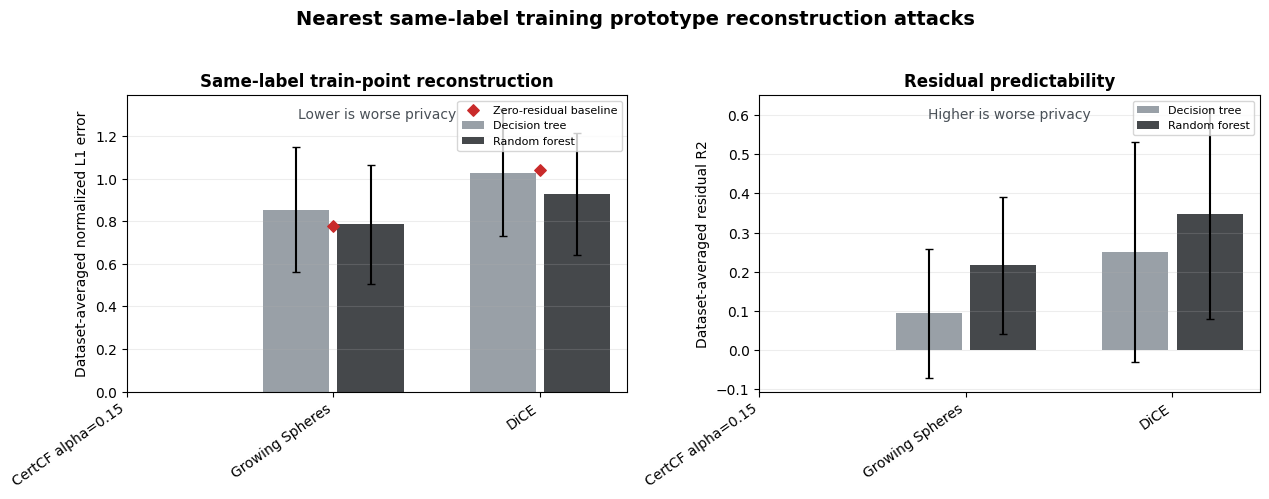

In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.tree import DecisionTreeRegressor

NN_RESIDUAL_TREE_MAX_DEPTH = 3
NN_RESIDUAL_TREE_MIN_SAMPLES_LEAF = 5
NN_RESIDUAL_TREE_TEST_SIZE = 0.30
NN_RESIDUAL_TREE_RANDOM_STATE = 0
NN_RESIDUAL_TREE_MIN_SAMPLES = 20
NN_RESIDUAL_RF_N_ESTIMATORS = 100
NN_RESIDUAL_RF_MIN_SAMPLES_LEAF = 2
NN_RESIDUAL_ATTACK_MODEL_ORDER = ['Decision tree', 'Random forest']
NN_RESIDUAL_METHOD_ORDER = [
    'CertCF alpha=0.15',
    'Growing Spheres',
    'DiCE',
]


def train_nn_l1_scale(x_train: np.ndarray, max_points: int = 5000, random_state: int = 0) -> float:
    if len(x_train) < 2:
        return 1.0
    rng = np.random.default_rng(random_state)
    if len(x_train) > max_points:
        idx = rng.choice(len(x_train), size=max_points, replace=False)
        sample = x_train[idx]
    else:
        sample = x_train
    nn = NearestNeighbors(n_neighbors=2, metric='manhattan', n_jobs=-1)
    nn.fit(sample)
    distances, _ = nn.kneighbors(sample)
    scale = float(np.nanmedian(distances[:, 1]))
    return scale if np.isfinite(scale) and scale > 0 else 1.0


def nearest_same_label_training_points(
    x_cf: np.ndarray,
    labels: np.ndarray,
    x_train: np.ndarray,
    y_train: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    labels = np.asarray(labels, dtype=int).reshape(-1)
    y_train = np.asarray(y_train, dtype=int).reshape(-1)

    x_nn = np.full_like(x_cf, np.nan, dtype=np.float32)
    nearest_l1 = np.full(len(x_cf), np.nan, dtype=float)
    nearest_idx = np.full(len(x_cf), -1, dtype=int)
    valid = np.zeros(len(x_cf), dtype=bool)

    for label in np.unique(labels):
        train_mask = y_train == int(label)
        cf_mask = labels == int(label)
        if not train_mask.any() or not cf_mask.any():
            continue

        train_indices = np.flatnonzero(train_mask)
        cf_indices = np.flatnonzero(cf_mask)
        nn = NearestNeighbors(n_neighbors=1, metric='manhattan', n_jobs=-1)
        nn.fit(x_train[train_mask])
        distances, local_idx = nn.kneighbors(x_cf[cf_mask], return_distance=True)
        global_idx = train_indices[local_idx[:, 0]]

        x_nn[cf_indices] = x_train[global_idx]
        nearest_l1[cf_indices] = distances[:, 0]
        nearest_idx[cf_indices] = global_idx
        valid[cf_indices] = True

    return x_nn, nearest_l1, nearest_idx, valid


def compute_same_label_nn_residual_reconstruction(
    df: pd.DataFrame,
    max_depth: int = NN_RESIDUAL_TREE_MAX_DEPTH,
    min_samples_leaf: int = NN_RESIDUAL_TREE_MIN_SAMPLES_LEAF,
    test_size: float = NN_RESIDUAL_TREE_TEST_SIZE,
    random_state: int = NN_RESIDUAL_TREE_RANDOM_STATE,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    train_by_dataset = load_privacy_train_xy_by_dataset(DATASET_ORDER)
    scale_by_dataset = {}
    if 'L1_SCALE_DF' in globals() and {'dataset', 'l1_scale'}.issubset(L1_SCALE_DF.columns):
        scale_by_dataset = L1_SCALE_DF.set_index('dataset')['l1_scale'].to_dict()
    rows = []

    for dataset_name in DATASET_ORDER:
        x_train, y_train = train_by_dataset[dataset_name]
        cf_cols = [f'x_cf_{idx}' for idx in range(x_train.shape[1])]
        ds = df[df['dataset'].astype(str).eq(dataset_name)]
        if ds.empty or not set(cf_cols).issubset(ds.columns):
            continue

        scale = float(scale_by_dataset.get(dataset_name, np.nan))
        if not np.isfinite(scale) or scale <= 0:
            scale = train_nn_l1_scale(x_train)

        for method_label in NN_RESIDUAL_METHOD_ORDER:
            method_df = ds[
                ds['method_label'].astype(str).eq(method_label)
                & ds['success'].astype(bool)
            ].copy()
            if len(method_df) < NN_RESIDUAL_TREE_MIN_SAMPLES:
                continue

            x_cf = method_df[cf_cols].to_numpy(dtype=np.float32)
            labels = method_df['y_cf'].where(method_df['y_cf'].notna(), method_df['target_class']).to_numpy(dtype=int)
            finite = np.isfinite(x_cf).all(axis=1)
            if not finite.any():
                continue

            x_cf = x_cf[finite]
            labels = labels[finite]
            x_nn, nearest_l1, nearest_idx, valid_same_label = nearest_same_label_training_points(
                x_cf=x_cf,
                labels=labels,
                x_train=x_train,
                y_train=y_train,
            )
            if valid_same_label.sum() < NN_RESIDUAL_TREE_MIN_SAMPLES:
                continue

            x_cf = x_cf[valid_same_label]
            x_nn = x_nn[valid_same_label]
            nearest_l1 = nearest_l1[valid_same_label]
            nearest_idx = nearest_idx[valid_same_label]
            residual = x_cf - x_nn

            train_idx, test_idx = train_test_split(
                np.arange(len(x_cf)),
                test_size=test_size,
                random_state=random_state,
            )
            attack_models = {
                'Decision tree': DecisionTreeRegressor(
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    random_state=random_state,
                ),
                'Random forest': RandomForestRegressor(
                    n_estimators=NN_RESIDUAL_RF_N_ESTIMATORS,
                    min_samples_leaf=NN_RESIDUAL_RF_MIN_SAMPLES_LEAF,
                    random_state=random_state,
                    n_jobs=-1,
                ),
            }
            zero_residual_l1 = nearest_l1[test_idx]
            baseline_mean = float(np.mean(zero_residual_l1))

            for attack_model, regressor in attack_models.items():
                regressor.fit(x_cf[train_idx], residual[train_idx])
                residual_hat = regressor.predict(x_cf[test_idx])
                x_nn_hat = x_cf[test_idx] - residual_hat

                attack_l1 = np.abs(x_nn_hat - x_nn[test_idx]).sum(axis=1)
                attack_mean = float(np.mean(attack_l1))
                ratio = attack_mean / baseline_mean if baseline_mean > 1e-12 else np.nan
                try:
                    residual_r2 = float(r2_score(residual[test_idx], residual_hat, multioutput='variance_weighted'))
                except ValueError:
                    residual_r2 = np.nan

                estimators = getattr(regressor, 'estimators_', None)
                if estimators is None:
                    model_depth = float(regressor.get_depth())
                    model_leaves = float(regressor.get_n_leaves())
                else:
                    model_depth = float(np.mean([tree.get_depth() for tree in estimators]))
                    model_leaves = float(np.mean([tree.get_n_leaves() for tree in estimators]))

                rows.append({
                    'dataset': dataset_name,
                    'method_label': method_label,
                    'attack_model': attack_model,
                    'n_success': int(len(x_cf)),
                    'n_test': int(len(test_idx)),
                    'model_depth': model_depth,
                    'model_leaves': model_leaves,
                    'same_label_nn_unique_train_points': int(pd.Series(nearest_idx).nunique()),
                    'same_label_nn_mean_l1': float(np.mean(nearest_l1)),
                    'zero_residual_reconstruction_l1': baseline_mean,
                    'attack_reconstruction_l1': attack_mean,
                    'attack_normalized_reconstruction_l1': float(attack_mean / scale),
                    'zero_residual_normalized_reconstruction_l1': float(baseline_mean / scale),
                    'attack_to_zero_residual_l1_ratio': float(ratio),
                    'residual_r2': residual_r2,
                })

    by_dataset = pd.DataFrame(rows)
    averaged = (
        by_dataset
        .groupby(['method_label', 'attack_model'], observed=True)
        .agg(
            n_datasets=('dataset', 'nunique'),
            total_success=('n_success', 'sum'),
            dataset_avg_unique_same_label_nn=('same_label_nn_unique_train_points', 'mean'),
            dataset_avg_same_label_nn_l1=('same_label_nn_mean_l1', 'mean'),
            dataset_avg_zero_residual_normalized_l1=('zero_residual_normalized_reconstruction_l1', 'mean'),
            dataset_std_zero_residual_normalized_l1=('zero_residual_normalized_reconstruction_l1', 'std'),
            dataset_avg_attack_normalized_reconstruction_l1=('attack_normalized_reconstruction_l1', 'mean'),
            dataset_std_attack_normalized_reconstruction_l1=('attack_normalized_reconstruction_l1', 'std'),
            dataset_avg_attack_to_zero_residual_l1_ratio=('attack_to_zero_residual_l1_ratio', 'mean'),
            dataset_std_attack_to_zero_residual_l1_ratio=('attack_to_zero_residual_l1_ratio', 'std'),
            dataset_avg_residual_r2=('residual_r2', 'mean'),
            dataset_std_residual_r2=('residual_r2', 'std'),
            dataset_avg_model_depth=('model_depth', 'mean'),
            dataset_avg_model_leaves=('model_leaves', 'mean'),
        )
        .reset_index()
    )
    averaged['method_label'] = pd.Categorical(averaged['method_label'], NN_RESIDUAL_METHOD_ORDER, ordered=True)
    averaged['attack_model'] = pd.Categorical(averaged['attack_model'], NN_RESIDUAL_ATTACK_MODEL_ORDER, ordered=True)
    averaged = averaged.sort_values(['method_label', 'attack_model'], ignore_index=True)
    return by_dataset, averaged


def plot_same_label_nn_residual_reconstruction(summary_df: pd.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8), sharex=False)
    model_offsets = {'Decision tree': -0.18, 'Random forest': 0.18}
    model_colors = {'Decision tree': '#868E96', 'Random forest': '#212529'}
    x = np.arange(len(NN_RESIDUAL_METHOD_ORDER))

    for attack_model in NN_RESIDUAL_ATTACK_MODEL_ORDER:
        model_df = (
            summary_df[summary_df['attack_model'].astype(str).eq(attack_model)]
            .set_index(summary_df[summary_df['attack_model'].astype(str).eq(attack_model)]['method_label'].astype(str))
            .reindex(NN_RESIDUAL_METHOD_ORDER)
        )
        y = model_df['dataset_avg_attack_normalized_reconstruction_l1'].to_numpy(dtype=float)
        yerr = model_df['dataset_std_attack_normalized_reconstruction_l1'].fillna(0.0).to_numpy(dtype=float)
        axes[0].bar(
            x + model_offsets[attack_model],
            y,
            yerr=yerr,
            color=model_colors[attack_model],
            alpha=0.84,
            capsize=3,
            width=0.32,
            label=attack_model,
        )

    baseline_df = (
        summary_df[summary_df['attack_model'].astype(str).eq('Decision tree')]
        .set_index(summary_df[summary_df['attack_model'].astype(str).eq('Decision tree')]['method_label'].astype(str))
        .reindex(NN_RESIDUAL_METHOD_ORDER)
    )
    baseline = baseline_df['dataset_avg_zero_residual_normalized_l1'].to_numpy(dtype=float)
    axes[0].scatter(x, baseline, color='#C92A2A', marker='D', s=34, label='Zero-residual baseline', zorder=3)
    axes[0].set_title('Same-label train-point reconstruction', fontsize=12, fontweight='bold')
    axes[0].text(0.5, 0.96, 'Lower is worse privacy', transform=axes[0].transAxes, ha='center', va='top', fontsize=10, color='#495057')
    axes[0].set_ylabel('Dataset-averaged normalized L1 error')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(NN_RESIDUAL_METHOD_ORDER, rotation=35, ha='right')
    axes[0].grid(True, axis='y', alpha=0.22)
    axes[0].legend(loc='upper right', fontsize=8)

    for attack_model in NN_RESIDUAL_ATTACK_MODEL_ORDER:
        model_df = (
            summary_df[summary_df['attack_model'].astype(str).eq(attack_model)]
            .set_index(summary_df[summary_df['attack_model'].astype(str).eq(attack_model)]['method_label'].astype(str))
            .reindex(NN_RESIDUAL_METHOD_ORDER)
        )
        y = model_df['dataset_avg_residual_r2'].to_numpy(dtype=float)
        yerr = model_df['dataset_std_residual_r2'].fillna(0.0).to_numpy(dtype=float)
        axes[1].bar(
            x + model_offsets[attack_model],
            y,
            yerr=yerr,
            color=model_colors[attack_model],
            alpha=0.84,
            capsize=3,
            width=0.32,
            label=attack_model,
        )
    axes[1].set_title('Residual predictability', fontsize=12, fontweight='bold')
    axes[1].text(0.5, 0.96, 'Higher is worse privacy', transform=axes[1].transAxes, ha='center', va='top', fontsize=10, color='#495057')
    axes[1].set_ylabel('Dataset-averaged residual R2')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(NN_RESIDUAL_METHOD_ORDER, rotation=35, ha='right')
    axes[1].grid(True, axis='y', alpha=0.22)
    axes[1].legend(loc='upper right', fontsize=8)

    fig.suptitle(
        'Nearest same-label training prototype reconstruction attacks',
        fontsize=14,
        fontweight='bold',
        y=1.03,
    )
    fig.tight_layout()
    return fig, axes


NN_RESIDUAL_PRIVACY_BY_DATASET_DF, NN_RESIDUAL_PRIVACY_AVERAGED_DF = compute_same_label_nn_residual_reconstruction(BENCHMARK_DF)
display(NN_RESIDUAL_PRIVACY_AVERAGED_DF.round(4))
plot_same_label_nn_residual_reconstruction(NN_RESIDUAL_PRIVACY_AVERAGED_DF);

## Plausibility -> On-Manifoldness

,method_label,n_datasets,total_success,dataset_avg_negative_lof,dataset_std_negative_lof,dataset_avg_iforest_score,dataset_std_iforest_score
0,CertCF a=0.20 lam=1,7,4773,-9.398971e+05,2.486731e+06,-0.4168,0.0318
1,NN10000,7,4773,-3.806122e+06,1.007005e+07,-0.4274,0.0296
2,Growing Spheres,7,4763,-8.077015e+08,2.127154e+09,-0.4481,0.0261
3,DiCE,7,4463,-5.157141e+07,9.236625e+07,-0.4720,0.0415
4,FACE,7,4683,-2.825795e+06,7.476348e+06,-0.4190,0.0279


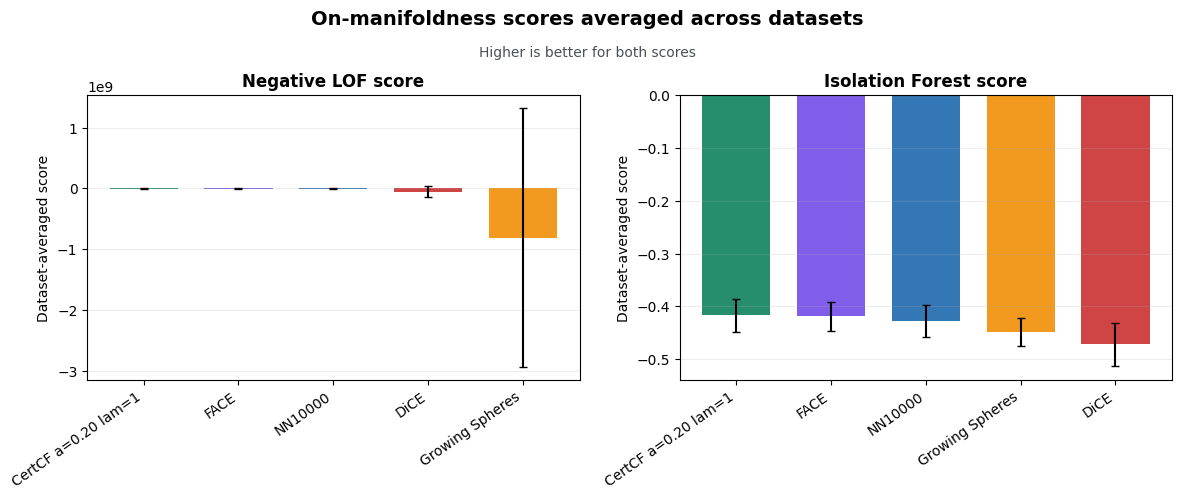

In [22]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from counterfactuals.benchmarks import create_default_registries

LOF_N_NEIGHBORS = 20
IFOREST_N_ESTIMATORS = 200
IFOREST_RANDOM_STATE = 0


def x_cf_columns_for_dim(d: int) -> list[str]:
    return [f'x_cf_{idx}' for idx in range(int(d))]


def load_train_by_dataset(dataset_order: list[str]) -> dict[str, np.ndarray]:
    registries = create_default_registries()
    train_by_dataset = {}
    for dataset_name in dataset_order:
        dataset = registries['dataset'].create(dataset_name, data_dir=str(ROOT / 'data'))
        dataset.load()
        x_train, _ = dataset.get_train()
        train_by_dataset[dataset_name] = np.asarray(x_train, dtype=np.float32)
    return train_by_dataset


def compute_manifoldness_scores(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    train_by_dataset = load_train_by_dataset(DATASET_ORDER)
    rows = []

    for dataset_name in DATASET_ORDER:
        x_train = train_by_dataset[dataset_name]
        cf_cols = x_cf_columns_for_dim(x_train.shape[1])
        ds = df[df['dataset'].astype(str).eq(dataset_name)]
        if ds.empty or not set(cf_cols).issubset(ds.columns):
            continue

        lof = LocalOutlierFactor(
            n_neighbors=min(LOF_N_NEIGHBORS, max(1, len(x_train) - 1)),
            novelty=True,
            n_jobs=-1,
        )
        lof.fit(x_train)

        iforest = IsolationForest(
            n_estimators=IFOREST_N_ESTIMATORS,
            contamination='auto',
            random_state=IFOREST_RANDOM_STATE,
            n_jobs=-1,
        )
        iforest.fit(x_train)

        for method_label in METHOD_ORDER:
            method_df = ds[
                ds['method_label'].astype(str).eq(method_label)
                & ds['success'].astype(bool)
            ].copy()
            if method_df.empty:
                continue

            x_cf = method_df[cf_cols].to_numpy(dtype=np.float32)
            finite = np.isfinite(x_cf).all(axis=1)
            if not finite.any():
                continue
            x_cf = x_cf[finite]

            rows.append({
                'dataset': dataset_name,
                'method_label': method_label,
                'n_success': int(len(x_cf)),
                'negative_lof_mean': float(np.mean(lof.score_samples(x_cf))),
                'iforest_score_mean': float(np.mean(iforest.score_samples(x_cf))),
            })

    by_dataset = pd.DataFrame(rows)
    averaged = (
        by_dataset
        .groupby('method_label', observed=True)
        .agg(
            n_datasets=('dataset', 'nunique'),
            total_success=('n_success', 'sum'),
            dataset_avg_negative_lof=('negative_lof_mean', 'mean'),
            dataset_std_negative_lof=('negative_lof_mean', 'std'),
            dataset_avg_iforest_score=('iforest_score_mean', 'mean'),
            dataset_std_iforest_score=('iforest_score_mean', 'std'),
        )
        .reset_index()
    )
    averaged['method_label'] = pd.Categorical(averaged['method_label'], METHOD_ORDER, ordered=True)
    averaged = averaged.sort_values('method_label', ignore_index=True)
    return by_dataset, averaged


def plot_manifoldness_barplots(summary_df: pd.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8), sharex=False)
    plot_df = summary_df.copy()

    specs = [
        ('dataset_avg_negative_lof', 'dataset_std_negative_lof', 'Negative LOF score', axes[0]),
        ('dataset_avg_iforest_score', 'dataset_std_iforest_score', 'Isolation Forest score', axes[1]),
    ]
    for value_col, err_col, title, ax in specs:
        metric_df = plot_df.sort_values(value_col, ascending=False, ignore_index=True)
        labels = metric_df['method_label'].astype(str).tolist()
        x = np.arange(len(labels))
        colors = [PALETTE.get(label, '#868E96') for label in labels]
        y = metric_df[value_col].to_numpy(dtype=float)
        yerr = metric_df[err_col].fillna(0.0).to_numpy(dtype=float)
        ax.bar(x, y, yerr=yerr, color=colors, alpha=0.88, capsize=3, width=0.72)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_ylabel('Dataset-averaged score')
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=35, ha='right')
        ax.grid(True, axis='y', alpha=0.22)

    fig.suptitle('On-manifoldness scores averaged across datasets', fontsize=14, fontweight='bold', y=1.03)
    fig.text(0.5, 0.94, 'Higher is better for both scores', ha='center', va='center', fontsize=10, color='#495057')
    fig.tight_layout()
    return fig, axes


MANIFOLDNESS_BY_DATASET_DF, MANIFOLDNESS_AVERAGED_DF = compute_manifoldness_scores(BENCHMARK_DF)
display(MANIFOLDNESS_AVERAGED_DF.round(4))
plot_manifoldness_barplots(MANIFOLDNESS_AVERAGED_DF);

## Sparsity

,method_label,n_datasets,total_success,dataset_avg_l0,dataset_std_l0
0,CertCF a=0.20 lam=1,7,4773,8.0322,5.6412
1,NN10000,7,4773,10.7037,9.4937
2,Growing Spheres,7,4763,3.7163,2.5708
3,DiCE,7,4463,6.1963,2.3916
4,FACE,7,4683,12.4242,9.1964


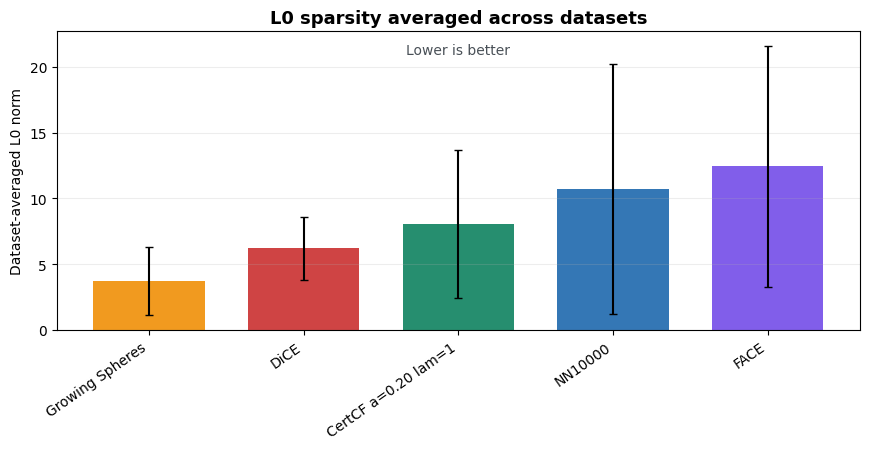

In [22]:
L0_TOL = 1e-6


def indexed_columns(df: pd.DataFrame, prefix: str) -> list[str]:
    cols = [c for c in df.columns if c.startswith(prefix)]
    return sorted(cols, key=lambda c: int(c.rsplit('_', 1)[1]))


def compute_l0_sparsity(df: pd.DataFrame, tol: float = L0_TOL) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    for dataset_name in DATASET_ORDER:
        ds = df[df['dataset'].astype(str).eq(dataset_name)]
        if ds.empty:
            continue

        orig_cols = [c for c in indexed_columns(ds, 'x_orig_') if ds[c].notna().any()]
        cf_cols = [f"x_cf_{c.rsplit('_', 1)[1]}" for c in orig_cols]
        if not orig_cols or not set(cf_cols).issubset(ds.columns):
            continue

        for method_label in METHOD_ORDER:
            method_df = ds[
                ds['method_label'].astype(str).eq(method_label)
                & ds['success'].astype(bool)
            ]
            if method_df.empty:
                continue

            x_orig = method_df[orig_cols].to_numpy(dtype=float)
            x_cf = method_df[cf_cols].to_numpy(dtype=float)
            finite = np.isfinite(x_orig).all(axis=1) & np.isfinite(x_cf).all(axis=1)
            if not finite.any():
                continue

            l0 = (np.abs(x_cf[finite] - x_orig[finite]) > tol).sum(axis=1)
            rows.append({
                'dataset': dataset_name,
                'method_label': method_label,
                'n_success': int(len(l0)),
                'l0_mean': float(np.mean(l0)),
                'l0_std': float(np.std(l0, ddof=1)) if len(l0) > 1 else 0.0,
            })

    by_dataset = pd.DataFrame(rows)
    averaged = (
        by_dataset
        .groupby('method_label', observed=True)
        .agg(
            n_datasets=('dataset', 'nunique'),
            total_success=('n_success', 'sum'),
            dataset_avg_l0=('l0_mean', 'mean'),
            dataset_std_l0=('l0_mean', 'std'),
        )
        .reset_index()
    )
    averaged['method_label'] = pd.Categorical(averaged['method_label'], METHOD_ORDER, ordered=True)
    averaged = averaged.sort_values('method_label', ignore_index=True)
    return by_dataset, averaged


def plot_l0_sparsity_barplot(summary_df: pd.DataFrame):
    plot_df = summary_df.sort_values('dataset_avg_l0', ascending=True, ignore_index=True)
    labels = plot_df['method_label'].astype(str).tolist()
    x = np.arange(len(labels))
    colors = [PALETTE.get(label, '#868E96') for label in labels]
    y = plot_df['dataset_avg_l0'].to_numpy(dtype=float)
    yerr = plot_df['dataset_std_l0'].fillna(0.0).to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(8.8, 4.6))
    ax.bar(x, y, yerr=yerr, color=colors, alpha=0.88, capsize=3, width=0.72)
    ax.set_title('L0 sparsity averaged across datasets', fontsize=13, fontweight='bold')
    ax.text(0.5, 0.96, 'Lower is better', transform=ax.transAxes, ha='center', va='top', fontsize=10, color='#495057')
    ax.set_ylabel('Dataset-averaged L0 norm')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha='right')
    ax.grid(True, axis='y', alpha=0.22)
    fig.tight_layout()
    return fig, ax


SPARSITY_BY_DATASET_DF, SPARSITY_AVERAGED_DF = compute_l0_sparsity(BENCHMARK_DF)
display(SPARSITY_AVERAGED_DF.round(4))
plot_l0_sparsity_barplot(SPARSITY_AVERAGED_DF);

### L0 Sparsity on Shared Successful Queries

Shared successful query counts per dataset:


,dataset,n_shared_success_queries,n_total_CertCF a=0.20 lam=1,n_total_NN10000,n_total_Growing Spheres,n_total_DiCE,n_total_FACE
0,adult,891,1000,1000,1000,1000,1000
1,compas,517,617,617,617,617,617
2,german_credit,85,100,100,100,100,100
3,give_me_some_credit,989,1000,1000,1000,1000,1000
4,heloc,885,1000,1000,1000,1000,1000
5,lending_club,977,1000,1000,1000,1000,1000
6,wisconsin_breast_cancer,54,56,56,56,56,56


L0 sparsity computed only on queries where every plotted method succeeded:


,method_label,n_datasets,total_success,dataset_avg_l0,dataset_std_l0
0,CertCF a=0.20 lam=1,7,4398,7.8594,5.5441
1,NN10000,7,4398,10.5698,9.4657
2,Growing Spheres,7,4398,3.6851,2.5821
3,DiCE,7,4398,6.1656,2.4062
4,FACE,7,4398,12.3976,9.1944


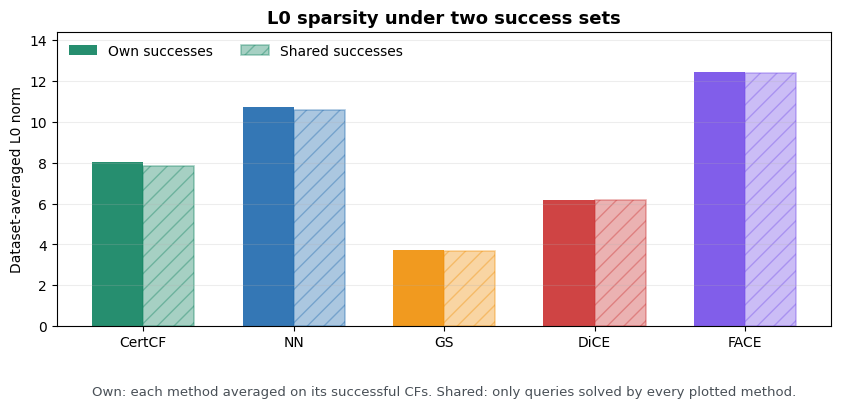

In [23]:
def plot_l0_sparsity_own_vs_shared_success(
    own_summary_df: pd.DataFrame,
    shared_summary_df: pd.DataFrame,
    method_order: list[str],
):
    own = (
        own_summary_df.assign(method_label=lambda x: x['method_label'].astype(str))
        .set_index('method_label')
        .reindex(method_order)
    )
    shared = (
        shared_summary_df.assign(method_label=lambda x: x['method_label'].astype(str))
        .set_index('method_label')
        .reindex(method_order)
    )

    display_labels = {
        method_order[0]: 'CertCF',
        'NN10000': 'NN',
        'Growing Spheres': 'GS',
        'DiCE': 'DiCE',
        'FACE': 'FACE',
    }
    labels = [display_labels.get(label, label) for label in method_order]
    x = np.arange(len(labels), dtype=float)
    width = 0.34
    own_y = own['dataset_avg_l0'].to_numpy(dtype=float)
    shared_y = shared['dataset_avg_l0'].to_numpy(dtype=float)
    base_colors = [PALETTE.get(label, '#868E96') for label in method_order]

    fig, ax = plt.subplots(figsize=(8.8, 4.6))
    ax.bar(
        x - width / 2,
        own_y,
        width=width,
        color=base_colors,
        alpha=0.88,
        label='Own successes',
    )
    ax.bar(
        x + width / 2,
        shared_y,
        width=width,
        color=base_colors,
        alpha=0.36,
        edgecolor=base_colors,
        linewidth=1.2,
        hatch='//',
        label='Shared successes',
    )

    ax.set_title('L0 sparsity under two success sets', fontsize=13, fontweight='bold')
    ax.set_ylabel('Dataset-averaged L0 norm')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.grid(True, axis='y', alpha=0.22)
    ax.legend(frameon=False, loc='upper left', ncol=2)
    ax.text(
        0.5,
        -0.20,
        'Own: each method averaged on its successful CFs. Shared: only queries solved by every plotted method.',
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=9.5,
        color='#495057',
    )
    finite_y = np.concatenate([own_y[np.isfinite(own_y)], shared_y[np.isfinite(shared_y)]])
    if finite_y.size:
        ax.set_ylim(0.0, float(finite_y.max()) * 1.16)
    fig.subplots_adjust(bottom=0.24, top=0.88, left=0.10, right=0.98)
    return fig, ax


SHARED_SPARSITY_DF, SHARED_SPARSITY_COUNTS_DF = filter_to_shared_success_queries(
    BENCHMARK_DF,
    METHOD_ORDER,
)
SHARED_SPARSITY_BY_DATASET_DF, SHARED_SPARSITY_AVERAGED_DF = compute_l0_sparsity(
    SHARED_SPARSITY_DF,
)

print('Shared successful query counts per dataset:')
display(SHARED_SPARSITY_COUNTS_DF)
print('L0 sparsity computed only on queries where every plotted method succeeded:')
display(SHARED_SPARSITY_AVERAGED_DF.round(4))
plot_l0_sparsity_own_vs_shared_success(SPARSITY_AVERAGED_DF, SHARED_SPARSITY_AVERAGED_DF, METHOD_ORDER);


## Decision Tree Surrogate Interpretability

,method_label,n_datasets,total_success,dataset_avg_tree_r2,dataset_std_tree_r2,dataset_avg_tree_normalized_l1_error,dataset_std_tree_normalized_l1_error,dataset_avg_tree_depth,dataset_avg_tree_leaves
0,CertCF a=0.20 lam=1,7,4773,0.2695,0.1718,1.4427,0.7420,3.0,7.4286
1,NN10000,7,4773,0.2805,0.1743,1.8324,1.0008,3.0,7.2857
2,Growing Spheres,7,4763,0.2604,0.2308,2.1166,0.8388,3.0,6.5714
3,DiCE,7,4463,0.2627,0.1559,2.4365,1.2449,3.0,6.8571
4,FACE,7,4683,0.2755,0.2116,1.6648,0.9451,3.0,7.1429


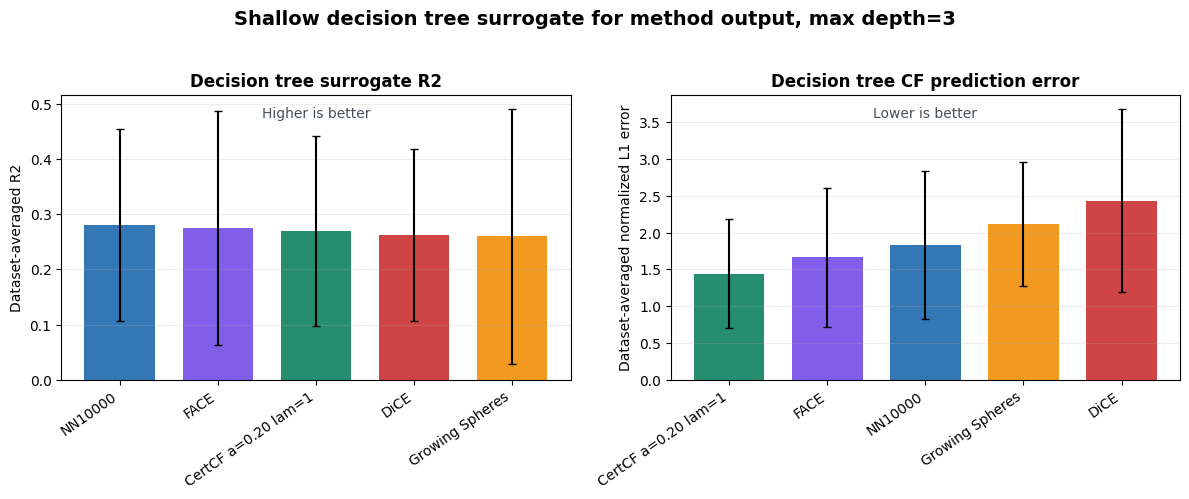

In [24]:
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

SURROGATE_TREE_MAX_DEPTH = 3
SURROGATE_TREE_MIN_SAMPLES_LEAF = 5
SURROGATE_TREE_TEST_SIZE = 0.30
SURROGATE_TREE_RANDOM_STATE = 0
SURROGATE_TREE_MIN_SAMPLES = 20


def compute_tree_surrogate_interpretability(
    df: pd.DataFrame,
    max_depth: int = SURROGATE_TREE_MAX_DEPTH,
    min_samples_leaf: int = SURROGATE_TREE_MIN_SAMPLES_LEAF,
    test_size: float = SURROGATE_TREE_TEST_SIZE,
    random_state: int = SURROGATE_TREE_RANDOM_STATE,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    if 'L1_SCALE_DF' in globals():
        scale_by_dataset = L1_SCALE_DF.set_index('dataset')['l1_scale'].to_dict()
    else:
        scale_by_dataset = nn10000_l1_scale_by_dataset(df).set_index('dataset')['l1_scale'].to_dict()

    rows = []
    for dataset_name in DATASET_ORDER:
        ds = df[df['dataset'].astype(str).eq(dataset_name)]
        if ds.empty:
            continue

        orig_cols = [c for c in indexed_columns(ds, 'x_orig_') if ds[c].notna().any()]
        cf_cols = [f"x_cf_{c.rsplit('_', 1)[1]}" for c in orig_cols]
        if not orig_cols or not set(cf_cols).issubset(ds.columns):
            continue

        scale = scale_by_dataset.get(dataset_name, np.nan)
        if not np.isfinite(scale) or scale <= 0:
            scale = 1.0

        for method_label in METHOD_ORDER:
            method_df = ds[
                ds['method_label'].astype(str).eq(method_label)
                & ds['success'].astype(bool)
            ]
            if len(method_df) < SURROGATE_TREE_MIN_SAMPLES:
                continue

            x_query = method_df[orig_cols].to_numpy(dtype=float)
            x_cf = method_df[cf_cols].to_numpy(dtype=float)
            finite = np.isfinite(x_query).all(axis=1) & np.isfinite(x_cf).all(axis=1)
            x_query = x_query[finite]
            x_cf = x_cf[finite]
            if len(x_query) < SURROGATE_TREE_MIN_SAMPLES:
                continue

            train_idx, test_idx = train_test_split(
                np.arange(len(x_query)),
                test_size=test_size,
                random_state=random_state,
            )
            tree = DecisionTreeRegressor(
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                random_state=random_state,
            )
            tree.fit(x_query[train_idx], x_cf[train_idx])
            pred = tree.predict(x_query[test_idx])
            true = x_cf[test_idx]

            l1_error = np.abs(pred - true).sum(axis=1)
            rows.append({
                'dataset': dataset_name,
                'method_label': method_label,
                'n_success': int(len(x_query)),
                'n_test': int(len(test_idx)),
                'tree_depth': int(tree.get_depth()),
                'tree_leaves': int(tree.get_n_leaves()),
                'tree_r2': float(r2_score(true, pred, multioutput='variance_weighted')),
                'tree_l1_error': float(np.mean(l1_error)),
                'tree_normalized_l1_error': float(np.mean(l1_error / scale)),
            })

    by_dataset = pd.DataFrame(rows)
    averaged = (
        by_dataset
        .groupby('method_label', observed=True)
        .agg(
            n_datasets=('dataset', 'nunique'),
            total_success=('n_success', 'sum'),
            dataset_avg_tree_r2=('tree_r2', 'mean'),
            dataset_std_tree_r2=('tree_r2', 'std'),
            dataset_avg_tree_normalized_l1_error=('tree_normalized_l1_error', 'mean'),
            dataset_std_tree_normalized_l1_error=('tree_normalized_l1_error', 'std'),
            dataset_avg_tree_depth=('tree_depth', 'mean'),
            dataset_avg_tree_leaves=('tree_leaves', 'mean'),
        )
        .reset_index()
    )
    averaged['method_label'] = pd.Categorical(averaged['method_label'], METHOD_ORDER, ordered=True)
    averaged = averaged.sort_values('method_label', ignore_index=True)
    return by_dataset, averaged


def plot_tree_surrogate_interpretability(summary_df: pd.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8), sharex=False)

    specs = [
        (
            'dataset_avg_tree_r2',
            'dataset_std_tree_r2',
            'Decision tree surrogate R2',
            'Dataset-averaged R2',
            False,
            'Higher is better',
            axes[0],
        ),
        (
            'dataset_avg_tree_normalized_l1_error',
            'dataset_std_tree_normalized_l1_error',
            'Decision tree CF prediction error',
            'Dataset-averaged normalized L1 error',
            True,
            'Lower is better',
            axes[1],
        ),
    ]

    for value_col, err_col, title, ylabel, ascending, note, ax in specs:
        plot_df = summary_df.sort_values(value_col, ascending=ascending, ignore_index=True)
        labels = plot_df['method_label'].astype(str).tolist()
        x = np.arange(len(labels))
        colors = [PALETTE.get(label, '#868E96') for label in labels]
        y = plot_df[value_col].to_numpy(dtype=float)
        yerr = plot_df[err_col].fillna(0.0).to_numpy(dtype=float)

        ax.bar(x, y, yerr=yerr, color=colors, alpha=0.88, capsize=3, width=0.72)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.text(0.5, 0.96, note, transform=ax.transAxes, ha='center', va='top', fontsize=10, color='#495057')
        ax.set_ylabel(ylabel)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=35, ha='right')
        ax.grid(True, axis='y', alpha=0.22)

    fig.suptitle(
        f'Shallow decision tree surrogate for method output, max depth={SURROGATE_TREE_MAX_DEPTH}',
        fontsize=14,
        fontweight='bold',
        y=1.03,
    )
    fig.tight_layout()
    return fig, axes


TREE_SURROGATE_BY_DATASET_DF, TREE_SURROGATE_AVERAGED_DF = compute_tree_surrogate_interpretability(BENCHMARK_DF)
display(TREE_SURROGATE_AVERAGED_DF.round(4))
plot_tree_surrogate_interpretability(TREE_SURROGATE_AVERAGED_DF);

## LaTeX Tables

Code-only table export section for paper-ready LaTeX. These tables keep only `CertCF alpha=0.15` among the CertCF variants.

In [25]:
TABLE_METHOD_ORDER = METHOD_ORDER
TABLE_METHOD_DISPLAY = {
    PAPER_CERTCF_LABEL: 'CertCF',
    'NN10000': 'NN',
    'Growing Spheres': 'Growing Spheres',
    'DiCE': 'DiCE',
    'FACE': 'FACE',
}


def _format_mean_std(row: pd.Series, mean_col: str, std_col: str | None = None, precision: int = 2) -> str:
    value = row.get(mean_col, np.nan)
    if pd.isna(value):
        return '--'
    value_text = f"{float(value):.{precision}f}"
    if std_col is None:
        return value_text
    std = row.get(std_col, np.nan)
    if pd.isna(std):
        return value_text
    return f"{value_text} $\\pm$ {float(std):.{precision}f}"


def make_latex_metric_table(
    summary_df: pd.DataFrame,
    metric_specs: list[tuple[str, str, str | None, int]],
    caption: str,
    label: str,
) -> tuple[pd.DataFrame, str]:
    table_df = summary_df.copy()
    table_df['_method_label_str'] = table_df['method_label'].astype(str)
    table_df = table_df[table_df['_method_label_str'].isin(TABLE_METHOD_ORDER)].copy()
    table_df['_method_order'] = pd.Categorical(table_df['_method_label_str'], TABLE_METHOD_ORDER, ordered=True)
    table_df = table_df.sort_values('_method_order', ignore_index=True)

    out = pd.DataFrame({
        'Method': table_df['_method_label_str'].map(TABLE_METHOD_DISPLAY).fillna(table_df['_method_label_str'])
    })
    for column_label, mean_col, std_col, precision in metric_specs:
        out[column_label] = [
            _format_mean_std(row, mean_col=mean_col, std_col=std_col, precision=precision)
            for _, row in table_df.iterrows()
        ]

    latex = out.to_latex(index=False, escape=False, caption=caption, label=label)
    return out, latex


In [26]:
VALIDITY_TABLE_DF, VALIDITY_TABLE_LATEX = make_latex_metric_table(
    VALIDITY_AVERAGED_DF,
    metric_specs=[('Validity (\\%)', 'dataset_avg_validity_pct', 'dataset_std_validity_pct', 1)],
    caption='Dataset-averaged counterfactual validity.',
    label='tab:validity',
)
print(VALIDITY_TABLE_LATEX)

\begin{table}
\caption{Dataset-averaged counterfactual validity.}
\label{tab:validity}
\begin{tabular}{ll}
\toprule
Method & Validity (\%) \\
\midrule
CertCF & 100.0 $\pm$ 0.0 \\
NN & 100.0 $\pm$ 0.0 \\
Growing Spheres & 99.6 $\pm$ 0.7 \\
DiCE & 93.2 $\pm$ 6.2 \\
FACE & 98.1 $\pm$ 2.0 \\
\bottomrule
\end{tabular}
\end{table}



In [27]:
_old_table_method_order = TABLE_METHOD_ORDER
_old_table_method_display = TABLE_METHOD_DISPLAY
try:
    TABLE_METHOD_ORDER = PROXIMITY_METHOD_ORDER
    TABLE_METHOD_DISPLAY = {
        PROXIMITY_CERTCF_LABEL: 'CertCF',
        'NN10000': 'NN',
        'Growing Spheres': 'Growing Spheres',
        'DiCE': 'DiCE',
        'FACE': 'FACE',
    }
    L1_PROXIMITY_TABLE_DF, L1_PROXIMITY_TABLE_LATEX = make_latex_metric_table(
        L1_PROXIMITY_AVERAGED_DF,
        metric_specs=[('L1 proximity', 'dataset_avg_l1', 'dataset_std_l1', 3)],
        caption='Dataset-averaged L1 proximity.',
        label='tab:l1-proximity',
    )
finally:
    TABLE_METHOD_ORDER = _old_table_method_order
    TABLE_METHOD_DISPLAY = _old_table_method_display

print(L1_PROXIMITY_TABLE_LATEX)


\begin{table}
\caption{Dataset-averaged L1 proximity.}
\label{tab:l1-proximity}
\begin{tabular}{ll}
\toprule
Method & L1 proximity \\
\midrule
CertCF & 7.404 $\pm$ 5.438 \\
NN & 6.918 $\pm$ 6.169 \\
Growing Spheres & 2.565 $\pm$ 2.464 \\
DiCE & 4.369 $\pm$ 2.719 \\
FACE & 9.334 $\pm$ 8.049 \\
\bottomrule
\end{tabular}
\end{table}



In [28]:
ROBUSTNESS_TABLE_DF, ROBUSTNESS_TABLE_LATEX = make_latex_metric_table(
    ROBUSTNESS_AVERAGED_DF,
    metric_specs=[('Target robustness (\\%)', 'dataset_avg_target_robustness_pct', 'dataset_std_target_robustness_pct', 1)],
    caption='Dataset-averaged robustness of returned counterfactuals, averaged over the perturbation grid.',
    label='tab:robustness',
)
print(ROBUSTNESS_TABLE_LATEX)


\begin{table}
\caption{Dataset-averaged robustness of returned counterfactuals under random perturbations.}
\label{tab:robustness}
\begin{tabular}{ll}
\toprule
Method & Target robustness (\%) \\
\midrule
CertCF & 92.3 $\pm$ 5.6 \\
NN & 86.7 $\pm$ 6.8 \\
Growing Spheres & 71.0 $\pm$ 8.2 \\
DiCE & 91.3 $\pm$ 8.1 \\
FACE & 87.8 $\pm$ 7.6 \\
\bottomrule
\end{tabular}
\end{table}



In [29]:
CONFIDENCE_TABLE_DF, CONFIDENCE_TABLE_LATEX = make_latex_metric_table(
    CONFIDENCE_AVERAGED_DF,
    metric_specs=[('Target probability', 'dataset_avg_target_probability', 'dataset_std_target_probability', 3)],
    caption='Dataset-averaged classifier target probability at returned counterfactuals.',
    label='tab:confidence',
)
print(CONFIDENCE_TABLE_LATEX)

\begin{table}
\caption{Dataset-averaged classifier target probability at returned counterfactuals.}
\label{tab:confidence}
\begin{tabular}{ll}
\toprule
Method & Target probability \\
\midrule
CertCF & 0.694 $\pm$ 0.132 \\
NN & 0.639 $\pm$ 0.108 \\
Growing Spheres & 0.546 $\pm$ 0.038 \\
DiCE & 0.719 $\pm$ 0.115 \\
FACE & 0.670 $\pm$ 0.147 \\
\bottomrule
\end{tabular}
\end{table}



In [30]:
PRIVACY_TABLE_DF, PRIVACY_TABLE_LATEX = make_latex_metric_table(
    PRIVACY_AVERAGED_DF,
    metric_specs=[
        ('Train hit rate (\\%)', 'dataset_avg_train_hit_rate_pct', 'dataset_std_train_hit_rate_pct', 2),
        ('Nearest train $L_1$', 'dataset_avg_nearest_train_l1', None, 4),
    ],
    caption='Dataset-averaged training-hit privacy leakage and nearest-training-point distance.',
    label='tab:privacy-hit-rate',
)
print(PRIVACY_TABLE_LATEX)

\begin{table}
\caption{Dataset-averaged training-hit privacy leakage and nearest-training-point distance.}
\label{tab:privacy-hit-rate}
\begin{tabular}{lll}
\toprule
Method & Train hit rate (\%) & Nearest train $L_1$ \\
\midrule
CertCF & 0.00 $\pm$ 0.00 & 0.6324 \\
NN & 100.00 $\pm$ 0.00 & 0.0000 \\
Growing Spheres & 0.00 $\pm$ 0.00 & 5.0899 \\
DiCE & 0.00 $\pm$ 0.00 & 5.8641 \\
FACE & 100.00 $\pm$ 0.00 & 0.0000 \\
\bottomrule
\end{tabular}
\end{table}



In [31]:
PRIVACY_ENTROPY_TABLE_DF, PRIVACY_ENTROPY_TABLE_LATEX = make_latex_metric_table(
    PRIVACY_ENTROPY_AVERAGED_DF,
    metric_specs=[
        ('$H_k$', 'dataset_avg_k_neighbor_entropy', 'dataset_std_k_neighbor_entropy', 3),
        ('Normalized $H_k$', 'dataset_avg_normalized_k_neighbor_entropy', 'dataset_std_normalized_k_neighbor_entropy', 3),
    ],
    caption='Dataset-averaged k-neighborhood label entropy around returned counterfactuals.',
    label='tab:k-neighborhood-entropy',
)
print(PRIVACY_ENTROPY_TABLE_LATEX)

\begin{table}
\caption{Dataset-averaged k-neighborhood label entropy around returned counterfactuals.}
\label{tab:k-neighborhood-entropy}
\begin{tabular}{lll}
\toprule
Method & $H_k$ & Normalized $H_k$ \\
\midrule
CertCF & 0.516 $\pm$ 0.128 & 0.744 $\pm$ 0.184 \\
NN & 0.513 $\pm$ 0.154 & 0.741 $\pm$ 0.222 \\
Growing Spheres & 0.426 $\pm$ 0.187 & 0.614 $\pm$ 0.270 \\
DiCE & 0.467 $\pm$ 0.131 & 0.674 $\pm$ 0.189 \\
FACE & 0.502 $\pm$ 0.162 & 0.724 $\pm$ 0.234 \\
\bottomrule
\end{tabular}
\end{table}



In [32]:
MANIFOLDNESS_TABLE_DF, MANIFOLDNESS_TABLE_LATEX = make_latex_metric_table(
    MANIFOLDNESS_AVERAGED_DF,
    metric_specs=[
        ('Negative LOF', 'dataset_avg_negative_lof', 'dataset_std_negative_lof', 3),
        ('Isolation Forest', 'dataset_avg_iforest_score', 'dataset_std_iforest_score', 3),
    ],
    caption='Dataset-averaged on-manifoldness scores. Higher values are better for both metrics.',
    label='tab:on-manifoldness',
)
print(MANIFOLDNESS_TABLE_LATEX)

\begin{table}
\caption{Dataset-averaged on-manifoldness scores. Higher values are better for both metrics.}
\label{tab:on-manifoldness}
\begin{tabular}{lll}
\toprule
Method & Negative LOF & Isolation Forest \\
\midrule
CertCF & -939897.079 $\pm$ 2486731.039 & -0.417 $\pm$ 0.032 \\
NN & -3806122.410 $\pm$ 10070050.327 & -0.427 $\pm$ 0.030 \\
Growing Spheres & -807701460.393 $\pm$ 2127154495.185 & -0.448 $\pm$ 0.026 \\
DiCE & -51571413.660 $\pm$ 92366252.793 & -0.472 $\pm$ 0.041 \\
FACE & -2825794.940 $\pm$ 7476347.766 & -0.419 $\pm$ 0.028 \\
\bottomrule
\end{tabular}
\end{table}



In [33]:
SPARSITY_TABLE_DF, SPARSITY_TABLE_LATEX = make_latex_metric_table(
    SPARSITY_AVERAGED_DF,
    metric_specs=[('$L_0$', 'dataset_avg_l0', 'dataset_std_l0', 2)],
    caption='Dataset-averaged counterfactual sparsity measured by the L0 norm.',
    label='tab:sparsity',
)
print(SPARSITY_TABLE_LATEX)

\begin{table}
\caption{Dataset-averaged counterfactual sparsity measured by the L0 norm.}
\label{tab:sparsity}
\begin{tabular}{ll}
\toprule
Method & $L_0$ \\
\midrule
CertCF & 8.03 $\pm$ 5.64 \\
NN & 10.70 $\pm$ 9.49 \\
Growing Spheres & 3.72 $\pm$ 2.57 \\
DiCE & 6.20 $\pm$ 2.39 \\
FACE & 12.42 $\pm$ 9.20 \\
\bottomrule
\end{tabular}
\end{table}



In [34]:
TREE_SURROGATE_TABLE_DF, TREE_SURROGATE_TABLE_LATEX = make_latex_metric_table(
    TREE_SURROGATE_AVERAGED_DF,
    metric_specs=[
        ('Tree $R^2$', 'dataset_avg_tree_r2', 'dataset_std_tree_r2', 3),
        ('Tree normalized L1 error', 'dataset_avg_tree_normalized_l1_error', 'dataset_std_tree_normalized_l1_error', 3),
        ('Tree depth', 'dataset_avg_tree_depth', None, 1),
        ('Tree leaves', 'dataset_avg_tree_leaves', None, 1),
    ],
    caption='Dataset-averaged decision-tree surrogate metrics for predicting returned counterfactuals from query points.',
    label='tab:tree-surrogate',
)
print(TREE_SURROGATE_TABLE_LATEX)

\begin{table}
\caption{Dataset-averaged decision-tree surrogate metrics for predicting returned counterfactuals from query points.}
\label{tab:tree-surrogate}
\begin{tabular}{lllll}
\toprule
Method & Tree $R^2$ & Tree normalized L1 error & Tree depth & Tree leaves \\
\midrule
CertCF & 0.269 $\pm$ 0.172 & 1.443 $\pm$ 0.742 & 3.0 & 7.4 \\
NN & 0.280 $\pm$ 0.174 & 1.832 $\pm$ 1.001 & 3.0 & 7.3 \\
Growing Spheres & 0.260 $\pm$ 0.231 & 2.117 $\pm$ 0.839 & 3.0 & 6.6 \\
DiCE & 0.263 $\pm$ 0.156 & 2.437 $\pm$ 1.245 & 3.0 & 6.9 \\
FACE & 0.276 $\pm$ 0.212 & 1.665 $\pm$ 0.945 & 3.0 & 7.1 \\
\bottomrule
\end{tabular}
\end{table}



## Paper Plot: Target Robustness Heatmaps

Code to generate a pure TikZ/LaTeX target-robustness heatmap. This keeps only the selected CertCF alpha among CertCF variants.

In [35]:
HEATMAP_CERTCF_LABEL = PAPER_CERTCF_LABEL
HEATMAP_METHOD_ORDER = [
    HEATMAP_CERTCF_LABEL,
    'NN10000',
    'Growing Spheres',
    'DiCE',
    'FACE',
]
HEATMAP_METHOD_DISPLAY = {
    HEATMAP_CERTCF_LABEL: 'CertCF',
    'NN10000': 'NN',
    'Growing Spheres': 'Growing Spheres',
    'DiCE': 'DiCE',
    'FACE': 'FACE',
}


def build_heatmap_benchmark_df_from_frames(frames: list[pd.DataFrame]) -> pd.DataFrame:
    raw = pd.concat(frames, ignore_index=True).copy()
    raw['method_label'] = raw.apply(method_label, axis=1)

    available_certcf = sorted(raw.loc[raw['method'].astype(str).eq('certcf'), 'method_label'].astype(str).unique())
    if HEATMAP_CERTCF_LABEL not in available_certcf:
        raise ValueError(
            f'{HEATMAP_CERTCF_LABEL} is not present in the loaded benchmark results. '
            f'Available CertCF variants: {available_certcf}'
        )

    out = raw[raw['method_label'].astype(str).isin(HEATMAP_METHOD_ORDER)].copy()
    out['dataset'] = pd.Categorical(out['dataset'], DATASET_ORDER, ordered=True)
    out['method_label'] = pd.Categorical(out['method_label'].astype(str), HEATMAP_METHOD_ORDER, ordered=True)
    return out.sort_values(['dataset', 'method_label', 'query_idx'], ignore_index=True)


def compute_heatmap_robustness_grid(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    old_method_order = globals().get('METHOD_ORDER')
    try:
        globals()['METHOD_ORDER'] = HEATMAP_METHOD_ORDER
        return compute_robustness_grid(df)
    finally:
        globals()['METHOD_ORDER'] = old_method_order


def target_robustness_heatmaps_to_tikz(
    grid_df: pd.DataFrame,
    sigma_grid: list[float] = ROBUSTNESS_SIGMA_GRID,
    categorical_flip_grid: list[float] = ROBUSTNESS_CAT_FLIP_GRID,
) -> str:
    methods = [method for method in HEATMAP_METHOD_ORDER if method in set(grid_df['method_label'].astype(str))]
    ncols = 3
    cell_w = 0.72
    cell_h = 0.56
    panel_gap_x = 0.9
    panel_gap_y = 1.05
    panel_w = len(sigma_grid) * cell_w
    panel_h = len(categorical_flip_grid) * cell_h

    best_by_cell = (
        grid_df
        .groupby(['numerical_sigma', 'categorical_flip_p'], observed=True)['dataset_avg_target_robustness_pct']
        .max()
        .to_dict()
    )
    finite_values = grid_df['dataset_avg_target_robustness_pct'].to_numpy(dtype=float)
    finite_values = finite_values[np.isfinite(finite_values)]
    color_min = float(finite_values.min()) if finite_values.size else 0.0
    color_max = float(finite_values.max()) if finite_values.size else 100.0
    if np.isclose(color_min, color_max):
        color_min = max(0.0, color_min - 1.0)
        color_max = min(100.0, color_max + 1.0)

    lines = [
        r'% Requires: \usepackage{tikz}',
        r'% Requires: \usepackage{xcolor}',
        r'% Robustness heatmaps: higher is better; bold cell values are best per perturbation level.',
        r'\definecolor{robustLow}{HTML}{FDE725}',
        r'\definecolor{robustHigh}{HTML}{440154}',
        r'\begin{tikzpicture}[x=1cm,y=1cm,font=\scriptsize]',
    ]

    for method_idx, method_label in enumerate(methods):
        panel_col = method_idx % ncols
        panel_row = method_idx // ncols
        x0 = panel_col * (panel_w + panel_gap_x)
        y0 = -panel_row * (panel_h + panel_gap_y)
        method_df = grid_df[grid_df['method_label'].astype(str).eq(method_label)]
        heat = (
            method_df
            .pivot(index='categorical_flip_p', columns='numerical_sigma', values='dataset_avg_target_robustness_pct')
            .reindex(index=categorical_flip_grid, columns=sigma_grid)
        )

        lines.append(f'  \\begin{{scope}}[shift={{({x0:.2f},{y0:.2f})}}]')
        lines.append(f'    \\node[font=\\bfseries] at ({panel_w / 2:.2f},{panel_h + 0.35:.2f}) {{{HEATMAP_METHOD_DISPLAY.get(method_label, method_label)}}};')
        lines.append(f'    \\node at ({panel_w / 2:.2f},-0.62) {{numerical $\\sigma$}};')

        for row_idx, categorical_flip_p in enumerate(categorical_flip_grid):
            y = row_idx * cell_h
            lines.append(f'    \\node[anchor=east] at (-0.08,{y + cell_h / 2:.2f}) {{{categorical_flip_p:.2f}}};')
            for col_idx, sigma in enumerate(sigma_grid):
                x = col_idx * cell_w
                value = heat.loc[categorical_flip_p, sigma]
                if pd.isna(value):
                    fill_pct = 0
                    text = '--'
                    text_style = ''
                else:
                    value = float(value)
                    fill_pct = int(round(100.0 * (value - color_min) / (color_max - color_min)))
                    fill_pct = int(np.clip(fill_pct, 0, 100))
                    text = f'{value:.0f}'
                    best_value = best_by_cell.get((sigma, categorical_flip_p), np.nan)
                    text_style = r'\bfseries ' if np.isfinite(best_value) and np.isclose(value, best_value) else ''
                lines.append(
                    f'    \\filldraw[draw=white, line width=0.25pt, fill=robustLow!{fill_pct}!robustHigh] '
                    f'({x:.2f},{y:.2f}) rectangle ++({cell_w:.2f},{cell_h:.2f});'
                )
                lines.append(f'    \\node at ({x + cell_w / 2:.2f},{y + cell_h / 2:.2f}) {{{text_style}{text}}};')

        for col_idx, sigma in enumerate(sigma_grid):
            x = col_idx * cell_w
            lines.append(f'    \\node[anchor=north] at ({x + cell_w / 2:.2f},-0.06) {{{sigma:.2f}}};')
        lines.append('  \\end{scope}')

    legend_x = 0.0
    legend_y = -((len(methods) - 1) // ncols + 1) * (panel_h + panel_gap_y) + 0.55
    lines.append(f'  \\begin{{scope}}[shift={{({legend_x:.2f},{legend_y:.2f})}}]')
    lines.append(r'    \node[anchor=west] at (0,0.32) {Target robustness (\%; colors normalized)};')
    for i in range(11):
        fill_pct = i * 10
        x = i * 0.36
        lines.append(
            f'    \\filldraw[draw=white, line width=0.2pt, fill=robustLow!{fill_pct}!robustHigh] '
            f'({x:.2f},0) rectangle ++(0.36,0.22);'
        )
    lines.append(f'    \\node[anchor=north] at (0,-0.03) {{{color_min:.0f}}};')
    lines.append(f'    \\node[anchor=north] at ({10 * 0.36 + 0.36:.2f},-0.03) {{{color_max:.0f}}};')
    lines.append('  \\end{scope}')
    lines.append(r'\end{tikzpicture}')
    return '\n'.join(lines)


try:
    HEATMAP_BENCHMARK_DF = build_heatmap_benchmark_df_from_frames(frames)
    ROBUSTNESS_HEATMAP_BY_DATASET_DF, ROBUSTNESS_HEATMAP_AVERAGED_DF = compute_heatmap_robustness_grid(HEATMAP_BENCHMARK_DF)
    TARGET_ROBUSTNESS_HEATMAP_TIKZ = target_robustness_heatmaps_to_tikz(ROBUSTNESS_HEATMAP_AVERAGED_DF)
    print(TARGET_ROBUSTNESS_HEATMAP_TIKZ)
except ValueError as exc:
    print(exc)

% Requires: \usepackage{tikz}
% Requires: \usepackage{xcolor}
% Robustness heatmaps: higher is better; bold cell values are best per perturbation level.
\definecolor{robustLow}{HTML}{FDE725}
\definecolor{robustHigh}{HTML}{440154}
\begin{tikzpicture}[x=1cm,y=1cm,font=\scriptsize]
  \begin{scope}[shift={(0.00,0.00)}]
    \node[font=\bfseries] at (1.80,3.15) {CertCF};
    \node at (1.80,-0.62) {numerical $\sigma$};
    \node[anchor=east] at (-0.08,0.28) {0.00};
    \filldraw[draw=white, line width=0.25pt, fill=robustLow!100!robustHigh] (0.00,0.00) rectangle ++(0.72,0.56);
    \node at (0.36,0.28) {\bfseries 100};
    \filldraw[draw=white, line width=0.25pt, fill=robustLow!98!robustHigh] (0.72,0.00) rectangle ++(0.72,0.56);
    \node at (1.08,0.28) {\bfseries 99};
    \filldraw[draw=white, line width=0.25pt, fill=robustLow!93!robustHigh] (1.44,0.00) rectangle ++(0.72,0.56);
    \node at (1.80,0.28) {\bfseries 98};
    \filldraw[draw=white, line width=0.25pt, fill=robustLow!89!robustHigh] (